# Plotting training results

This notebook serves as a visualization tool for the training results of the **FlowerLLM** training results.
It reads the metric from the training curves directly from Wandb and collect them in `pandas` data frames ready to be analyzed and plotted.

In [1]:
# Imports
from logging import INFO, ERROR
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.style as mplstyle
import wandb
import pandas as pd
from flwr.common import log
import math
import matplotlib
import matplotlib.pyplot as plt

from matplotlib.patches import Rectangle

# Use custom fonts
USE_CUSTOM_FONTS = False

# Load style sheet
STYLE_SHEET_PATH = "/Users/lorenzosani/Repositories/flower_llm/notebooks/camlsys_matplotlib_style_conference.mplstyle"

if USE_CUSTOM_FONTS:
    matplotlib.use("pgf")
    STYLE_SHEET_PATH = "/Users/lorenzosani/Repositories/flower_llm/notebooks/camlsys_matplotlib_style.mplstyle"
    # STYLE_SHEET_PATH = "/Users/lorenzosani/Repositories/flower_llm/notebooks/camlsys_matplotlib_style_inv.mplstyle"

plt.style.use(STYLE_SHEET_PATH)

# Colors
color_palette = plt.rcParams["axes.prop_cycle"].by_key()["color"]
# Line styles
line_styles = [
    (0, ()),  # Solid
    (0, (1, 1)),  # Dotted
    (0, (5, 5)),  # Dashed
    (0, (3, 5, 1, 5)),  # Dashdotted
    (0, (3, 5, 1, 5, 1, 5)),  # Dashdotdotted
    (0, (1, 10)),  # Loosely dotted
    (0, (1, 1)),  # Densely dotted
    (5, (10, 3)),  # Long dash with offset
    (0, (5, 10)),  # Loosely dashed
    (0, (5, 1)),  # Densely dashed
    (0, (3, 10, 1, 10)),  # Loosely dashdotted
    (0, (3, 1, 1, 1)),  # Densely dashdotted
    (0, (3, 10, 1, 10, 1, 10)),  # Loosely dashdotdotted
    (0, (3, 1, 1, 1, 1, 1)),  # Densely dashdotdotted
]
# Patterns for bar plots
patterns = ["|", "\\", "/", "+", "-", ".", "*", "x", "o", "O"]
mplstyle.use("fast")
# Figure size]
fig_size_arxiv = (5, 4)  # ArXiv submission
fig_size_mlsys = (8, 3)  # MLSys submission
fig_size = fig_size_mlsys
# Name of the system
SYSTEM_NAME = "SystemX"
SYSTEM_NAME = "Photon"

In [2]:
api = wandb.Api(timeout=10000)
runs = api.runs(
    path="camlsys/pollen-llm",
    filters={"display_name": {"$regex": "^fed-mlsysrbst-*"}},
)
runs_dict: dict[str, tuple[int, bool, bool]] = {}
for run in runs:
    runs_dict[run.config["run_uuid"]] = (
        run.config["fl"]["n_total_clients"],
        True,
        False,
    )
runs_dict

{'fed-mlsysrbst-0.875-c4-20250402_122934': (8, True, False),
 'fed-mlsysrbst-0.125-noniid-20250401_221551': (8, True, False),
 'fed-mlsysrbst-0.125-noniid-20250401_213646': (8, True, False),
 'fed-mlsysrbst-0.125-noniid-20250401_210828': (8, True, False),
 'fed-mlsysrbst-0.125-noniid-20250401_184153': (8, True, False),
 'fed-mlsysrbst-0.875-c4-20250401_135950': (8, True, False),
 'fed-mlsysrbst-0.5-noniid-20250401_083646': (8, True, False),
 'fed-mlsysrbst-0.5-noniid-20250401_070305': (8, True, False),
 'fed-mlsysrbst-0.875-noniid-20250401_075040': (8, True, False),
 'fed-mlsysrbst-0.5-noniid-20250401_025818': (8, True, False),
 'fed-mlsysrbst-0.0-noniid-20250401_000646': (8, True, False),
 'fed-mlsysrbst-0.0-noniid-20250331_235834': (8, True, False),
 'fed-mlsysrbst-0.875-c4-20250331_223113': (8, True, False),
 'fed-mlsysrbst-0.0-noniid-20250331_235103': (8, True, False),
 'fed-mlsysrbst-0.0-noniid-20250331_234426': (8, True, False),
 'fed-mlsysrbst-0.0-noniid-20250331_233900': (8, Tr

In [3]:
runs_dict

{'fed-mlsysrbst-0.875-c4-20250402_122934': (8, True, False),
 'fed-mlsysrbst-0.125-noniid-20250401_221551': (8, True, False),
 'fed-mlsysrbst-0.125-noniid-20250401_213646': (8, True, False),
 'fed-mlsysrbst-0.125-noniid-20250401_210828': (8, True, False),
 'fed-mlsysrbst-0.125-noniid-20250401_184153': (8, True, False),
 'fed-mlsysrbst-0.875-c4-20250401_135950': (8, True, False),
 'fed-mlsysrbst-0.5-noniid-20250401_083646': (8, True, False),
 'fed-mlsysrbst-0.5-noniid-20250401_070305': (8, True, False),
 'fed-mlsysrbst-0.875-noniid-20250401_075040': (8, True, False),
 'fed-mlsysrbst-0.5-noniid-20250401_025818': (8, True, False),
 'fed-mlsysrbst-0.0-noniid-20250401_000646': (8, True, False),
 'fed-mlsysrbst-0.0-noniid-20250331_235834': (8, True, False),
 'fed-mlsysrbst-0.875-c4-20250331_223113': (8, True, False),
 'fed-mlsysrbst-0.0-noniid-20250331_235103': (8, True, False),
 'fed-mlsysrbst-0.0-noniid-20250331_234426': (8, True, False),
 'fed-mlsysrbst-0.0-noniid-20250331_233900': (8, Tr

In [4]:
def plot_colortable(colors: list[str], *, ncols: int = 4):

    cell_width = 212
    cell_height = 22
    swatch_width = 48
    margin = 12

    n = len(colors)
    nrows = math.ceil(n / ncols)

    width = cell_width * ncols + 2 * margin
    height = cell_height * nrows + 2 * margin
    dpi = 72

    fig, ax = plt.subplots(figsize=(width / dpi, height / dpi), dpi=dpi)
    fig.subplots_adjust(
        margin / width,
        margin / height,
        (width - margin) / width,
        (height - margin) / height,
    )
    ax.set_xlim(0, cell_width * ncols)
    ax.set_ylim(cell_height * (nrows - 0.5), -cell_height / 2.0)
    ax.yaxis.set_visible(False)
    ax.xaxis.set_visible(False)
    ax.set_axis_off()

    for i, color in enumerate(colors):
        row = i % nrows
        col = i // nrows
        y = row * cell_height

        swatch_start_x = cell_width * col

        ax.add_patch(
            Rectangle(
                xy=(swatch_start_x, y - 9),
                width=swatch_width,
                height=18,
                facecolor=color,
                edgecolor="0.7",
            )
        )

    return fig

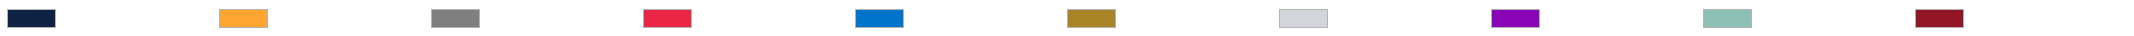

In [5]:
_fig = plot_colortable(color_palette, ncols=len(color_palette))

In [6]:
def add_run_uuid(run_uuid: str) -> None:
    """Add run_uuid to the config of all runs in the project."""
    api = wandb.Api(timeout=10000)
    for i in range(64):
        try:
            actual_run_uuid = f"{run_uuid}_client_{i}"
            run = api.run(f"camlsys/pollen-llm/{actual_run_uuid}")
            run.config["run_uuid"] = run_uuid
            run.update()
        except Exception as e:
            log(INFO, e)
    try:
        actual_run_uuid = f"{run_uuid}_server"
        run = api.run(f"camlsys/pollen-llm/{actual_run_uuid}")
        run.config["run_uuid"] = run_uuid
        run.update()
    except Exception as e:
        log(INFO, e)
    try:
        actual_run_uuid = f"{run_uuid}"
        run = api.run(f"camlsys/pollen-llm/{actual_run_uuid}")
        run.config["run_uuid"] = run_uuid
        run.update()
    except Exception as e:
        log(INFO, e)
    try:
        actual_run_uuid = f"{run_uuid}_centralised"
        run = api.run(f"camlsys/pollen-llm/{actual_run_uuid}")
        run.config["run_uuid"] = run_uuid
        run.update()
    except Exception as e:
        log(INFO, e)

In [7]:
def change_run_uuid(old_run_uuid: str, new_run_uuid: str) -> None:
    """Change the run_uuid of all runs with the old_run_uuid to the new_run_uuid."""
    api = wandb.Api(timeout=10000)
    for i in range(64):
        try:
            actual_run_uuid = f"{old_run_uuid}_client_{i}"
            run = api.run(f"camlsys/pollen-llm/{actual_run_uuid}")
            run.config["run_uuid"] = new_run_uuid
            run.update()
        except Exception as e:
            log(INFO, e)
    try:
        actual_run_uuid = f"{old_run_uuid}_server"
        run = api.run(f"camlsys/pollen-llm/{actual_run_uuid}")
        run.config["run_uuid"] = new_run_uuid
        run.update()
    except Exception as e:
        log(INFO, e)
    try:
        actual_run_uuid = f"{old_run_uuid}"
        run = api.run(f"camlsys/pollen-llm/{actual_run_uuid}")
        run.config["run_uuid"] = new_run_uuid
        run.update()
    except Exception as e:
        log(INFO, e)
    try:
        actual_run_uuid = f"{old_run_uuid}_centralised"
        run = api.run(f"camlsys/pollen-llm/{actual_run_uuid}")
        run.config["run_uuid"] = new_run_uuid
        run.update()
    except Exception as e:
        log(INFO, e)

In [8]:
# Set the run_id to be retrieved
run_id_dict = {
    "full_participation": {
        # Number of local steps per round
        "64_steps": {
            "16": ("fed-steps-16cpr64-bs32-20241029_092113", 16, True, False),
            "8": ("fed-lr-sched1-8cpr64-bs32-20241023_232107", 8, True, False),
            "4": (
                "fed-lr-sched0-4cpr64-bs32-20241022_145655",
                4,
                True,
                False,
            ),  # This has sched0 but it's actually sched1
            "2": ("fed-lr-sched1-2cpr64-bs32-20241023_144602", 2, True, False),
            "1": (
                "fed-lr-sched0-1cpr64-bs32-20241022_135427",
                1,
                True,
                False,
            ),  # This is of course repeated for several experiments as it is always the same
        },
        "128_steps": {
            "16": ("fed-steps-16cpr128-bs32-20241028_175222", 16, True, False),
            "8": ("fed-steps-8cpr128-bs32-20241026_004019", 8, True, False),
            "4": ("fed-steps-4cpr128-bs32-20241025_185132", 4, True, False),
            "2": (
                "fed-steps-2cpr128-bs32-20241027_115403",
                2,
                True,
                False,
            ),
            "1": (
                "fed-lr-sched0-1cpr64-bs32-20241022_135427",
                1,
                True,
                False,
            ),  # This is of course repeated for several experiments as it is always the same
        },
        "512_steps": {
            "16": (
                "fed-steps-16cpr512-bs32-20241027_083734",
                16,
                True,
                False,
            ),
            "8": ("fed-steps-8cpr512-bs32-20241025_151104", 8, True, False),
            "4": ("fed-steps-4cpr512-bs32-20241025_110058", 4, True, False),
            "2": ("fed-steps-2cpr512-bs32-20241026_132229", 2, True, False),
            "1": (
                "fed-lr-sched0-1cpr64-bs32-20241022_135427",
                1,
                True,
                False,
            ),  # This is of course repeated for several experiments as it is always the same
        },
    },
    "partial_participation": {
        # Participation ratios - 512 steps per round
        "0_5": {
            "8": ("fed-pp0_5-8cpr512-bs32-20241026_150027", 8, True, False),
            "4": ("fed-pp0_5-4cpr512-bs32-20241026_173006", 4, True, False),
            "2": ("", 2, True, False),
            "1": ("", 1, True, False),
        },
        "0_25": {
            "8": ("", 8, True, False),
            "4": ("", 4, True, False),
            "2": ("fed-pp0_25-2cpr512-bs32-20241027_174630", 2, True, False),
            "1": ("", 1, True, False),
        },
        "0_25": {
            "8": ("", 8, True, False),
            "4": ("", 4, True, False),
            "2": ("", 2, True, False),
            "1": ("", 1, True, False),
        },
        "0_125": {
            "8": ("fed-pp0_125-8cpr512-bs32-20241026_235833", 8, True, False),
            "4": ("fed-pp0_125-4cpr512-bs32-20241027_030224", 4, True, False),
            "2": ("", 2, True, False),
            "1": ("", 1, True, False),
        },
    },
    "outer_optimizer": {
        # Types of outer optimizers - 512 steps per round
        # partial participation?
        "diloco_0_1": {
            "8": (
                "fed-opt-8cpr512-bs32-20241028_073346",
                8,
                True,
                False,
            ),
            "4": (
                "fed-opt-4cpr512-bs32-20241028_073249",
                4,
                True,
                False,
            ),
            "2": (
                "fed-opt-2cpr512-bs32-20241028_093045",
                2,
                True,
                False,
            ),  # Lorenzo Monitoring on Lambda cluster
            "1": ("", 1, True, False),
        },
        "diloco_0_3": {
            "8": ("", 8, True, False),  # Lorenzo Monitoring on Lambda cluster
            "4": ("fed-opt-4cpr512-bs32-20241027_235049", 4, True, False),
            "2": ("", 2, True, False),  # Lorenzo Monitoring on Lambda cluster
            "1": ("", 1, True, False),
        },
        "diloco_0_5": {
            "8": (
                "fed-opt-8cpr512-bs32-20241027_234049",
                8,
                True,
                False,
            ),
            "4": ("fed-opt-4cpr512-bs32-20241027_210455", 4, True, False),
            "2": ("", 2, True, False),  # Lorenzo Monitoring on Lambda cluster
            "1": ("", 1, True, False),
        },
        "diloco_0_7": {
            "8": (
                "fed-opt-8cpr512-bs32-20241028_154101",
                8,
                True,
                False,
            ),  # Lorenzo Monitoring on Lambda cluster
            "4": ("fed-opt-4cpr512-bs32-20241027_174747", 4, True, False),
            "2": ("", 2, True, False),  # Lorenzo Monitoring on Lambda cluster
            "1": ("", 1, True, False),
        },
    },
    "non_iid_data": {
        # Heterogenous data sources - 512 steps per round (eval on C4 test set)
        # Full participation using 4 data sources each of which is split into 2 for the
        # 8cpr and 4 for the 16cpr.
        "the_pile": {
            "16": ("fed-niid-16cpr512-bs32-20241028_080821", 16, True, False),
            "8": ("fed-niid-8cpr512-bs32-20241028_080956", 8, True, False),
            "4": ("fed-niid-4cpr512-bs32-20241027_221627", 4, True, False),
        },
        "the_pile_partial": {
            "8": ("fed-ppniid-8cpr512-bs32-20241028_153117", 8, True, False),
            "4": ("fed-ppniid-4cpr512-bs32-20241028_144755", 4, True, False),
        },
    },
    "robustness": {
        "iid": {
            "8": ("fed-rob-iid-8cpr512-bs32-20241028_160034", 8, True, False),
            "4": ("fed-rob-iid-4cpr512-bs32-20241028_155930", 4, True, False),
            "2": ("fed-rob-iid-2cpr512-bs32-20241028_155836", 2, True, False),
        },
        "non_iid": {
            "8": ("fed-rob-niid-8cpr512-bs32-20241028_160034", 8, True, False),
            "4": ("fed-rob-niid-4cpr512-bs32-20241028_155930", 4, True, False),
            "2": ("fed-rob-niid-2cpr512-bs32-20241028_155836", 2, True, False),
        },
    },
    "mclr": {
        "": ("matrix-125M-20240823-tle", "full-125M-20240823_125915", True, False),
        # "": ("centB-125M-20240907_115804", CentSuffix.NONE),
    },
    # ?
    "reset_opt_states": {},
}

In [37]:
def download_metrics(
    run_id: str,
    n_clients: int,
    drop_layers: bool = True,
    use_server_name: bool = False,
    project_name: str = "pollen-llm",
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Download all the metrics from given run_id using Wandb API."""
    # Initialize the wandb API
    api = wandb.Api(timeout=100)
    # Get the run object
    server_run = (
        api.run(f"camlsys/{project_name}/{run_id}_server")
        if use_server_name
        else api.run(f"camlsys/{project_name}/{run_id}")
    )
    # Get the metrics
    server_metrics = server_run.scan_history()
    # Convert the metrics to a pandas data frame
    server_metrics_df = pd.DataFrame(server_metrics)
    # Drop the layers columns if needed
    if drop_layers:
        layer_columns = [col for col in server_metrics_df.columns if "layer" in col]
        server_metrics_df = server_metrics_df.drop(columns=layer_columns)
    # Add the `step` column based on the index
    server_metrics_df["step"] = server_metrics_df.index
    # Get clients metrics
    clients_metrics_df_list: list[pd.DataFrame] = []

    for i in range(n_clients):
        try:
            # Get the run object

            client_run = (
                api.run(f"camlsys/{project_name}/{run_id}_client_{i}")
                if (
                    run_id
                    not in {
                        "pile-75M-final-20240605_133225",
                        "partial-75M-20240605_133326",
                    }
                )
                else api.run(f"camlsys/{project_name}/{run_id}client_{i}")
            )
            # Get the metrics
            client_metrics = client_run.scan_history()
            # Convert the metrics to a pandas data frame
            client_metrics_df = pd.DataFrame(client_metrics)
            # Drop the layers columns if needed
            if drop_layers:
                layer_columns = [
                    col for col in client_metrics_df.columns if "layer" in col
                ]
                client_metrics_df = client_metrics_df.drop(columns=layer_columns)
            # Add the `step` column based on the index
            client_metrics_df["step"] = client_metrics_df._step
            # Add the `client_id` column based on the current client_id
            client_metrics_df["client_id"] = i
            # Append the client metrics to the list
            clients_metrics_df_list.append(client_metrics_df)
        except Exception as e:
            log(
                ERROR,
                f"Client {i} not found for run {run_id}",
                stack_info=True,
                exc_info=e,
            )
    # Concatenate the clients metrics
    if len(clients_metrics_df_list) > 0:
        clients_metrics_df = pd.concat(clients_metrics_df_list)
    else:
        clients_metrics_df = pd.DataFrame()
    # Return the metrics data frame
    return server_metrics_df, clients_metrics_df

In [10]:
# Model Constants
SERVER_BANDWIDTH = 625  # 625 MBps == 5Gbps
SERVER_BANDWIDTH = 1_250  # 10 Gbps
SERVER_BANDWIDTH = 125  # 125 MBps == 1Gbps
SERVER_BANDWIDTH = 312.5  # 312.5 MBps == 2.5Gbps
SERVER_FLOPS = 5_000_000_000  # 5TFLOPs per second
CHANNELS_THRESHOLD = 100


# Model
class WallTimeModel:
    """Wall time model for the federated learning process."""

    def __init__(
        self,
        num_rounds: int,
        num_clients_per_round: int,
        num_parameters: int,
        local_steps: int,
        local_throughput: float,  # Must be in batches per second
        server_bandwidth: float = SERVER_BANDWIDTH,  # Must be in MBps
        server_flops: float = SERVER_FLOPS,  # Must be in FLOPs per second
        channels_threshold: int = CHANNELS_THRESHOLD,
    ) -> None:
        self.num_rounds = num_rounds
        self.num_clients_per_round = num_clients_per_round
        self.parameters_mbytes = num_parameters
        self.parameters_bytes = 2 * num_parameters
        self.parameters_mbytes = self.parameters_bytes / 10**6
        self.local_steps = local_steps
        self.local_throughput = local_throughput
        self.server_bandwidth = server_bandwidth
        self.server_flops = server_flops
        self.channels_threshold = channels_threshold

    def client_training_time(self) -> float:
        """Compute the time taken for a client to train."""
        # `self.local_throughput` is in batches per second
        # `self.local_steps` is the number of batches trained
        return self.local_steps / self.local_throughput

    def broadcast_model_time(self) -> float:
        """Compute the time taken to broadcast the model."""
        if self.num_clients_per_round == 1:
            return 0.0
        if self.num_clients_per_round > self.channels_threshold:
            return (self.num_clients_per_round * self.parameters_mbytes) / np.sqrt(
                self.server_bandwidth
            )
        else:
            return (
                self.num_clients_per_round * self.parameters_mbytes
            ) / self.server_bandwidth

    def collect_pseudo_gradients_time(self) -> float:
        """Compute the time taken to collect the pseudo gradients."""
        if self.num_clients_per_round == 1:
            return 0.0
        if self.num_clients_per_round > self.channels_threshold:
            return (self.num_clients_per_round * self.parameters_mbytes) / np.sqrt(
                self.server_bandwidth
            )
        else:
            return (
                self.num_clients_per_round * self.parameters_mbytes
            ) / self.server_bandwidth

    def aggregation_time(self) -> float:
        """Compute the time taken to aggregate the pseudo gradients."""
        if self.num_clients_per_round == 1:
            return 0.0
        return (self.num_clients_per_round * self.parameters_mbytes) / self.server_flops

    def allreduce_communication_time(self) -> float:
        """Compute the time taken to perform allreduce communication."""
        if self.num_clients_per_round == 1:
            return 0.0
        return (
            (self.num_clients_per_round - 1) * self.parameters_mbytes
        ) / self.server_bandwidth

    def ring_allreduce_communication_time(self) -> float:
        """Compute the time taken to perform ring allreduce communication."""
        if self.num_clients_per_round == 1:
            return 0.0
        return (
            2
            * self.parameters_mbytes
            * (self.num_clients_per_round - 1)
            / self.num_clients_per_round
        ) / self.server_bandwidth

    def parameter_server_communication_time(self) -> float:
        """Compute the time taken for the parameter server to aggregate the gradients."""
        return (
            self.broadcast_model_time()
            + self.collect_pseudo_gradients_time()
            + self.aggregation_time()
        )

    def allreduce_server_time(self) -> float:
        """Compute the time taken for the parameter server to perform allreduce."""
        return self.allreduce_communication_time() + self.aggregation_time()

    def ring_allreduce_server_time(self) -> float:
        """Compute the time taken for the parameter server to perform ring allreduce."""
        return self.ring_allreduce_communication_time() + self.aggregation_time()

    def round_completion_time_ps(self) -> float:
        """Compute the time taken to complete a round using parameter server."""
        return self.client_training_time() + self.parameter_server_communication_time()

    def round_completion_time_ar(self) -> float:
        """Compute the time taken to complete a round using allreduce."""
        return self.client_training_time() + self.allreduce_server_time()

    def round_completion_time_rar(self) -> float:
        """Compute the time taken to complete a round using ring allreduce."""
        return self.client_training_time() + self.ring_allreduce_server_time()

    def total_wall_time_ps(self) -> float:
        """Compute the total wall time using parameter server."""
        return self.num_rounds * self.round_completion_time_ps()

    def total_wall_time_ar(self) -> float:
        """Compute the total wall time using allreduce."""
        return self.num_rounds * self.round_completion_time_ar()

    def total_wall_time_rar(self) -> float:
        """Compute the total wall time using ring allreduce."""
        return self.num_rounds * self.round_completion_time_rar()

In [11]:
# Centralized baseline (bs256) - PPl = 42
cen_bs256_ppl42 = WallTimeModel(
    num_rounds=3500,
    num_clients_per_round=8,
    num_parameters=125_000_000,
    local_steps=1,
    local_throughput=2,  # 2 batches per second (empirical on 1xH100)
)
# Centralized baseline (bs256) - PPl = 35
cen_bs256_ppl35 = WallTimeModel(
    num_rounds=5950,
    num_clients_per_round=8,
    num_parameters=125_000_000,
    local_steps=1,
    local_throughput=2,  # 2 batches per second (empirical on 1xH100)
)

In [12]:
# Centralized baseline (bs128) - PPl = 42
cen_bs128_ppl42 = WallTimeModel(
    num_rounds=4715,
    num_clients_per_round=8,
    num_parameters=125_000_000,
    local_steps=1,
    local_throughput=2,  # 2 batches per second (empirical on 1xH100)
)
# Centralized baseline (bs128) - PPl = 35
cen_bs128_ppl35 = WallTimeModel(
    num_rounds=4715,
    num_clients_per_round=8,
    num_parameters=125_000_000,
    local_steps=1,
    local_throughput=2,  # 2 batches per second (empirical on 1xH100)
)

In [13]:
def find_federated_round_for_perplexity(
    client_metrics_df: pd.DataFrame,
    perplexity_value: float | None,
    rolling_window: int = 100,
) -> tuple[int, float]:
    """
    Find the federated round for a given perplexity value.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing the metrics with columns 'steps' and 'metrics/train/LanguagePerplexity'.
    perplexity_value : float
        The perplexity value to find the federated round for.
    rolling_window : int, optional
        The window size for smoothing the perplexity series, by default 100.

    Returns
    -------
    int
        The federated round corresponding to the given perplexity value.
    """
    # Get columns
    exclude_columns = client_metrics_df.columns
    # Remove columns of interest
    exclude_columns = [
        col
        for col in exclude_columns
        if col not in {"step", "metrics/train/LanguagePerplexity"}
    ]
    aggregated_df = client_metrics_df.drop(columns=exclude_columns)
    # Remove inf
    aggregated_df = aggregated_df.replace([np.inf, -np.inf], np.nan)
    # Substitute non-numeric values with NaN
    aggregated_df = aggregated_df.apply(pd.to_numeric, errors="coerce")
    # Aggregate by step and remove nans
    aggregated_df = aggregated_df.groupby("step").mean().reset_index()
    # Fill NaNs by interpolation
    aggregated_df = aggregated_df.interpolate()
    # Extract `metrics/train/LanguagePerplexity` series against steps
    steps: pd.Series[int] = aggregated_df["step"]
    perplexity_series = aggregated_df["metrics/train/LanguagePerplexity"]

    # Smooth the line using a rolling window of 100 steps
    smoothed_perplexity = perplexity_series.rolling(window=rolling_window).mean()
    # smoothed_perplexity = perplexity_series.rolling(window=rolling_window).min()
    # log(INFO, f"Smoothed perplexity: {smoothed_perplexity}")

    # Find the x-coordinate of a given perplexity value
    if perplexity_value is None:
        perplexity_value = smoothed_perplexity.min()
    assert perplexity_value is not None
    closest_index = (smoothed_perplexity - perplexity_value).abs().idxmin()
    x_coordinate = steps[closest_index]
    # log(INFO, f"Closest index: {closest_index}, x-coordinate: {x_coordinate}")

    # Return the step and the perplexity value
    return x_coordinate, perplexity_value

In [52]:
def get_perplexity_series(
    client_metrics_df: pd.DataFrame,
    moving_window: int = 100,
    *,
    remove_outliers: bool = True,
) -> tuple[pd.Series, pd.Series]:
    """Extract and process the PPL series from a client metrics DataFrame.

    This function performs the following steps:
    1. Excludes columns that are not of interest.
    2. Removes infinite values and substitutes non-numeric values with NaN.
    3. Aggregates the data by step, computing the mean for each step.
    4. Interpolates NaN values to fill gaps in the data.
    5. Smooths the Language Perplexity series using a moving window.
    6. Extracts the 'step' and 'metrics/train/LanguagePerplexity' series.

    Parameters
    ----------
    client_metrics_df : pd.DataFrame
        DataFrame containing client metrics, including 'step' and
        'metrics/train/LanguagePerplexity'.
    moving_window : int, optional
        The window size for moving operations to smooth the perplexity series
        (default is 100).

    Returns
    -------
    tuple[pd.Series[int], pd.Series[float]]
        A tuple containing two pandas Series:
        - steps: Series of step values.
        - smoothed_perplexity: Smoothed series of Language Perplexity values
        corresponding to the steps.

    Example:
    --------
    >>> steps, smoothed_perplexity = get_perplexity_series(client_metrics_df)
    >>> plt.plot(steps, smoothed_perplexity)
    >>> plt.xlabel('Step')
    >>> plt.ylabel('Smoothed Language Perplexity')
    >>> plt.show()
    """
    # Directly select only columns of interest
    columns_of_interest = ["step", "metrics/train/LanguagePerplexity"]
    filtered_df = client_metrics_df[columns_of_interest].copy()

    # Remove inf values and substitute non-numeric values with NaN
    filtered_df = filtered_df.replace([np.inf, -np.inf], np.nan)
    filtered_df = filtered_df.apply(pd.to_numeric, errors="coerce")

    # Remove outliers for indices where step is greater than 1000
    if remove_outliers:
        filtered_df = filtered_df[
            (filtered_df["step"] < 1000)
            | (filtered_df["metrics/train/LanguagePerplexity"] < 300)
        ]

    # Aggregate by step and compute mean
    aggregated_df = filtered_df.groupby("step").mean().reset_index()

    # Fill NaNs by interpolation
    aggregated_df = aggregated_df.interpolate()

    # Extract series
    steps = aggregated_df["step"]
    perplexity_series = aggregated_df["metrics/train/LanguagePerplexity"]

    # Smooth the perplexity series
    smoothed_perplexity = perplexity_series.rolling(window=moving_window).mean()

    return steps, smoothed_perplexity

INFO :      Experiment with 1 clients per round trained on 829.24M tokens in 12778 steps to achieve 42 perplexity
INFO :      n_local_steps=64, num_clients_per_round=1, n_rounds=199, min_ppl=42
INFO :      Experiment with 2 clients per round trained on 1.31B tokens in 10088 steps to achieve 42 perplexity
INFO :      n_local_steps=64, num_clients_per_round=2, n_rounds=157, min_ppl=42
INFO :      Experiment with 4 clients per round trained on 2.32B tokens in 8931 steps to achieve 42 perplexity
INFO :      n_local_steps=64, num_clients_per_round=4, n_rounds=139, min_ppl=42
INFO :      Experiment with 8 clients per round trained on 4.33B tokens in 8341 steps to achieve 42 perplexity
INFO :      n_local_steps=64, num_clients_per_round=8, n_rounds=130, min_ppl=42
INFO :      Experiment with 16 clients per round trained on 8.39B tokens in 8084 steps to achieve 42 perplexity
INFO :      n_local_steps=64, num_clients_per_round=16, n_rounds=126, min_ppl=42
INFO :      Experiment with 1 clients p

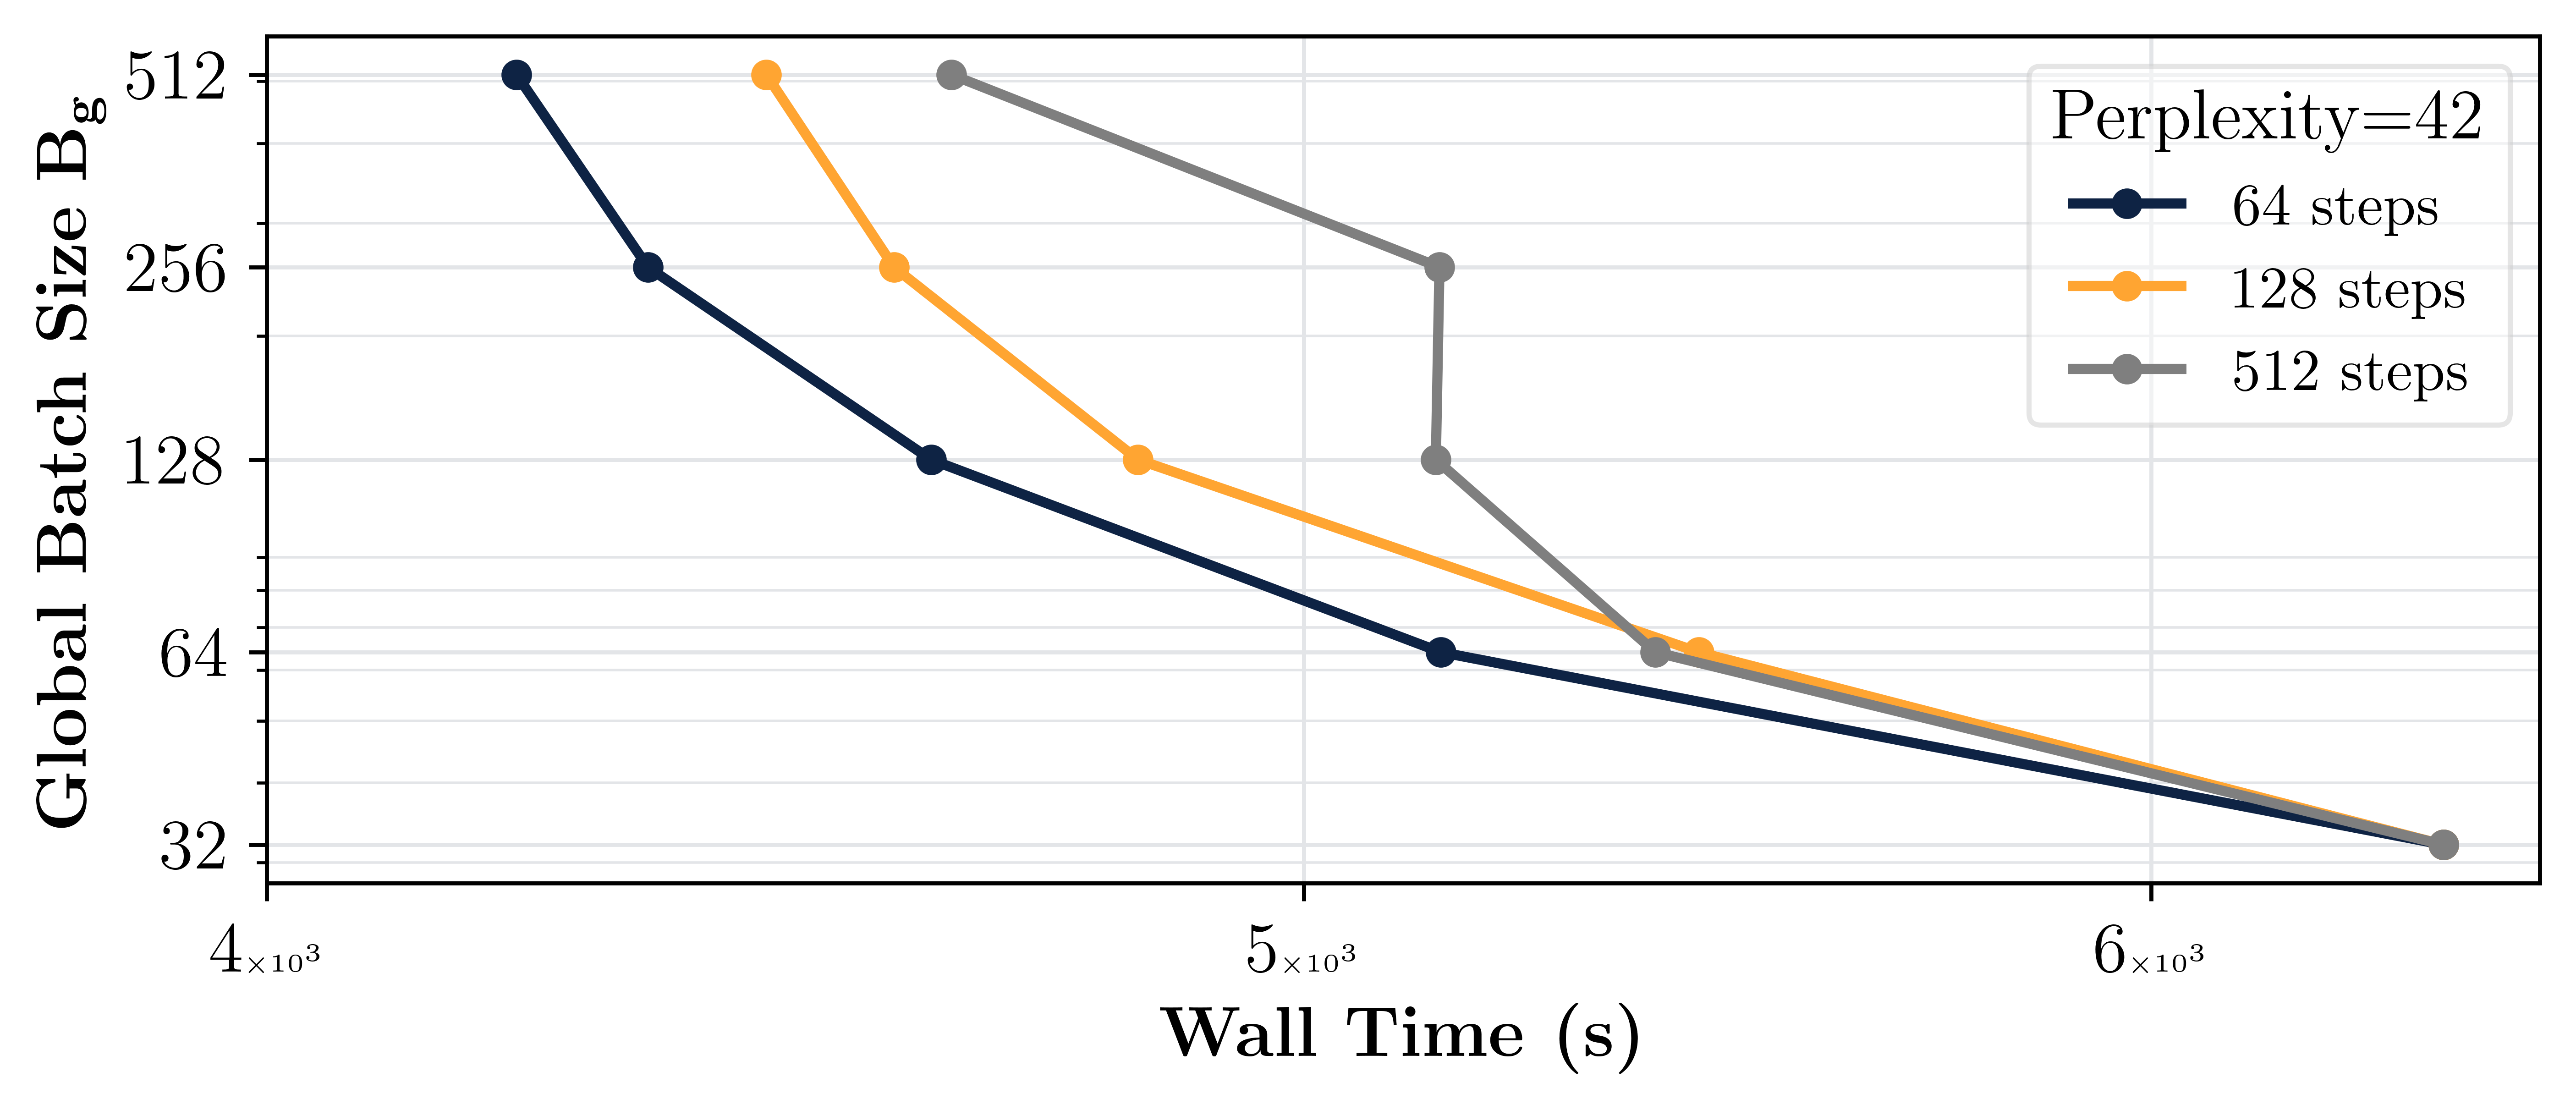

INFO :      Experiment with 1 clients per round trained on 1.60B tokens in 24608 steps to achieve 35 perplexity
INFO :      n_local_steps=64, num_clients_per_round=1, n_rounds=384, min_ppl=35
INFO :      Experiment with 2 clients per round trained on 2.49B tokens in 19171 steps to achieve 35 perplexity
INFO :      n_local_steps=64, num_clients_per_round=2, n_rounds=299, min_ppl=35
INFO :      Experiment with 4 clients per round trained on 4.35B tokens in 16739 steps to achieve 35 perplexity
INFO :      n_local_steps=64, num_clients_per_round=4, n_rounds=261, min_ppl=35
INFO :      Experiment with 8 clients per round trained on 8.08B tokens in 15568 steps to achieve 35 perplexity
INFO :      n_local_steps=64, num_clients_per_round=8, n_rounds=243, min_ppl=35
INFO :      Experiment with 16 clients per round trained on 15.64B tokens in 15062 steps to achieve 35 perplexity
INFO :      n_local_steps=64, num_clients_per_round=16, n_rounds=235, min_ppl=35
INFO :      Experiment with 1 clients

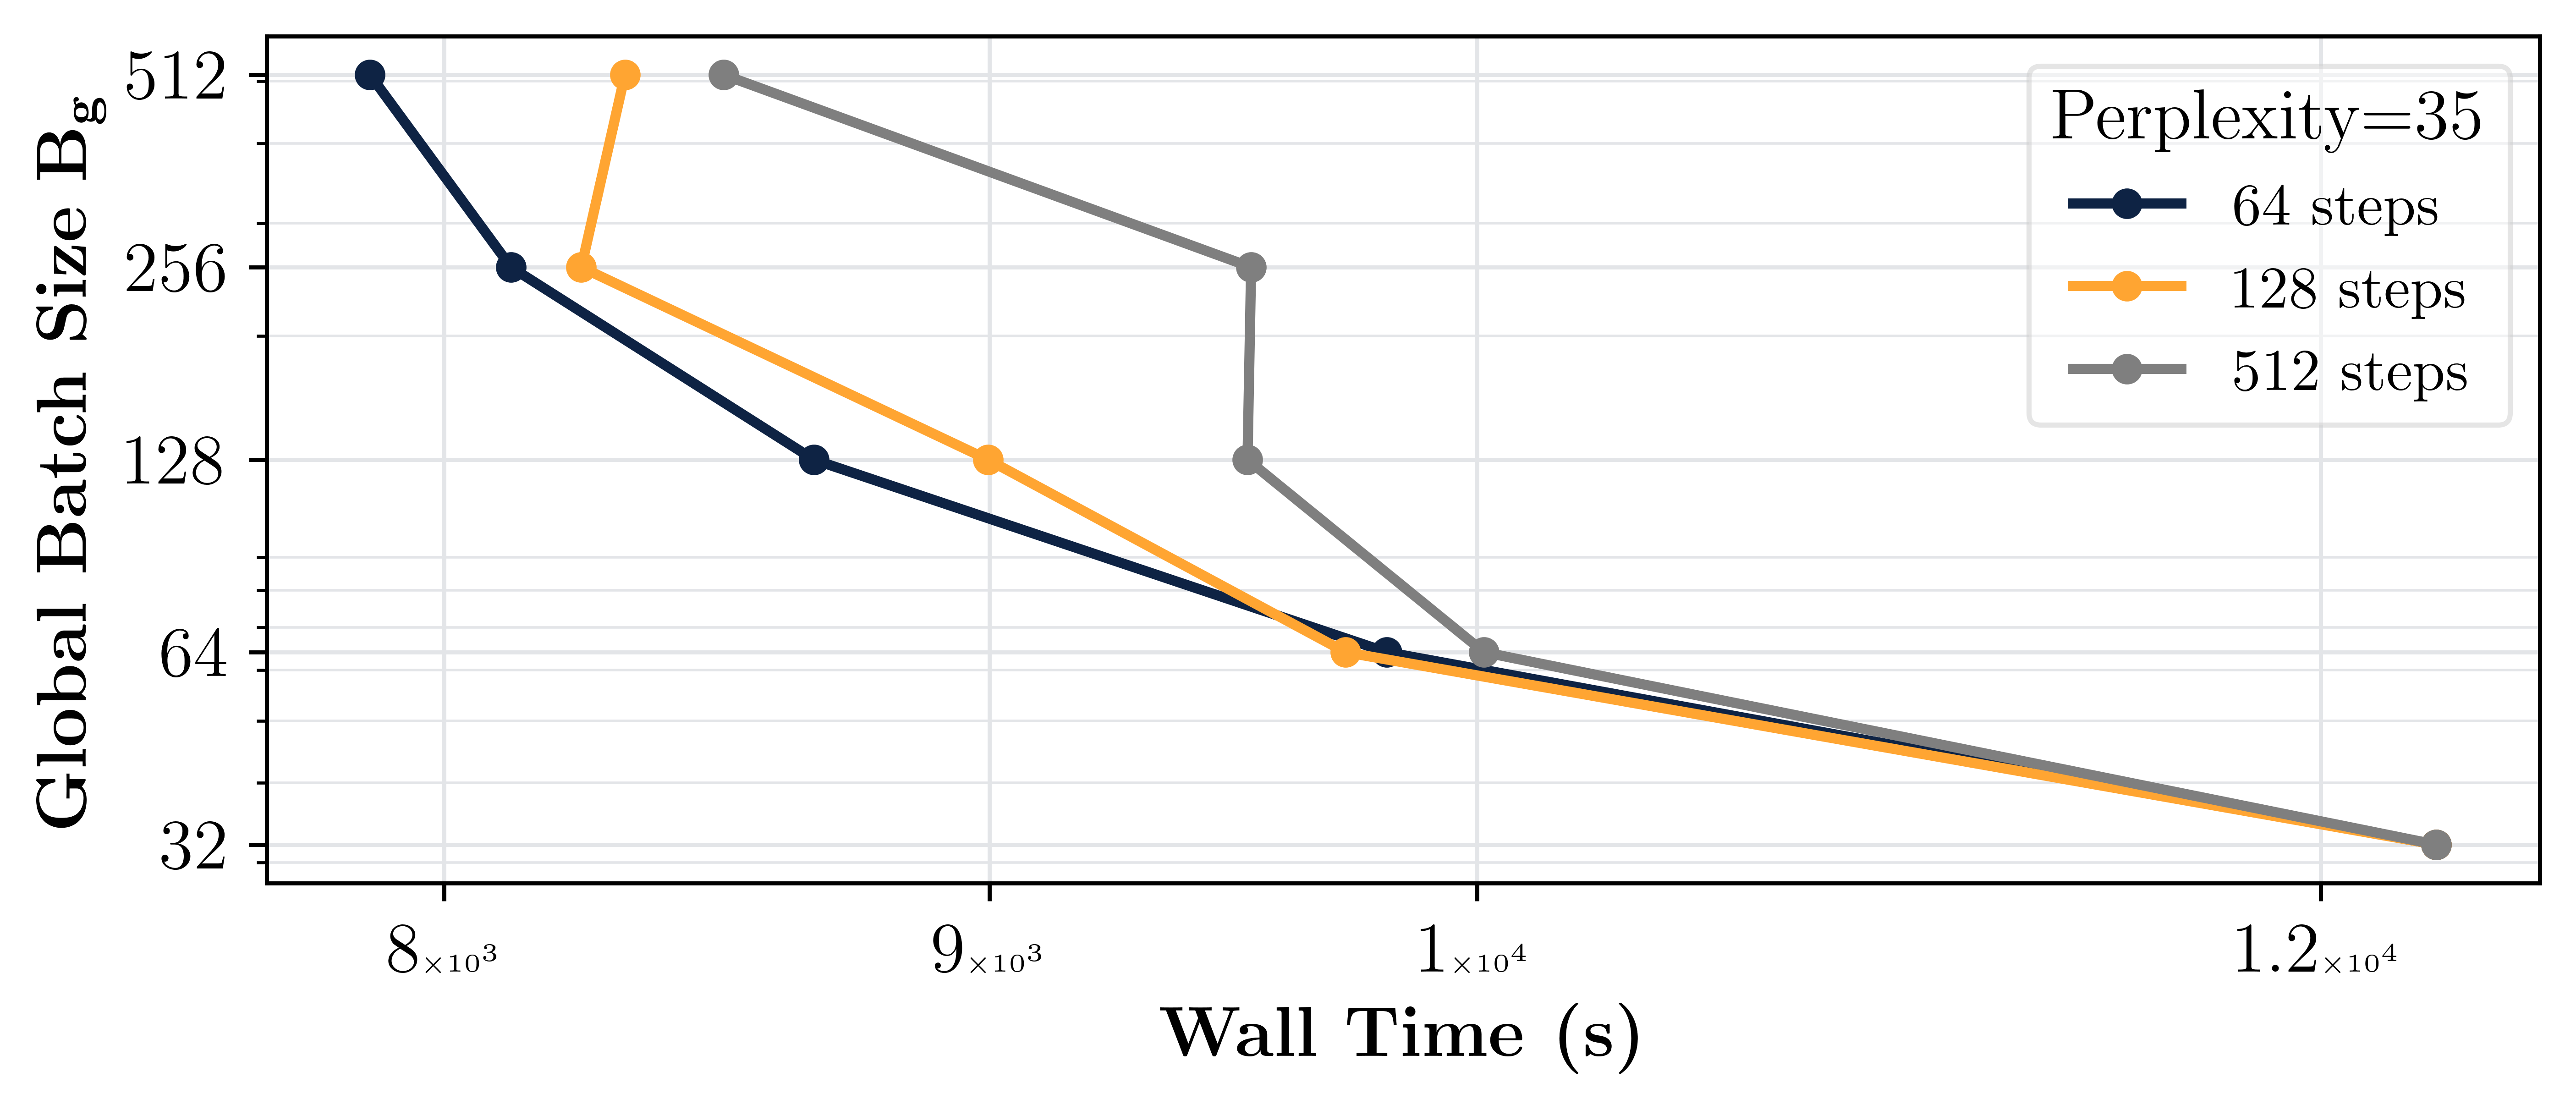

In [15]:
# Load the WandB data
experiment_type = "full_participation"
for i, min_ppl in enumerate(reversed([35, 42])):
    fig = plt.figure(figsize=fig_size)
    for j, experiment_hp in enumerate(run_id_dict[experiment_type]):
        y_coordinates: list[int] = []
        x_coordinates: list[float] = []
        for conf in sorted(
            [int(x) for x in run_id_dict[experiment_type][experiment_hp]]
        ):
            run_uuid = run_id_dict[experiment_type][experiment_hp][str(conf)][0]
            try:
                server_metrics_df = pd.read_pickle(f"server_{run_uuid}.pkl")
                client_metrics_df = pd.read_pickle(f"clients_{run_uuid}.pkl")
            except FileNotFoundError:
                server_metrics_df, client_metrics_df = download_metrics(
                    *run_id_dict[experiment_type][experiment_hp][str(conf)]
                )
                # Dump the dataframes to pickle files
                server_metrics_df.to_pickle(f"server_{run_uuid}.pkl")
                client_metrics_df.to_pickle(f"clients_{run_uuid}.pkl")
            steps_to_min, new_min_ppl = find_federated_round_for_perplexity(
                client_metrics_df=client_metrics_df,
                perplexity_value=min_ppl,
                rolling_window=100,
            )
            # Initialize the model
            n_local_steps = int(experiment_hp.replace("_steps", ""))
            # Assuming conf, n_local_steps, and min_ppl are already defined
            tokens = steps_to_min * 32 * 2028 * conf

            if tokens >= 1_000_000_000:
                tokens_str = f"{tokens / 1_000_000_000:.2f}B"
            elif tokens >= 1_000_000:
                tokens_str = f"{tokens / 1_000_000:.2f}M"
            else:
                tokens_str = str(tokens)
            log(
                INFO,
                "Experiment with %s clients per round trained on %s tokens in %s steps to achieve %s perplexity",
                conf,
                tokens_str,
                steps_to_min,
                min_ppl,
            )
            n_rounds = steps_to_min // n_local_steps
            model = WallTimeModel(
                num_rounds=n_rounds,
                num_clients_per_round=int(conf),
                num_parameters=125_000_000,
                local_steps=n_local_steps,
                local_throughput=2,  # 2 batches per second
            )

            # Calculate total wall time for different approaches
            total_wall_time_ps = model.total_wall_time_ps()
            total_wall_time_ar = model.total_wall_time_ar()
            total_wall_time_rar = model.total_wall_time_rar()

            y_coordinates.append(int(conf))
            log(
                INFO,
                "n_local_steps=%s, num_clients_per_round=%s, n_rounds=%s, min_ppl=%s",
                n_local_steps,
                int(conf),
                n_rounds,
                min_ppl,
            )
            if int(conf) == 1:
                x_coordinates.append(steps_to_min / model.local_throughput)
            else:
                x_coordinates.append(total_wall_time_rar)
        # Plot the y_coordinates against the x_coordinates
        plt.plot(
            x_coordinates,
            [y * 32 for y in y_coordinates],
            marker=".",
            label=f"{experiment_hp.replace('_', ' ')}",
            color=color_palette[j],
            linestyle=line_styles[0],
        )

    plt.xlabel(r"\textbf{Wall Time (s)}")
    plt.legend(
        loc="upper right",
        ncol=1,
        title=r"\text{Perplexity}=%s" % min_ppl,
    )
    plt.xscale("log")
    plt.yscale("log")
    # # Change the minor grid to have a smaller linewidth
    plt.grid(axis="both", which="minor", lw=0.5)

    plt.ylabel(r"\textbf{Global Batch Size} $\mathbf{B_g}$")
    plt.yticks([32, 64, 128, 256, 512], labels=["32", "64", "128", "256", "512"])

    if i == 0:
        # plt.ylabel(r"Global Batch Size $B_g$")
        # Change the y ticks to report only the values 1, 2, 4, 8, 16
        # plt.yticks([32, 64, 128, 256, 512], labels=["32", "64", "128", "256", "512"])
        # Change the x tciks
        plt.xticks(
            [4_000, 5000, 6000],
            labels=[
                r"4{\tiny×10\textsuperscript{3}}",
                r"5{\tiny×10\textsuperscript{3}}",
                r"6{\tiny×10\textsuperscript{3}}",
            ],
        )
    else:
        # Remove the y ticks
        # plt.yticks([32, 64, 128, 256, 512], labels=["", "", "", "", ""])
        # Change the x tciks
        plt.xticks(
            [8000, 9000, 10000, 12000],
            labels=[
                r"\textrm{8{\tiny×10\textsuperscript{3}}}",
                r"9{\tiny×10\textsuperscript{3}}",
                r"1{\tiny×10\textsuperscript{4}}",
                r"1.2{\tiny×10\textsuperscript{4}}",
            ],
        )
    plt.savefig(f"wall_time_{experiment_type}_ppl{min_ppl}.pdf")
    plt.show()

INFO :      [1.e+02 1.e+03 1.e+04 1.e+05 1.e+06]


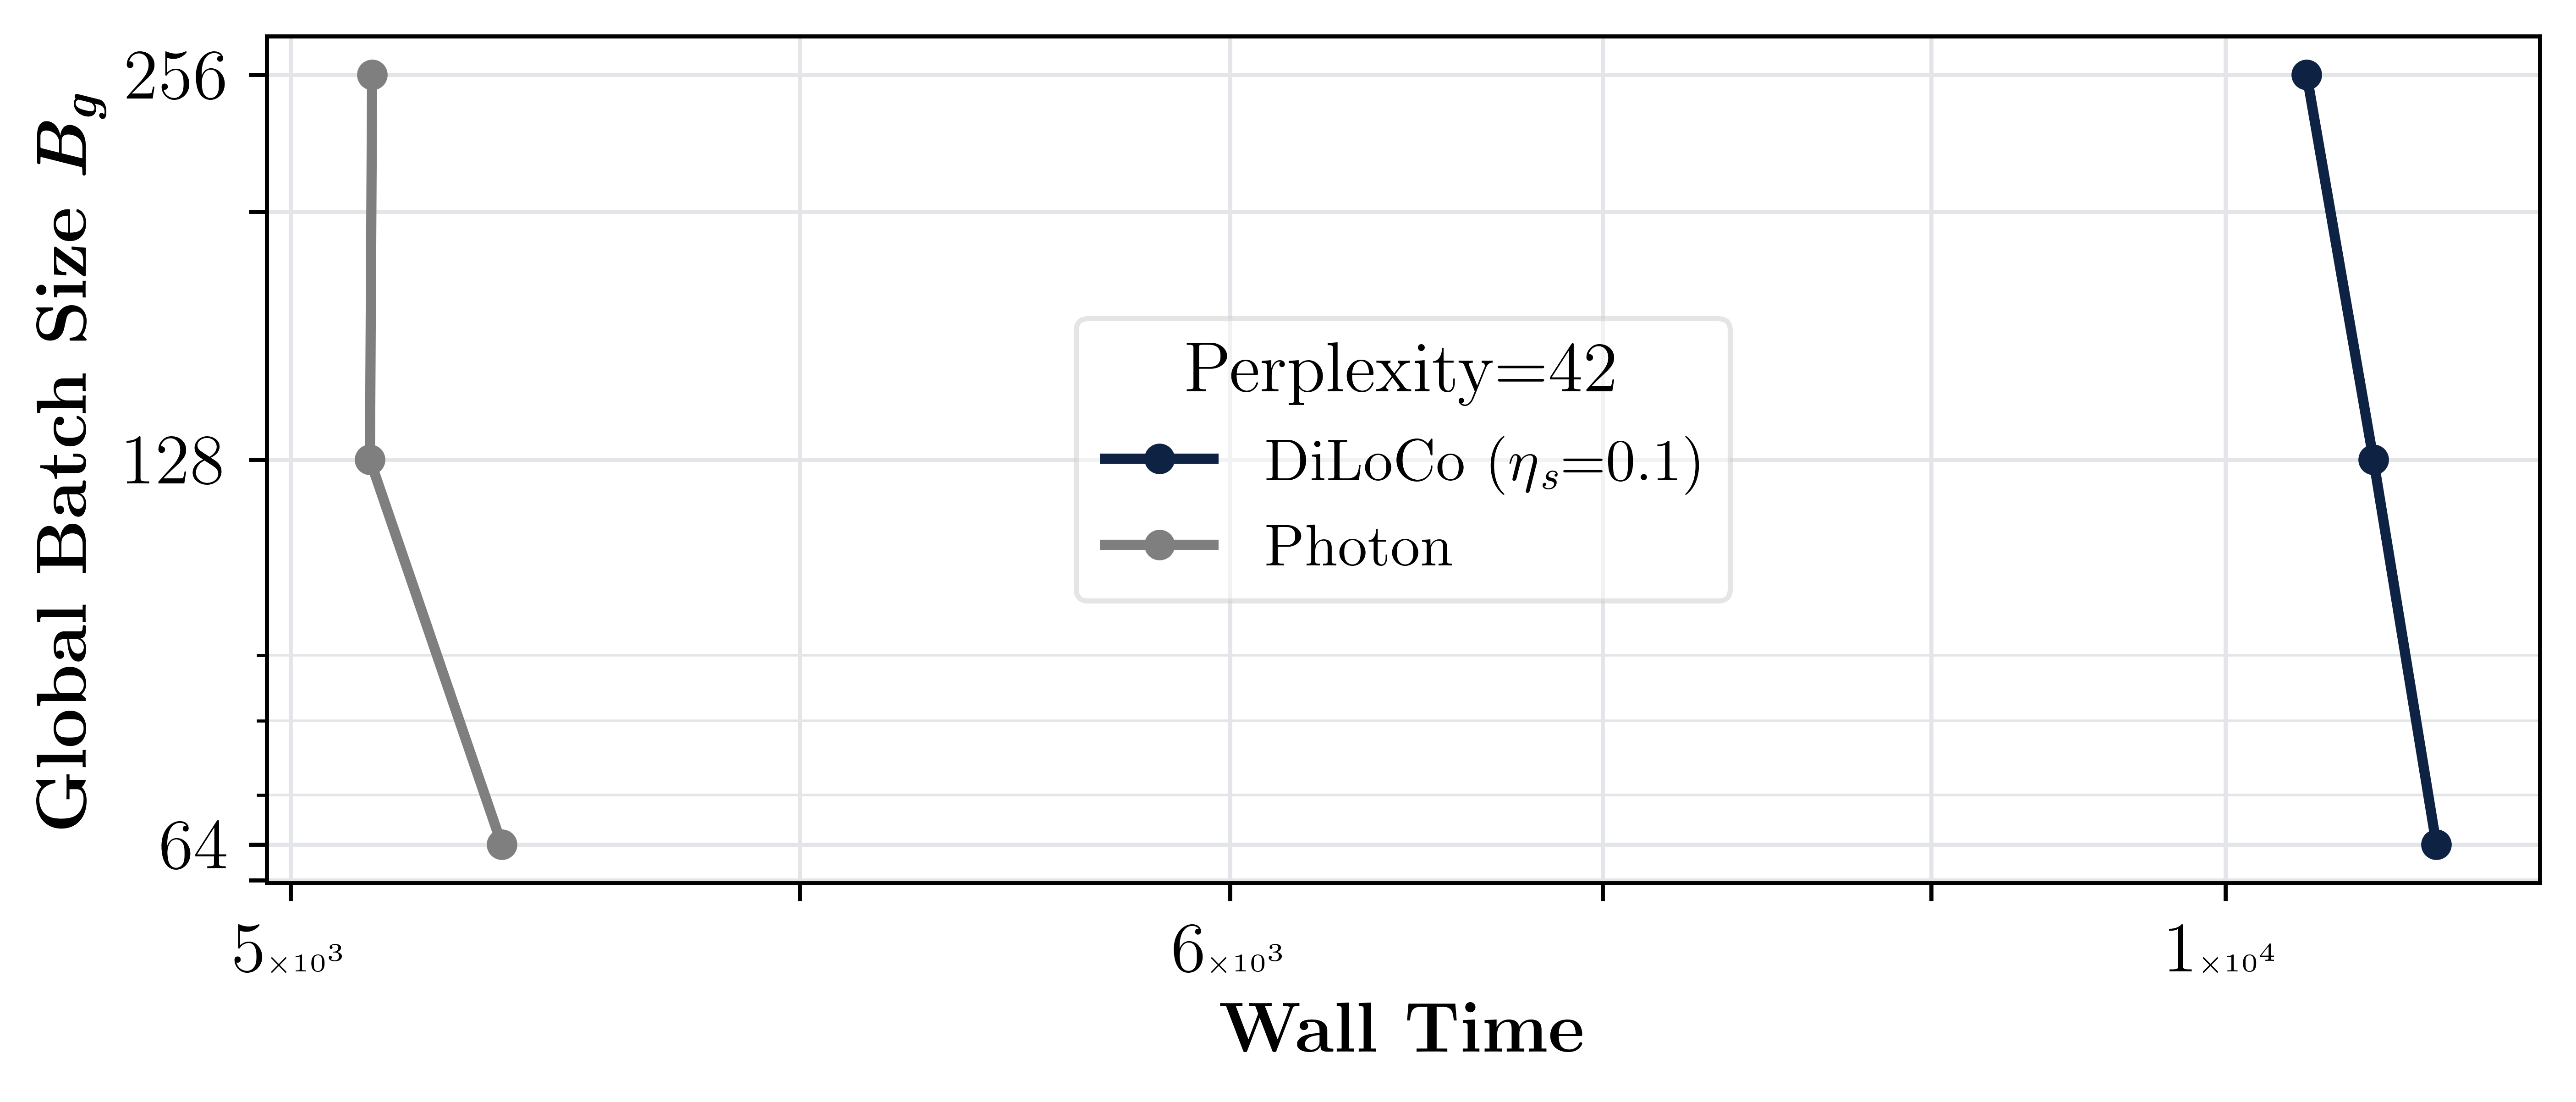

INFO :      [1.e+02 1.e+03 1.e+04 1.e+05 1.e+06]


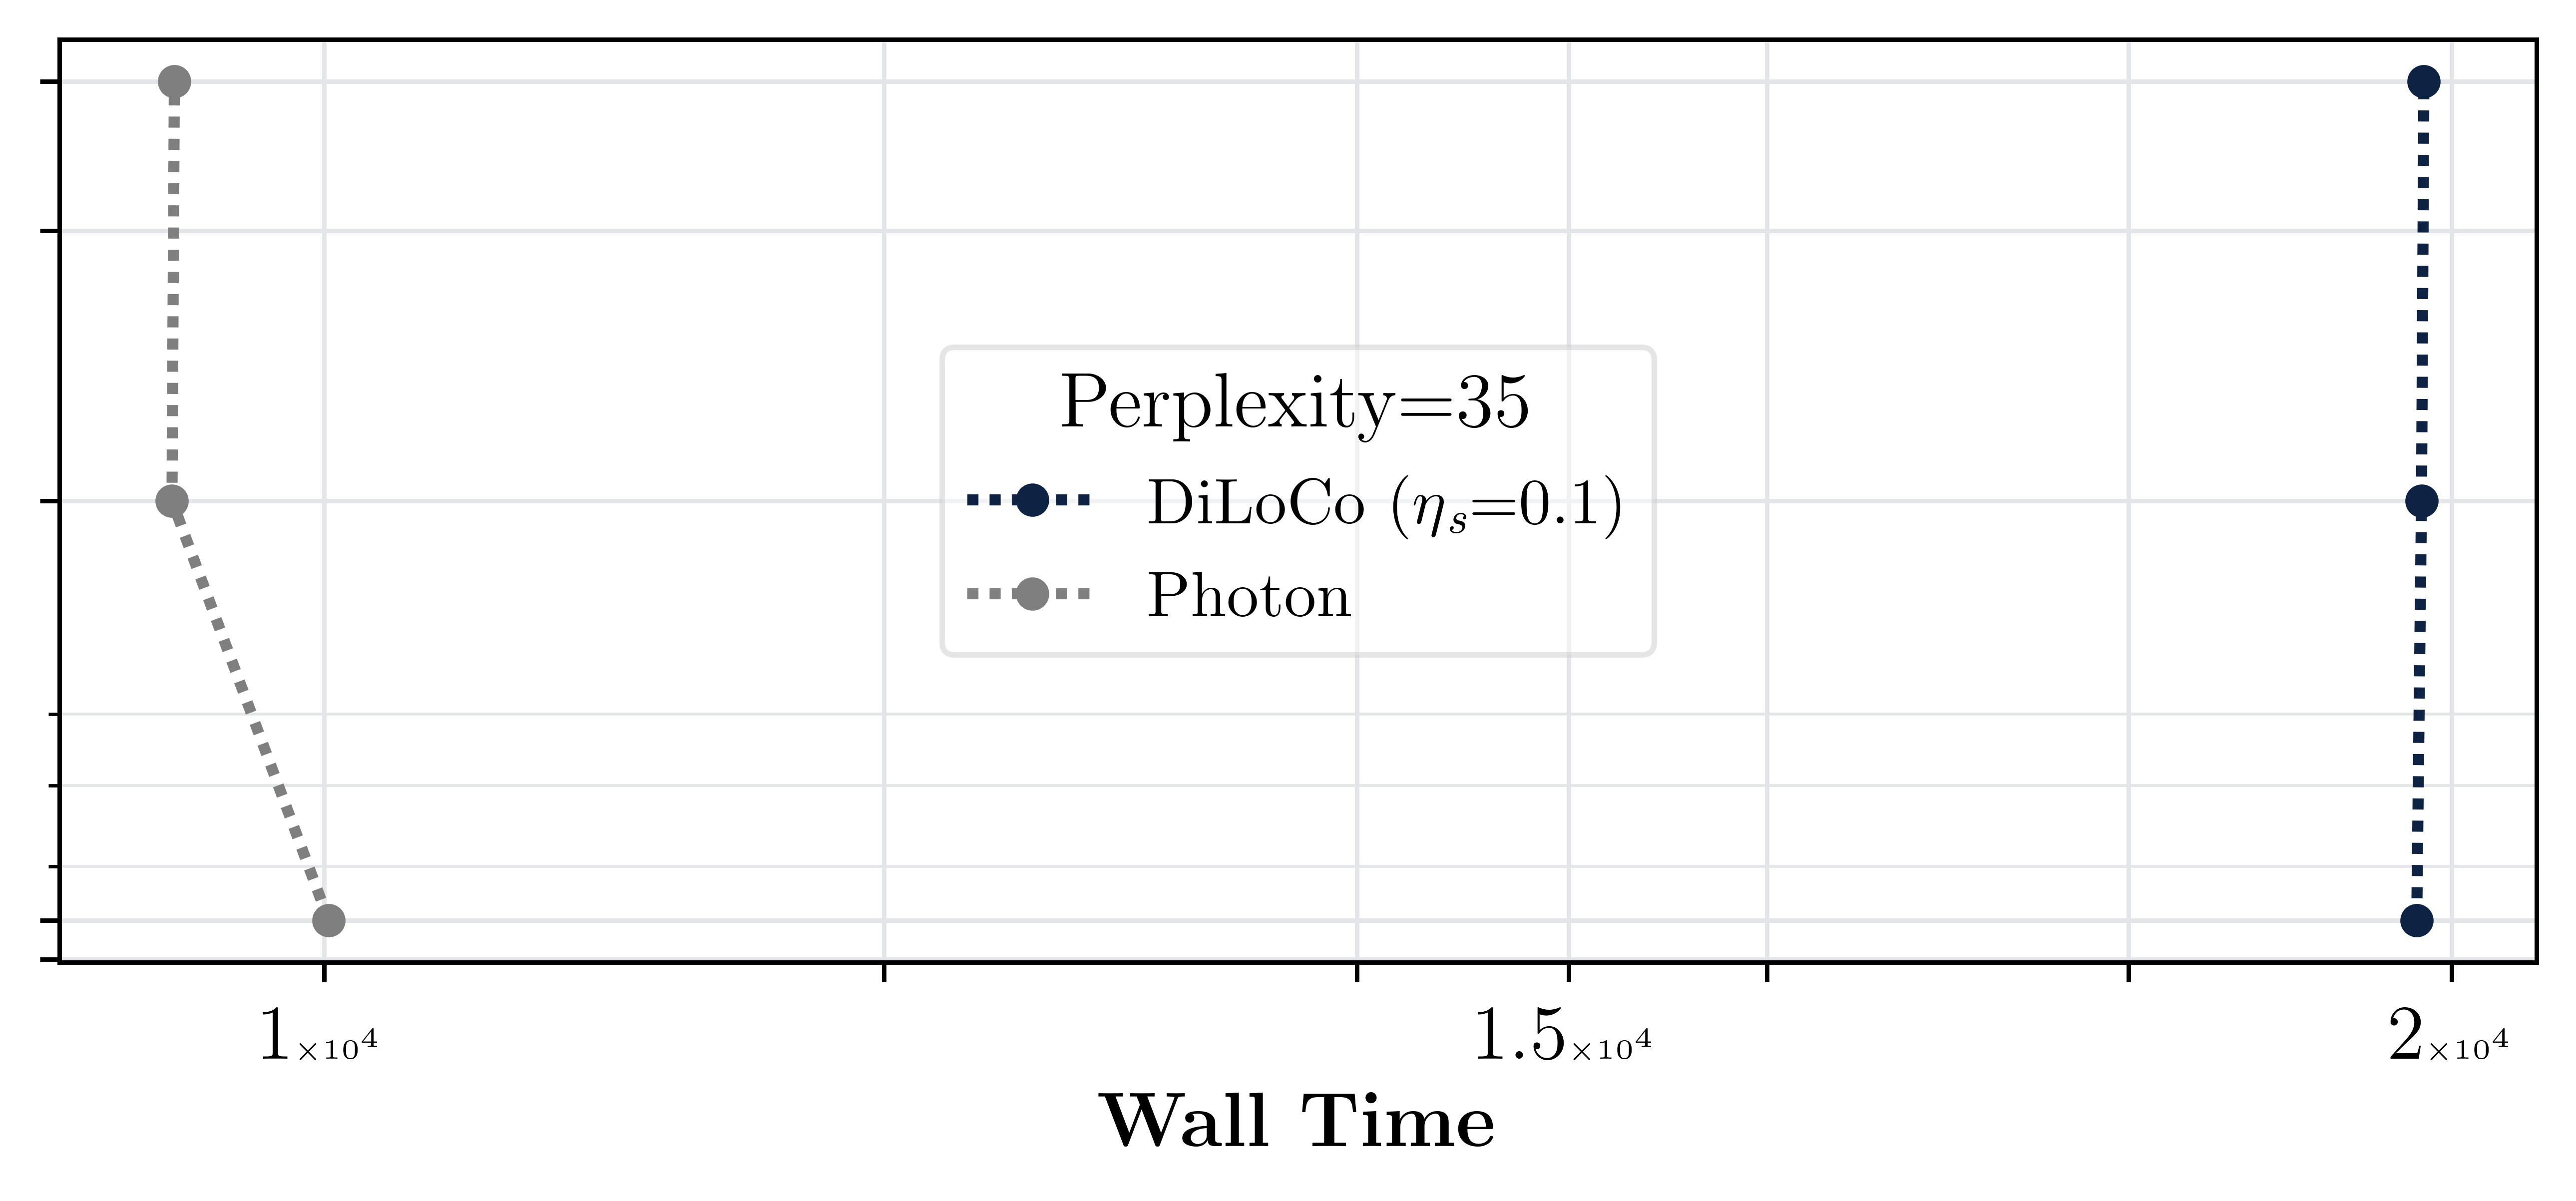

In [16]:
# Load the WandB data
experiment_type = "outer_optimizer"
for i, min_ppl in enumerate(reversed([35, 42])):
    fig = plt.figure(figsize=fig_size)
    for j, experiment_hp in enumerate(run_id_dict[experiment_type]):
        if experiment_hp != "diloco_0_1":
            continue
        y_coordinates: list[int] = []
        x_coordinates: list[float] = []
        for conf in sorted(
            [int(x) for x in run_id_dict[experiment_type][experiment_hp]]
        ):
            run_uuid = run_id_dict[experiment_type][experiment_hp][str(conf)][0]
            if run_uuid == "":
                continue
            try:
                server_metrics_df = pd.read_pickle(f"server_{run_uuid}.pkl")
                client_metrics_df = pd.read_pickle(f"clients_{run_uuid}.pkl")
            except FileNotFoundError:
                server_metrics_df, client_metrics_df = download_metrics(
                    *run_id_dict[experiment_type][experiment_hp][str(conf)]
                )
                # Dump the dataframes to pickle files
                server_metrics_df.to_pickle(f"server_{run_uuid}.pkl")
                client_metrics_df.to_pickle(f"clients_{run_uuid}.pkl")
            steps_to_min, new_min_ppl = find_federated_round_for_perplexity(
                client_metrics_df=client_metrics_df,
                perplexity_value=min_ppl,
                rolling_window=100,
            )
            min_ppl = min(min_ppl, new_min_ppl) if min_ppl is not None else new_min_ppl
            # Initialize the model
            n_local_steps = 512
            n_rounds = steps_to_min // n_local_steps
            model = WallTimeModel(
                num_rounds=n_rounds,
                num_clients_per_round=int(conf),
                num_parameters=125_000_000,
                local_steps=n_local_steps,
                local_throughput=2,  # 2 batches per second
            )

            # Calculate total wall time for different approaches
            total_wall_time_ps = model.total_wall_time_ps()
            total_wall_time_ar = model.total_wall_time_ar()
            total_wall_time_rar = model.total_wall_time_rar()

            y_coordinates.append(int(conf))
            x_coordinates.append(total_wall_time_rar)
        # Plot the y_coordinates against the x_coordinates
        plt.plot(
            x_coordinates,
            [y * 32 for y in y_coordinates],
            marker=".",
            label=r"DiLoCo ($\eta$\textit{\textsubscript{s}}=0.1)",
            color=color_palette[j],
            linestyle=line_styles[i],
        )
    for j, experiment_hp in enumerate(run_id_dict["full_participation"]):
        if experiment_hp != "512_steps":
            continue
        y_coordinates: list[int] = []
        # x_coordinates: list[int] = []
        x_coordinates: list[float] = []
        for conf in sorted(
            [int(x) for x in run_id_dict["full_participation"][experiment_hp]]
        ):
            if conf not in {2, 4, 8}:
                continue
            run_uuid = run_id_dict["full_participation"][experiment_hp][str(conf)][0]
            if run_uuid == "":
                continue
            try:
                server_metrics_df = pd.read_pickle(f"server_{run_uuid}.pkl")
                client_metrics_df = pd.read_pickle(f"clients_{run_uuid}.pkl")
            except FileNotFoundError:
                server_metrics_df, client_metrics_df = download_metrics(
                    *run_id_dict["full_participation"][experiment_hp][str(conf)]
                )
                # Dump the dataframes to pickle files
                server_metrics_df.to_pickle(f"server_{run_uuid}.pkl")
                client_metrics_df.to_pickle(f"clients_{run_uuid}.pkl")
            steps_to_min, new_min_ppl = find_federated_round_for_perplexity(
                client_metrics_df=client_metrics_df,
                perplexity_value=min_ppl,
                rolling_window=100,
            )
            min_ppl = min(min_ppl, new_min_ppl) if min_ppl is not None else new_min_ppl
            # Initialize the model
            n_local_steps = 512
            n_rounds = steps_to_min // n_local_steps
            model = WallTimeModel(
                num_rounds=n_rounds,
                num_clients_per_round=int(conf),
                num_parameters=125_000_000,
                local_steps=n_local_steps,
                local_throughput=2,  # 2 batches per second
            )

            # Calculate total wall time for different approaches
            total_wall_time_ps = model.total_wall_time_ps()
            total_wall_time_ar = model.total_wall_time_ar()
            total_wall_time_rar = model.total_wall_time_rar()

            y_coordinates.append(int(conf))
            x_coordinates.append(total_wall_time_rar)
        # Plot the y_coordinates against the x_coordinates
        plt.plot(
            x_coordinates,
            [y * 32 for y in y_coordinates],
            marker=".",
            label=SYSTEM_NAME,
            color=color_palette[j],
            linestyle=line_styles[i],
        )
    plt.xlabel(r"\textbf{Wall Time}")
    if i == 0:
        plt.ylabel(r"\textbf{Global Batch Size \textit{B\textsubscript{g}}}")
    plt.xscale("log")
    plt.yscale("log")
    # Change the minor grid to have a smaller linewidth
    plt.grid(axis="both", which="minor", lw=0.5)
    # Get the displayed xticks labels
    xticks_labels = plt.xticks()[0]
    log(INFO, xticks_labels)
    # Change the y ticks to report only the values 1, 2, 4, 8, 16
    plt.yticks([60, 64, 128, 200, 256], labels=["", "64", "128", "", "256"])
    # Change the x ticks
    if i == 0:
        plt.xticks(
            [5000, 6000, 7000, 8000, 9000, 10000],
            labels=[
                r"5{\tiny×10\textsuperscript{3}}",
                "",
                r"6{\tiny×10\textsuperscript{3}}",
                "",
                "",
                r"1{\tiny×10\textsuperscript{4}}",
            ],
        )
    else:
        # Remove the y ticks
        plt.yticks([60, 64, 128, 200, 256], labels=["", "", "", "", ""])
        plt.xticks(
            [10000, 12000, 14000, 15000, 16000, 18000, 20000],
            labels=[
                r"1{\tiny×10\textsuperscript{4}}",
                "",
                "",
                r"1.5{\tiny×10\textsuperscript{4}}",
                "",
                "",
                r"2{\tiny×10\textsuperscript{4}}",
            ],
        )
    plt.legend(
        loc="center",
        fontsize="small",
        framealpha=0.5,
        ncol=1,
        title=f"Perplexity={min_ppl}",
    )
    plt.savefig(f"wall_time_{experiment_type}_ppl{min_ppl}.pdf")
    plt.show()

In [17]:
import pandas as pd

# Load the WandB data
experiment_type = "outer_optimizer"
table_data = []

for i, min_ppl in enumerate(reversed([35, 42])):
    for j, experiment_hp in enumerate(run_id_dict[experiment_type]):
        if experiment_hp != "diloco_0_1":
            continue
        for conf in sorted(
            [int(x) for x in run_id_dict[experiment_type][experiment_hp]]
        ):
            run_uuid = run_id_dict[experiment_type][experiment_hp][str(conf)][0]
            if run_uuid == "":
                continue
            try:
                server_metrics_df = pd.read_pickle(f"server_{run_uuid}.pkl")
                client_metrics_df = pd.read_pickle(f"clients_{run_uuid}.pkl")
            except FileNotFoundError:
                server_metrics_df, client_metrics_df = download_metrics(
                    *run_id_dict[experiment_type][experiment_hp][str(conf)]
                )
                # Dump the dataframes to pickle files
                server_metrics_df.to_pickle(f"server_{run_uuid}.pkl")
                client_metrics_df.to_pickle(f"clients_{run_uuid}.pkl")
            steps_to_min, new_min_ppl = find_federated_round_for_perplexity(
                client_metrics_df=client_metrics_df,
                perplexity_value=min_ppl,
                rolling_window=100,
            )
            min_ppl = min(min_ppl, new_min_ppl) if min_ppl is not None else new_min_ppl
            # Initialize the model
            n_local_steps = 512
            n_rounds = steps_to_min // n_local_steps
            model = WallTimeModel(
                num_rounds=n_rounds,
                num_clients_per_round=int(conf),
                num_parameters=125_000_000,
                local_steps=n_local_steps,
                local_throughput=2,  # 2 batches per second
            )

            # Calculate total wall time for different approaches
            total_wall_time_ps = model.total_wall_time_ps()
            total_wall_time_ar = model.total_wall_time_ar()
            total_wall_time_rar = model.total_wall_time_rar()

            table_data.append(
                {
                    "Method": "DiLoCo $(\eta_s=0.1)$",
                    "Clients": conf,
                    "Total Wall Time RAR": total_wall_time_rar,
                    "Target Perplexity": min_ppl,
                }
            )

    for j, experiment_hp in enumerate(run_id_dict["full_participation"]):
        if experiment_hp != "512_steps":
            continue
        for conf in sorted(
            [int(x) for x in run_id_dict["full_participation"][experiment_hp]]
        ):
            if conf not in {2, 4, 8}:
                continue
            run_uuid = run_id_dict["full_participation"][experiment_hp][str(conf)][0]
            if run_uuid == "":
                continue
            try:
                server_metrics_df = pd.read_pickle(f"server_{run_uuid}.pkl")
                client_metrics_df = pd.read_pickle(f"clients_{run_uuid}.pkl")
            except FileNotFoundError:
                server_metrics_df, client_metrics_df = download_metrics(
                    *run_id_dict["full_participation"][experiment_hp][str(conf)]
                )
                # Dump the dataframes to pickle files
                server_metrics_df.to_pickle(f"server_{run_uuid}.pkl")
                client_metrics_df.to_pickle(f"clients_{run_uuid}.pkl")
            steps_to_min, new_min_ppl = find_federated_round_for_perplexity(
                client_metrics_df=client_metrics_df,
                perplexity_value=min_ppl,
                rolling_window=100,
            )
            min_ppl = min(min_ppl, new_min_ppl) if min_ppl is not None else new_min_ppl
            # Initialize the model
            n_local_steps = 512
            n_rounds = steps_to_min // n_local_steps
            model = WallTimeModel(
                num_rounds=n_rounds,
                num_clients_per_round=int(conf),
                num_parameters=125_000_000,
                local_steps=n_local_steps,
                local_throughput=2,  # 2 batches per second
            )

            # Calculate total wall time for different approaches
            total_wall_time_ps = model.total_wall_time_ps()
            total_wall_time_ar = model.total_wall_time_ar()
            total_wall_time_rar = model.total_wall_time_rar()

            table_data.append(
                {
                    "Method": SYSTEM_NAME,
                    "Clients": conf,
                    "Total Wall Time RAR": total_wall_time_rar,
                    "Target Perplexity": min_ppl,
                }
            )

# Convert the table data to a DataFrame and save it as a CSV file
table_df = pd.DataFrame(table_data)
# table_df.to_csv("wall_time_table.csv", index=False)
log(INFO, "Table: %s", table_df)

<>:51: DeprecationWarning: invalid escape sequence '\e'
INFO :      Table:                    Method  Clients  Total Wall Time RAR  Target Perplexity
0   DiLoCo $(\eta_s=0.1)$        2         10785.600004                 42
1   DiLoCo $(\eta_s=0.1)$        4         10545.200008                 42
2   DiLoCo $(\eta_s=0.1)$        8         10296.000016                 42
3                  Photon        2          5392.800002                 42
4                  Photon        4          5144.000004                 42
5                  Photon        8          5148.000008                 42
6   DiLoCo $(\eta_s=0.1)$        2         19773.600008                 35
7   DiLoCo $(\eta_s=0.1)$        4         19804.400015                 35
8   DiLoCo $(\eta_s=0.1)$        8         19819.800031                 35
9                  Photon        2         10015.200004                 35
10                 Photon        4          9516.400007                 35
11                 Photon

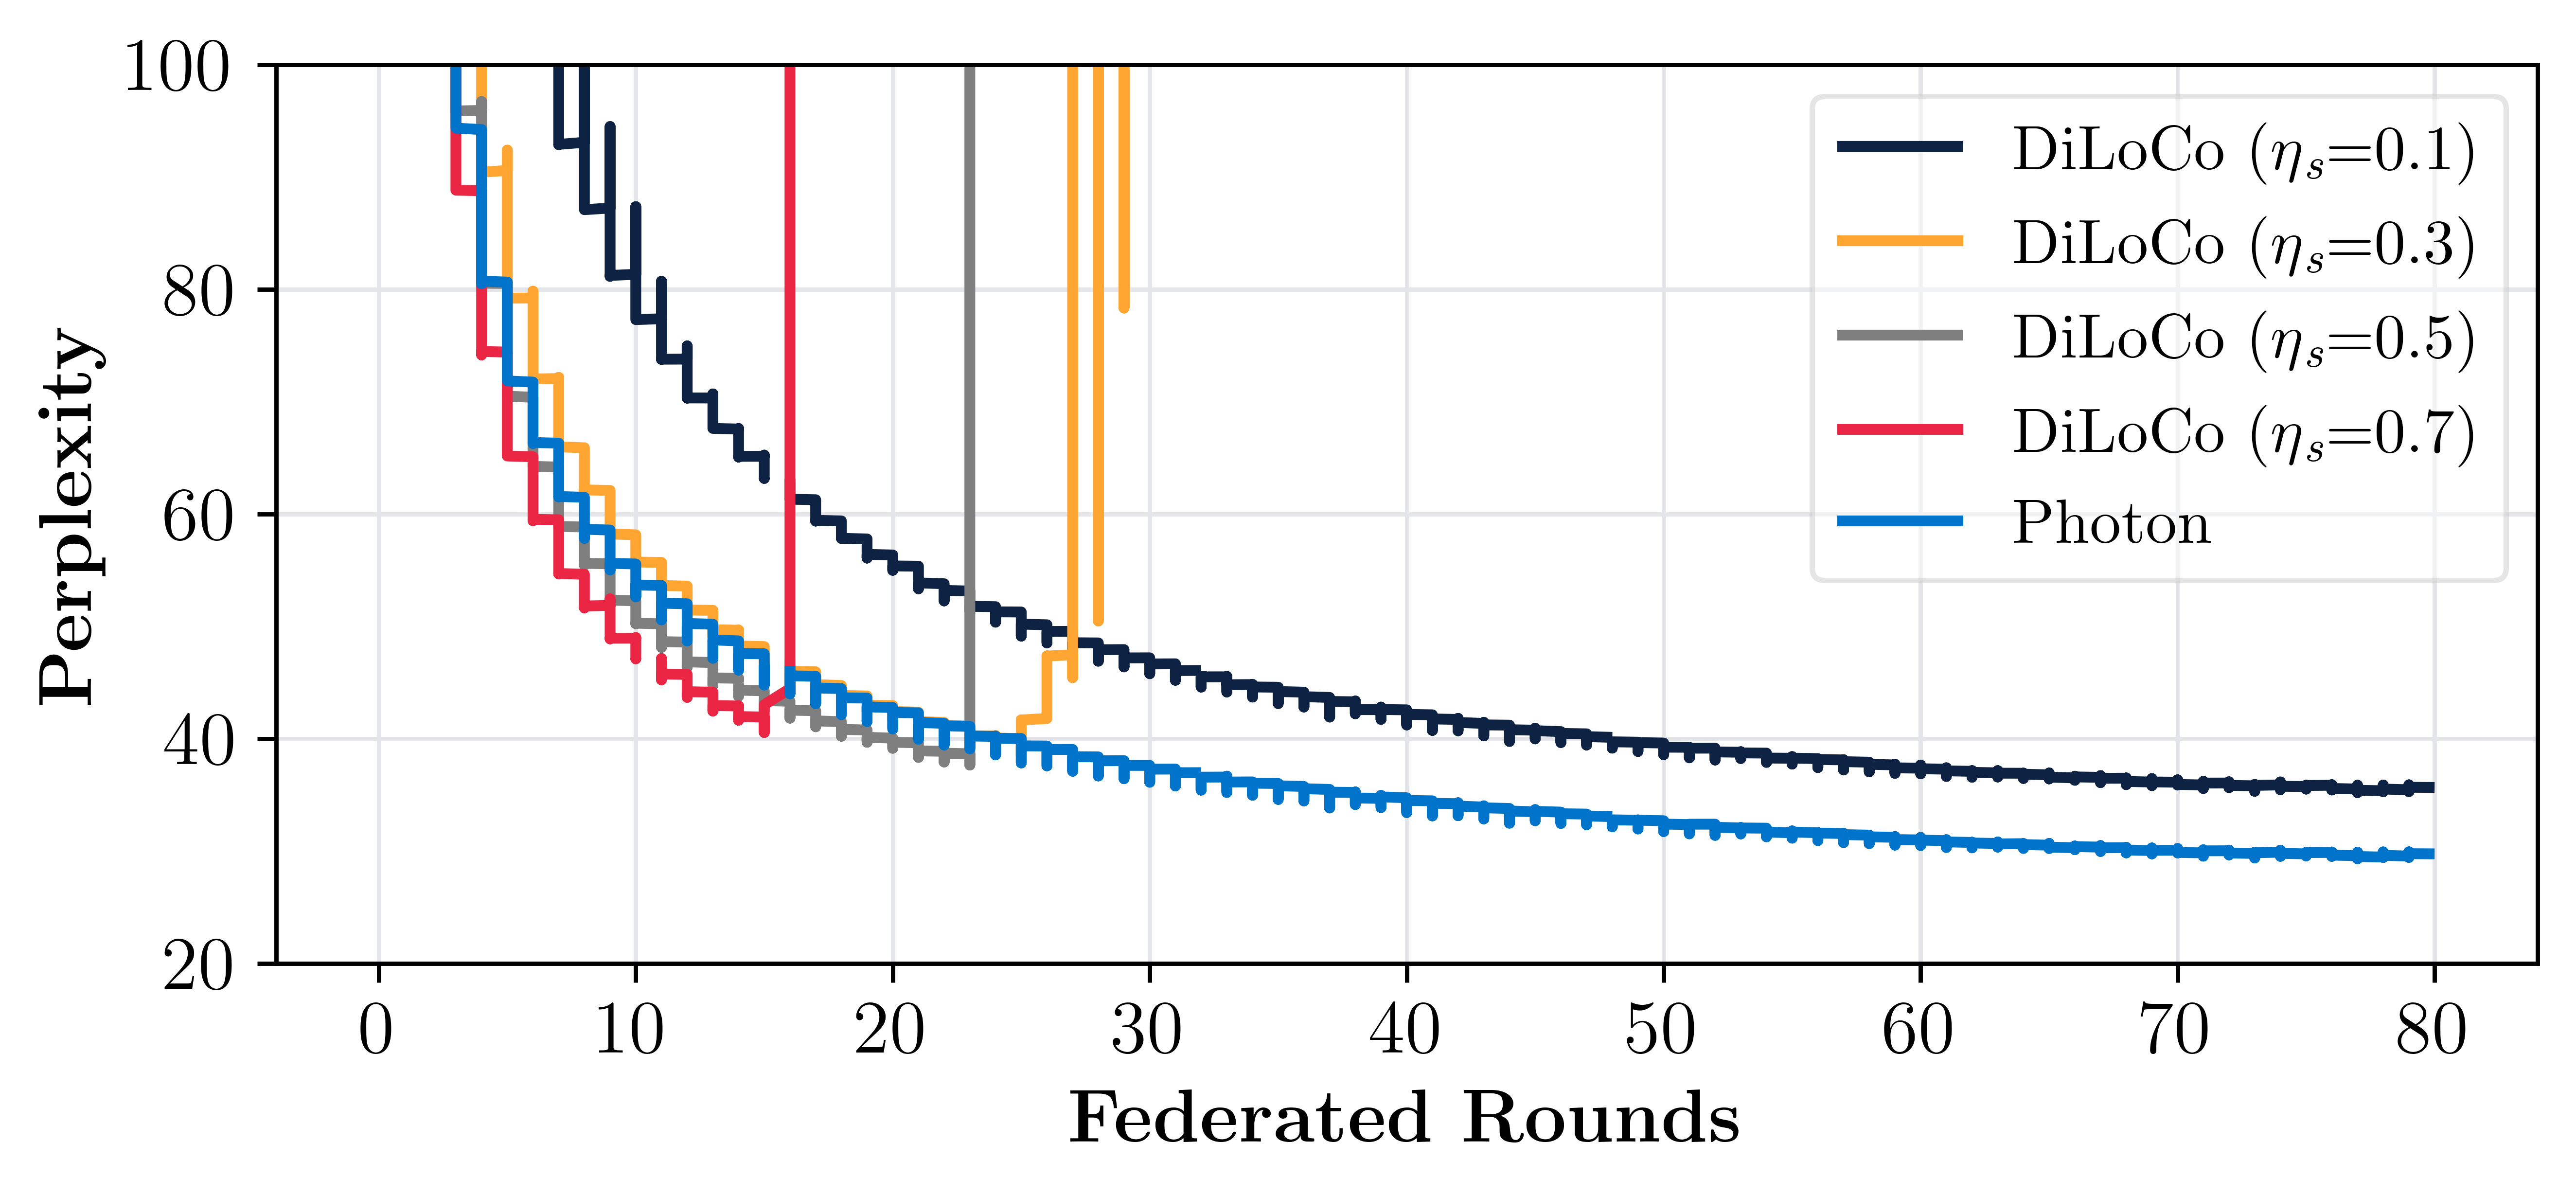

In [18]:
# Load the WandB data
experiment_type = "outer_optimizer"
fig = plt.figure(figsize=(7.5, 3))
for j, experiment_hp in enumerate(run_id_dict[experiment_type]):
    y_coordinates: list[int] = []
    x_coordinates: list[float] = []
    for conf in sorted([int(x) for x in run_id_dict[experiment_type][experiment_hp]]):
        run_uuid = run_id_dict[experiment_type][experiment_hp][str(conf)][0]
        if conf != 4:
            continue
        if run_uuid == "":
            continue
        try:
            client_metrics_df = pd.read_pickle(f"clients_{run_uuid}.pkl")
        except FileNotFoundError:
            _server_metrics_df, client_metrics_df = download_metrics(
                *run_id_dict[experiment_type][experiment_hp][str(conf)]
            )
            # Dump the dataframes to pickle files
            client_metrics_df.to_pickle(f"clients_{run_uuid}.pkl")
        steps_series, ppl_series = get_perplexity_series(
            client_metrics_df, moving_window=100
        )
        rounds_series = steps_series // 512
        server_learning_rate = float(
            experiment_hp.replace("diloco_", "").replace("_", ".")
        )
        # Plot the y_coordinates against the x_coordinates
        plt.plot(
            rounds_series,
            ppl_series,
            label=r"DiLoCo ($\eta$\textit{\textsubscript{s}}={%s})"
            % server_learning_rate,
            color=color_palette[j],
            linestyle=line_styles[0],
        )
run_uuid = run_id_dict["full_participation"]["512_steps"]["4"][0]
try:
    client_metrics_df = pd.read_pickle(f"clients_{run_uuid}.pkl")
except FileNotFoundError:
    _server_metrics_df, client_metrics_df = download_metrics(
        *run_id_dict["full_participation"]["512_steps"]["4"]
    )
    # Dump the dataframes to pickle files
    client_metrics_df.to_pickle(f"clients_{run_uuid}.pkl")
steps_series, ppl_series = get_perplexity_series(client_metrics_df, moving_window=100)
rounds_series = steps_series // 512
# Plot the y_coordinates against the x_coordinates
plt.plot(
    rounds_series,
    ppl_series,
    label=SYSTEM_NAME,
    color=color_palette[j + 1],
    linestyle=line_styles[0],
)
plt.xlabel(r"\textbf{Federated Rounds}")
plt.ylabel(r"\textbf{Perplexity}")
# Change the minor grid to have a smaller linewidth
plt.grid(axis="both", which="minor", lw=0.5)
# Set y-axis limits
plt.ylim(20, 100)
plt.legend()
plt.savefig("diloco_ppl_4cpr.pdf")
plt.show()

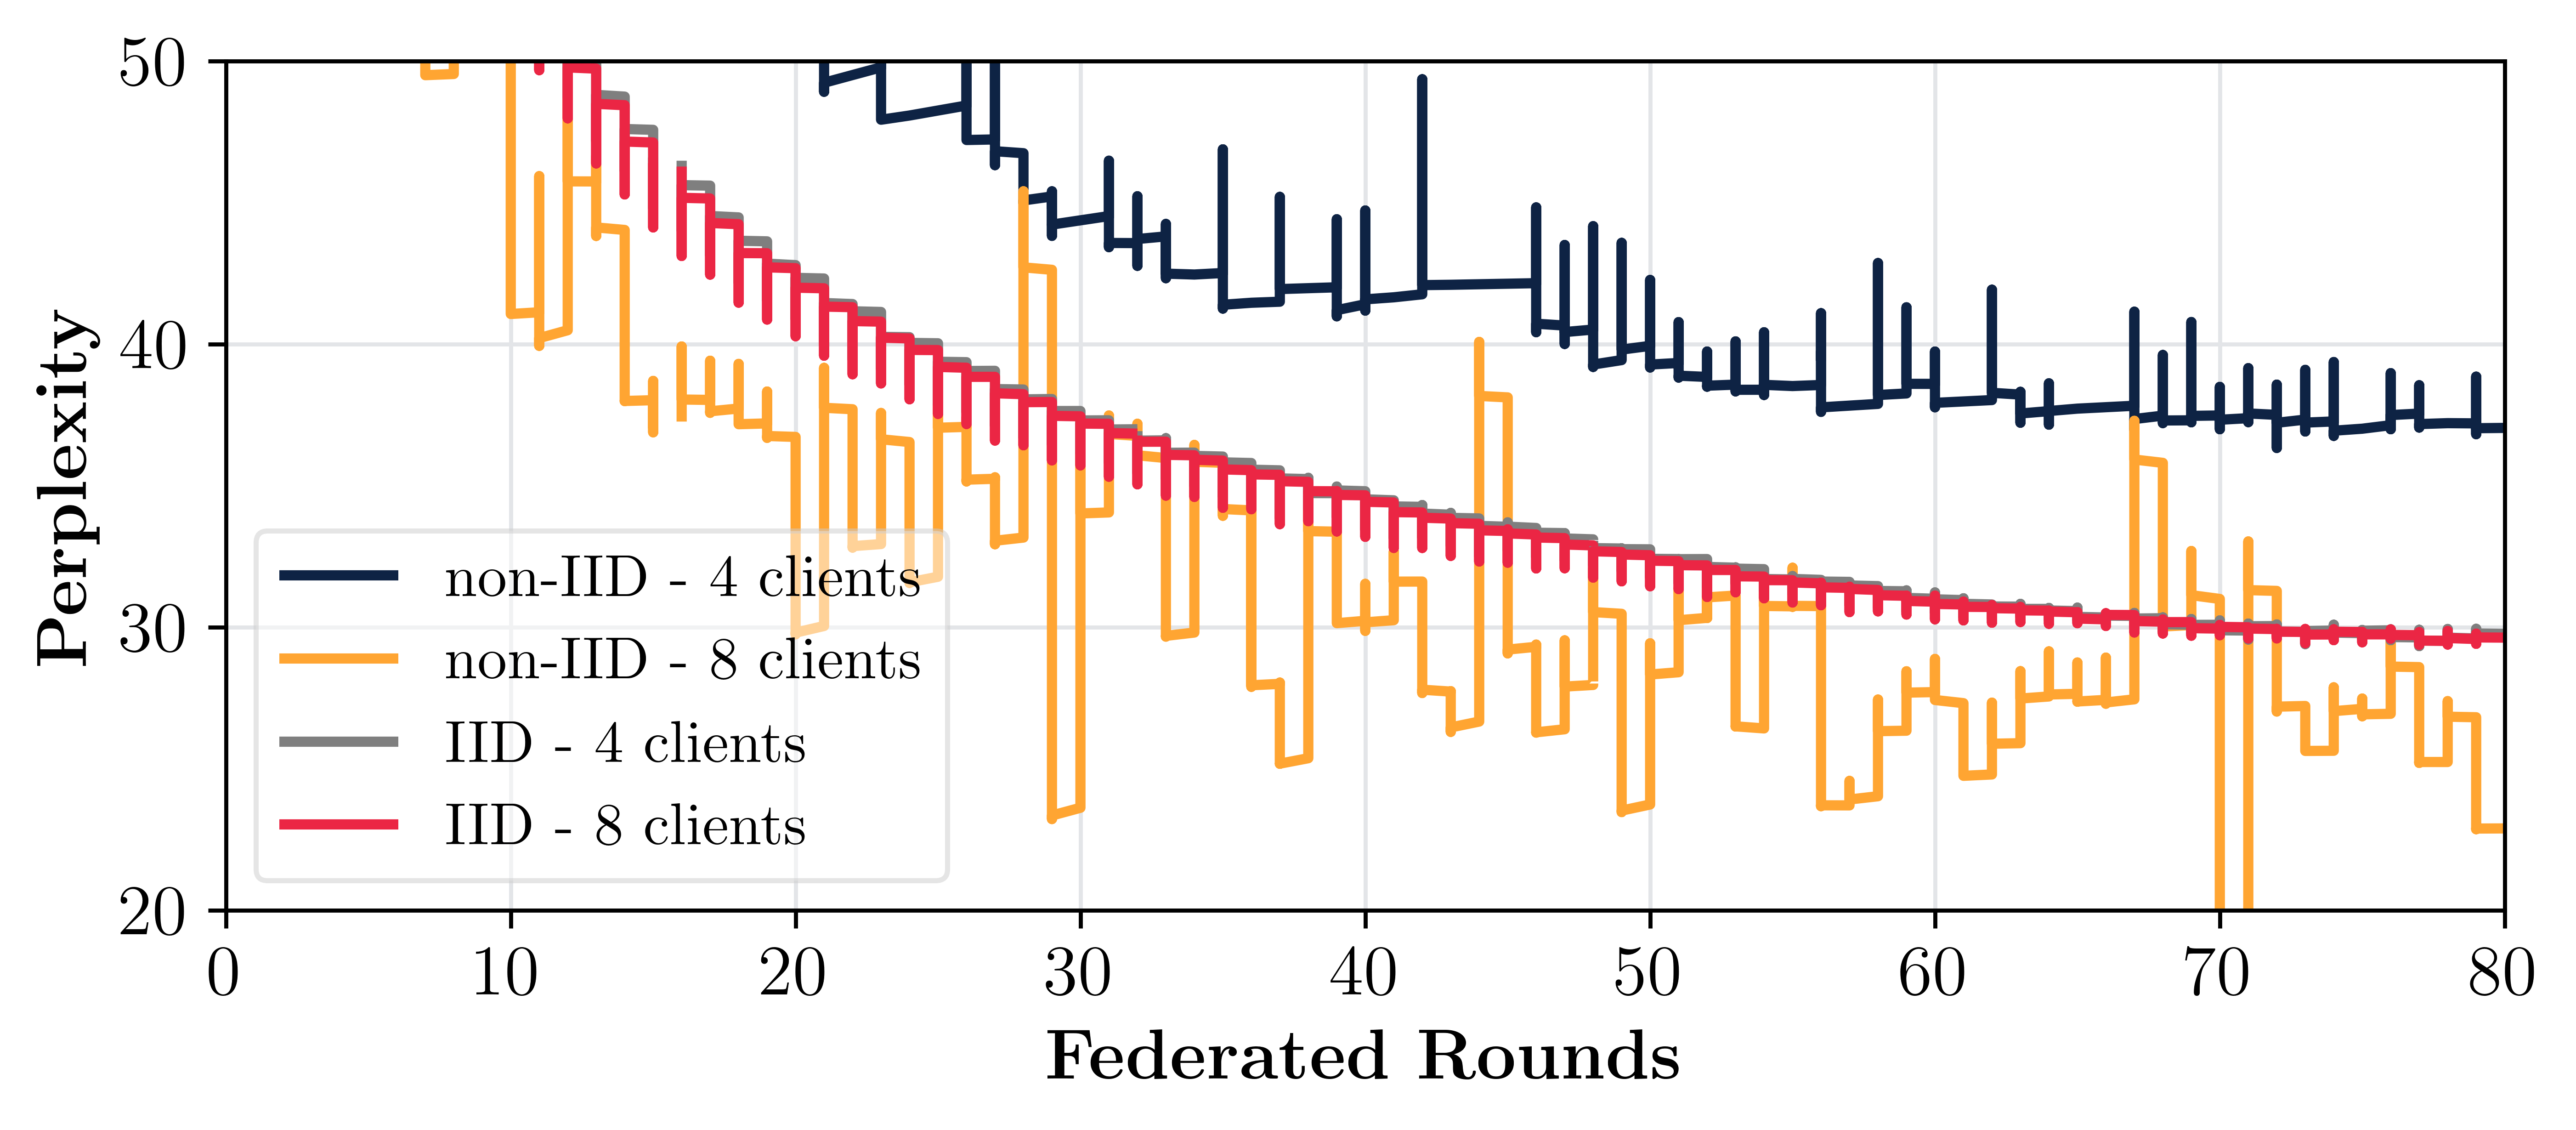

In [19]:
# Load the WandB data
experiment_type = "non_iid_data"
experiment_hp = "the_pile_partial"
fig = plt.figure(figsize=fig_size)
y_coordinates: list[int] = []
# x_coordinates: list[int] = []
x_coordinates: list[float] = []
j = 0
for j, conf in enumerate(
    sorted([int(x) for x in run_id_dict[experiment_type][experiment_hp]])
):
    run_uuid = run_id_dict[experiment_type][experiment_hp][str(conf)][0]
    if run_uuid == "":
        continue
    try:
        client_metrics_df = pd.read_pickle(f"clients_{run_uuid}.pkl")
    except FileNotFoundError:
        _server_metrics_df, client_metrics_df = download_metrics(
            *run_id_dict[experiment_type][experiment_hp][str(conf)]
        )
        # Dump the dataframes to pickle files
        client_metrics_df.to_pickle(f"clients_{run_uuid}.pkl")
    steps_series, ppl_series = get_perplexity_series(
        client_metrics_df, moving_window=100
    )
    rounds_series = steps_series // 512
    # Plot the y_coordinates against the x_coordinates
    plt.plot(
        rounds_series,
        ppl_series,
        label=f"non-IID - {conf} clients",
        color=color_palette[j],
        linestyle=line_styles[0],
    )
run_uuid = run_id_dict["full_participation"]["512_steps"]["4"][0]
try:
    client_metrics_df = pd.read_pickle(f"clients_{run_uuid}.pkl")
except FileNotFoundError:
    _server_metrics_df, client_metrics_df = download_metrics(
        *run_id_dict["full_participation"]["512_steps"]["4"]
    )
    # Dump the dataframes to pickle files
    client_metrics_df.to_pickle(f"clients_{run_uuid}.pkl")
steps_series, ppl_series = get_perplexity_series(client_metrics_df, moving_window=100)
rounds_series = steps_series // 512
# Plot the y_coordinates against the x_coordinates
plt.plot(
    rounds_series,
    ppl_series,
    label="IID - 4 clients",
    color=color_palette[j + 1],
    linestyle=line_styles[0],
)
run_uuid = run_id_dict["full_participation"]["512_steps"]["8"][0]
try:
    client_metrics_df = pd.read_pickle(f"clients_{run_uuid}.pkl")
except FileNotFoundError:
    _server_metrics_df, client_metrics_df = download_metrics(
        *run_id_dict["full_participation"]["512_steps"]["8"]
    )
    # Dump the dataframes to pickle files
    client_metrics_df.to_pickle(f"clients_{run_uuid}.pkl")
steps_series, ppl_series = get_perplexity_series(client_metrics_df, moving_window=100)
rounds_series = steps_series // 512
# Plot the y_coordinates against the x_coordinates
plt.plot(
    rounds_series,
    ppl_series,
    label="IID - 8 clients",
    color=color_palette[j + 2],
    linestyle=line_styles[0],
)
plt.xlabel(r"\textbf{Federated Rounds}")
plt.ylabel(r"\textbf{Perplexity}")
# Change the minor grid to have a smaller linewidth
plt.grid(axis="both", which="minor", lw=0.5)
# Set y-axis limits
plt.ylim(20, 50)
# Set x-axis limits
plt.xlim(0, 80)
# Format the tick labels
x_ticks_values, _ticks_labels = plt.xticks()
plt.xticks(x_ticks_values, labels=[rf"{int(x):,}" for x in x_ticks_values])
y_ticks_values, _ticks_labels = plt.yticks()
plt.yticks(y_ticks_values, labels=[rf"{int(y):,}" for y in y_ticks_values])
plt.legend()
plt.savefig("hetero_pp_ppl.pdf")
plt.show()

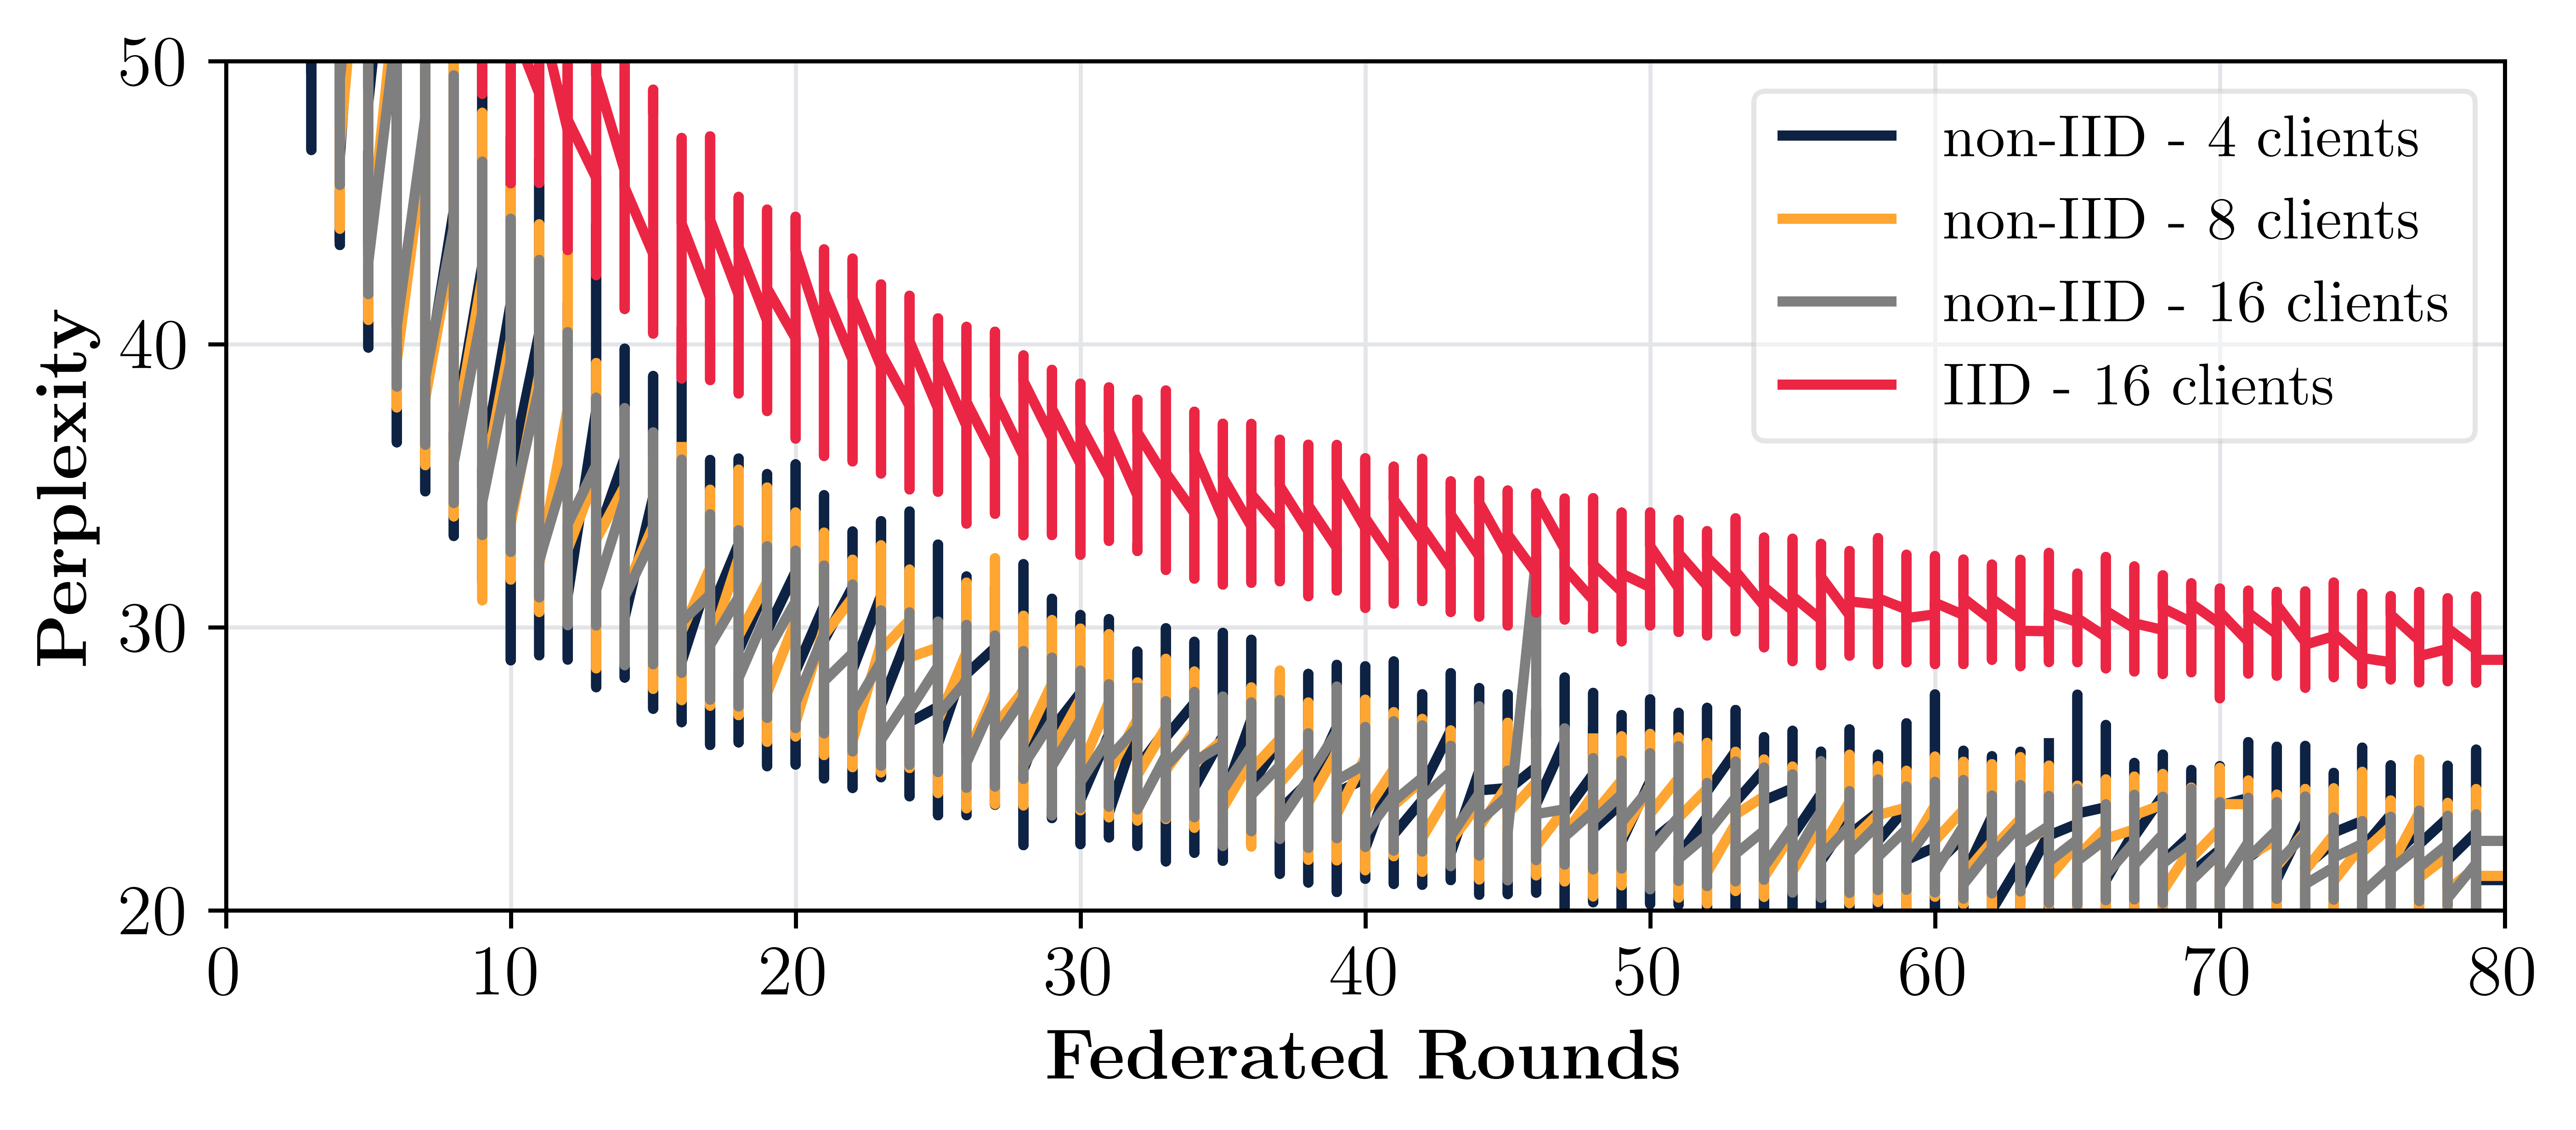

In [20]:
# Load the WandB data
experiment_type = "non_iid_data"
experiment_hp = "the_pile"
fig = plt.figure(figsize=fig_size)
y_coordinates: list[int] = []
# x_coordinates: list[int] = []
x_coordinates: list[float] = []
j = 0
for j, conf in enumerate(
    sorted([int(x) for x in run_id_dict[experiment_type][experiment_hp]])
):
    run_uuid = run_id_dict[experiment_type][experiment_hp][str(conf)][0]
    if run_uuid == "":
        continue
    try:
        client_metrics_df = pd.read_pickle(f"clients_{run_uuid}.pkl")
    except FileNotFoundError:
        _server_metrics_df, client_metrics_df = download_metrics(
            *run_id_dict[experiment_type][experiment_hp][str(conf)]
        )
        # Dump the dataframes to pickle files
        client_metrics_df.to_pickle(f"clients_{run_uuid}.pkl")
    steps_series, ppl_series = get_perplexity_series(client_metrics_df, moving_window=1)
    rounds_series = steps_series // 512
    # Plot the y_coordinates against the x_coordinates
    plt.plot(
        rounds_series,
        ppl_series,
        label=f"non-IID - {conf} clients",
        color=color_palette[j],
        linestyle=line_styles[0],
    )
run_uuid = run_id_dict["full_participation"]["512_steps"]["16"][0]
try:
    client_metrics_df = pd.read_pickle(f"clients_{run_uuid}.pkl")
except FileNotFoundError:
    _server_metrics_df, client_metrics_df = download_metrics(
        *run_id_dict["full_participation"]["512_steps"]["16"]
    )
    # Dump the dataframes to pickle files
    client_metrics_df.to_pickle(f"clients_{run_uuid}.pkl")
steps_series, ppl_series = get_perplexity_series(client_metrics_df, moving_window=1)
rounds_series = steps_series // 512
# Plot the y_coordinates against the x_coordinates
plt.plot(
    rounds_series,
    ppl_series,
    label="IID - 16 clients",
    color=color_palette[j + 1],
    linestyle=line_styles[0],
)
plt.xlabel(r"\textbf{Federated Rounds}")
plt.ylabel(r"\textbf{Perplexity}")
# Change the minor grid to have a smaller linewidth
plt.grid(axis="both", which="minor", lw=0.5)
# Set y-axis limits
plt.ylim(20, 50)
# Set x-axis limits
plt.xlim(0, 80)
# Format the tick labels
x_ticks_values, _ticks_labels = plt.xticks()
plt.xticks(x_ticks_values, labels=[rf"{int(x):,}" for x in x_ticks_values])
y_ticks_values, _ticks_labels = plt.yticks()
plt.yticks(y_ticks_values, labels=[rf"{int(y):,}" for y in y_ticks_values])
plt.legend()
plt.savefig("hetero_fp_ppl.pdf")
plt.show()

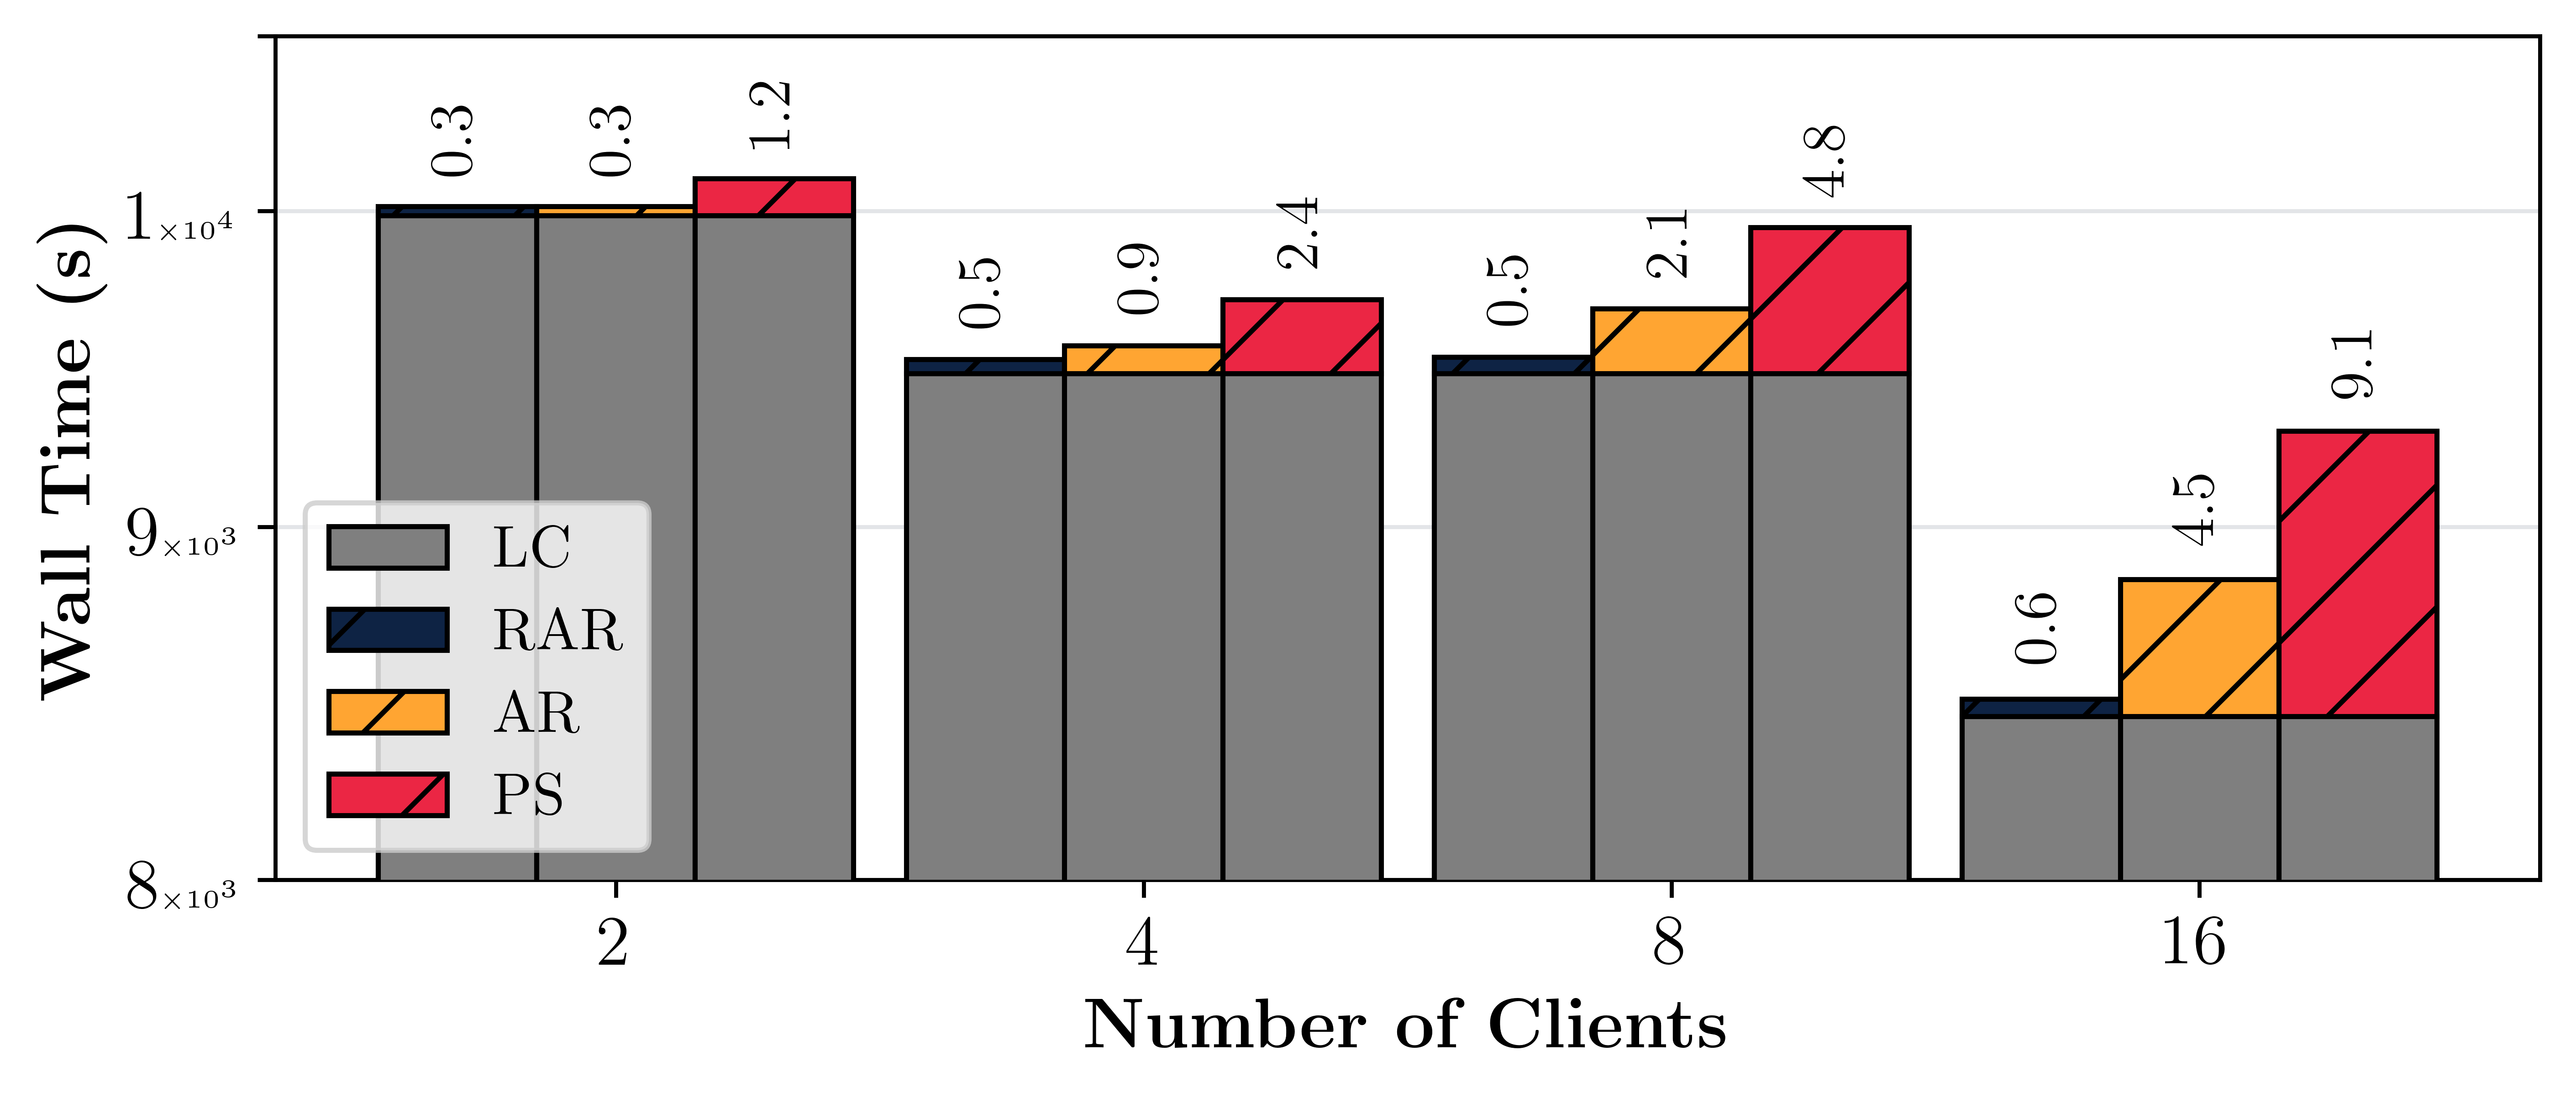

In [21]:
# Load the WandB data
experiment_type = "full_participation"
experiment_hp = "512_steps"
min_ppl = 35  # Cherry-picked value
bar_width = 0.3  # Width of each bar
fig = plt.figure(figsize=fig_size)

# Set grid lines with lower zorder to ensure they are in the background
plt.grid(axis="y", which="minor", lw=0.5, zorder=0)
plt.grid(axis="y", which="major", zorder=0)
plt.grid(visible=False, axis="x", which="major")
y_coordinates: list[int] = []
x_coordinates: list[float] = []
conf_values = sorted([int(x) for x in run_id_dict[experiment_type][experiment_hp]])
j = 0
for i, conf in enumerate(conf_values):
    if conf == 1:
        continue
    run_uuid = run_id_dict[experiment_type][experiment_hp][str(conf)][0]
    try:
        server_metrics_df = pd.read_pickle(f"server_{run_uuid}.pkl")
        client_metrics_df = pd.read_pickle(f"clients_{run_uuid}.pkl")
    except FileNotFoundError:
        server_metrics_df, client_metrics_df = download_metrics(
            *run_id_dict[experiment_type][experiment_hp][str(conf)]
        )
        # Dump the dataframes to pickle files
        server_metrics_df.to_pickle(f"server_{run_uuid}.pkl")
        client_metrics_df.to_pickle(f"clients_{run_uuid}.pkl")
    steps_to_min, new_min_ppl = find_federated_round_for_perplexity(
        client_metrics_df=client_metrics_df,
        perplexity_value=min_ppl,
        rolling_window=100,
    )
    # Initialize the model
    n_local_steps = int(experiment_hp.replace("_steps", ""))
    n_rounds = steps_to_min // n_local_steps
    model = WallTimeModel(
        num_rounds=n_rounds,
        num_clients_per_round=int(conf),
        num_parameters=125_000_000,
        local_steps=n_local_steps,
        local_throughput=2,  # 2 batches per second
    )

    # Calculate total wall time for different approaches
    round_compute_time = model.num_rounds * model.client_training_time()
    rar_rounds_comms_time = model.num_rounds * model.ring_allreduce_communication_time()
    ar_rounds_comms_time = model.num_rounds * model.allreduce_communication_time()
    ps_rounds_comms_time = (
        model.num_rounds * model.parameter_server_communication_time()
    )

    # Construct adjacent bars for each configuration
    plt.bar(
        (i + 1) - bar_width,
        round_compute_time,
        width=bar_width,
        color=color_palette[2],
        edgecolor="black",
        label="LC" if j == 0 else "",
        zorder=3,
    )
    j += 1
    plt.bar(
        (i + 1) - bar_width,
        rar_rounds_comms_time,
        bottom=round_compute_time,
        width=bar_width,
        label="RAR" if i == 1 else "",
        color=color_palette[0],
        edgecolor="black",
        zorder=3,
        hatch="/",
    )
    plt.bar(
        (i + 1),
        round_compute_time,
        width=bar_width,
        color=color_palette[2],
        edgecolor="black",
        zorder=3,
    )
    plt.bar(
        (i + 1),
        ar_rounds_comms_time,
        bottom=round_compute_time,
        width=bar_width,
        label="AR" if i == 1 else "",
        color=color_palette[1],
        edgecolor="black",
        zorder=3,
        hatch="/",
    )
    plt.bar(
        (i + 1) + bar_width,
        round_compute_time,
        width=bar_width,
        color=color_palette[2],
        edgecolor="black",
        zorder=3,
    )
    plt.bar(
        (i + 1) + bar_width,
        ps_rounds_comms_time,
        bottom=round_compute_time,
        width=bar_width,
        label="PS" if i == 1 else "",
        color=color_palette[3],
        edgecolor="black",
        zorder=3,
        hatch="/",
    )

    # Add percentage text on top of the bars
    plt.text(
        (i + 1) - bar_width,
        round_compute_time + rar_rounds_comms_time + 100,
        f"{(rar_rounds_comms_time / (round_compute_time + rar_rounds_comms_time)) * 100:.1f}%",
        ha="center",
        va="bottom",
        fontsize=12,
        zorder=4,
        rotation=90,  # Rotate text vertically
    )
    plt.text(
        (i + 1),
        round_compute_time + ar_rounds_comms_time + 100,
        f"{(ar_rounds_comms_time / (round_compute_time + ar_rounds_comms_time)) * 100:.1f}%",
        ha="center",
        va="bottom",
        fontsize=12,
        zorder=4,
        rotation=90,  # Rotate text vertically
    )
    plt.text(
        (i + 1) + bar_width,
        round_compute_time + ps_rounds_comms_time + 100,
        f"{(ps_rounds_comms_time / (round_compute_time + ps_rounds_comms_time)) * 100:.1f}%",
        ha="center",
        va="bottom",
        fontsize=12,
        zorder=4,
        rotation=90,  # Rotate text vertically
    )

# Customize the legend to assign the color to the number of steps and the line styles to the perplexity value
plt.legend(
    loc="lower left",
    # bbox_to_anchor=(0.05, 0.8),  # Adjust this tuple to move the legend
    fontsize="small",
    title_fontsize="medium",
    fancybox=True,
    framealpha=0.8,
    ncol=1,
)
plt.yscale("log")
plt.xticks(
    [2, 3, 4, 5],
    labels=["2", "4", "8", "16"],
)
plt.xlabel(r"\textbf{Number of Clients}")
plt.ylabel(r"\textbf{Wall Time (s)}")
plt.ylim(8_000, 10_200)
plt.yticks(
    [8_000, 9_000, 10_000, 10_600],
    labels=[
        r"8{\tiny ×10\textsuperscript{3}}",
        r"9{\tiny ×10\textsuperscript{3}}",
        r"1{\tiny ×10\textsuperscript{4}}",
        "",
    ],
)
plt.savefig("wall_time_split_bar_plot_512steps.pdf")
plt.show()

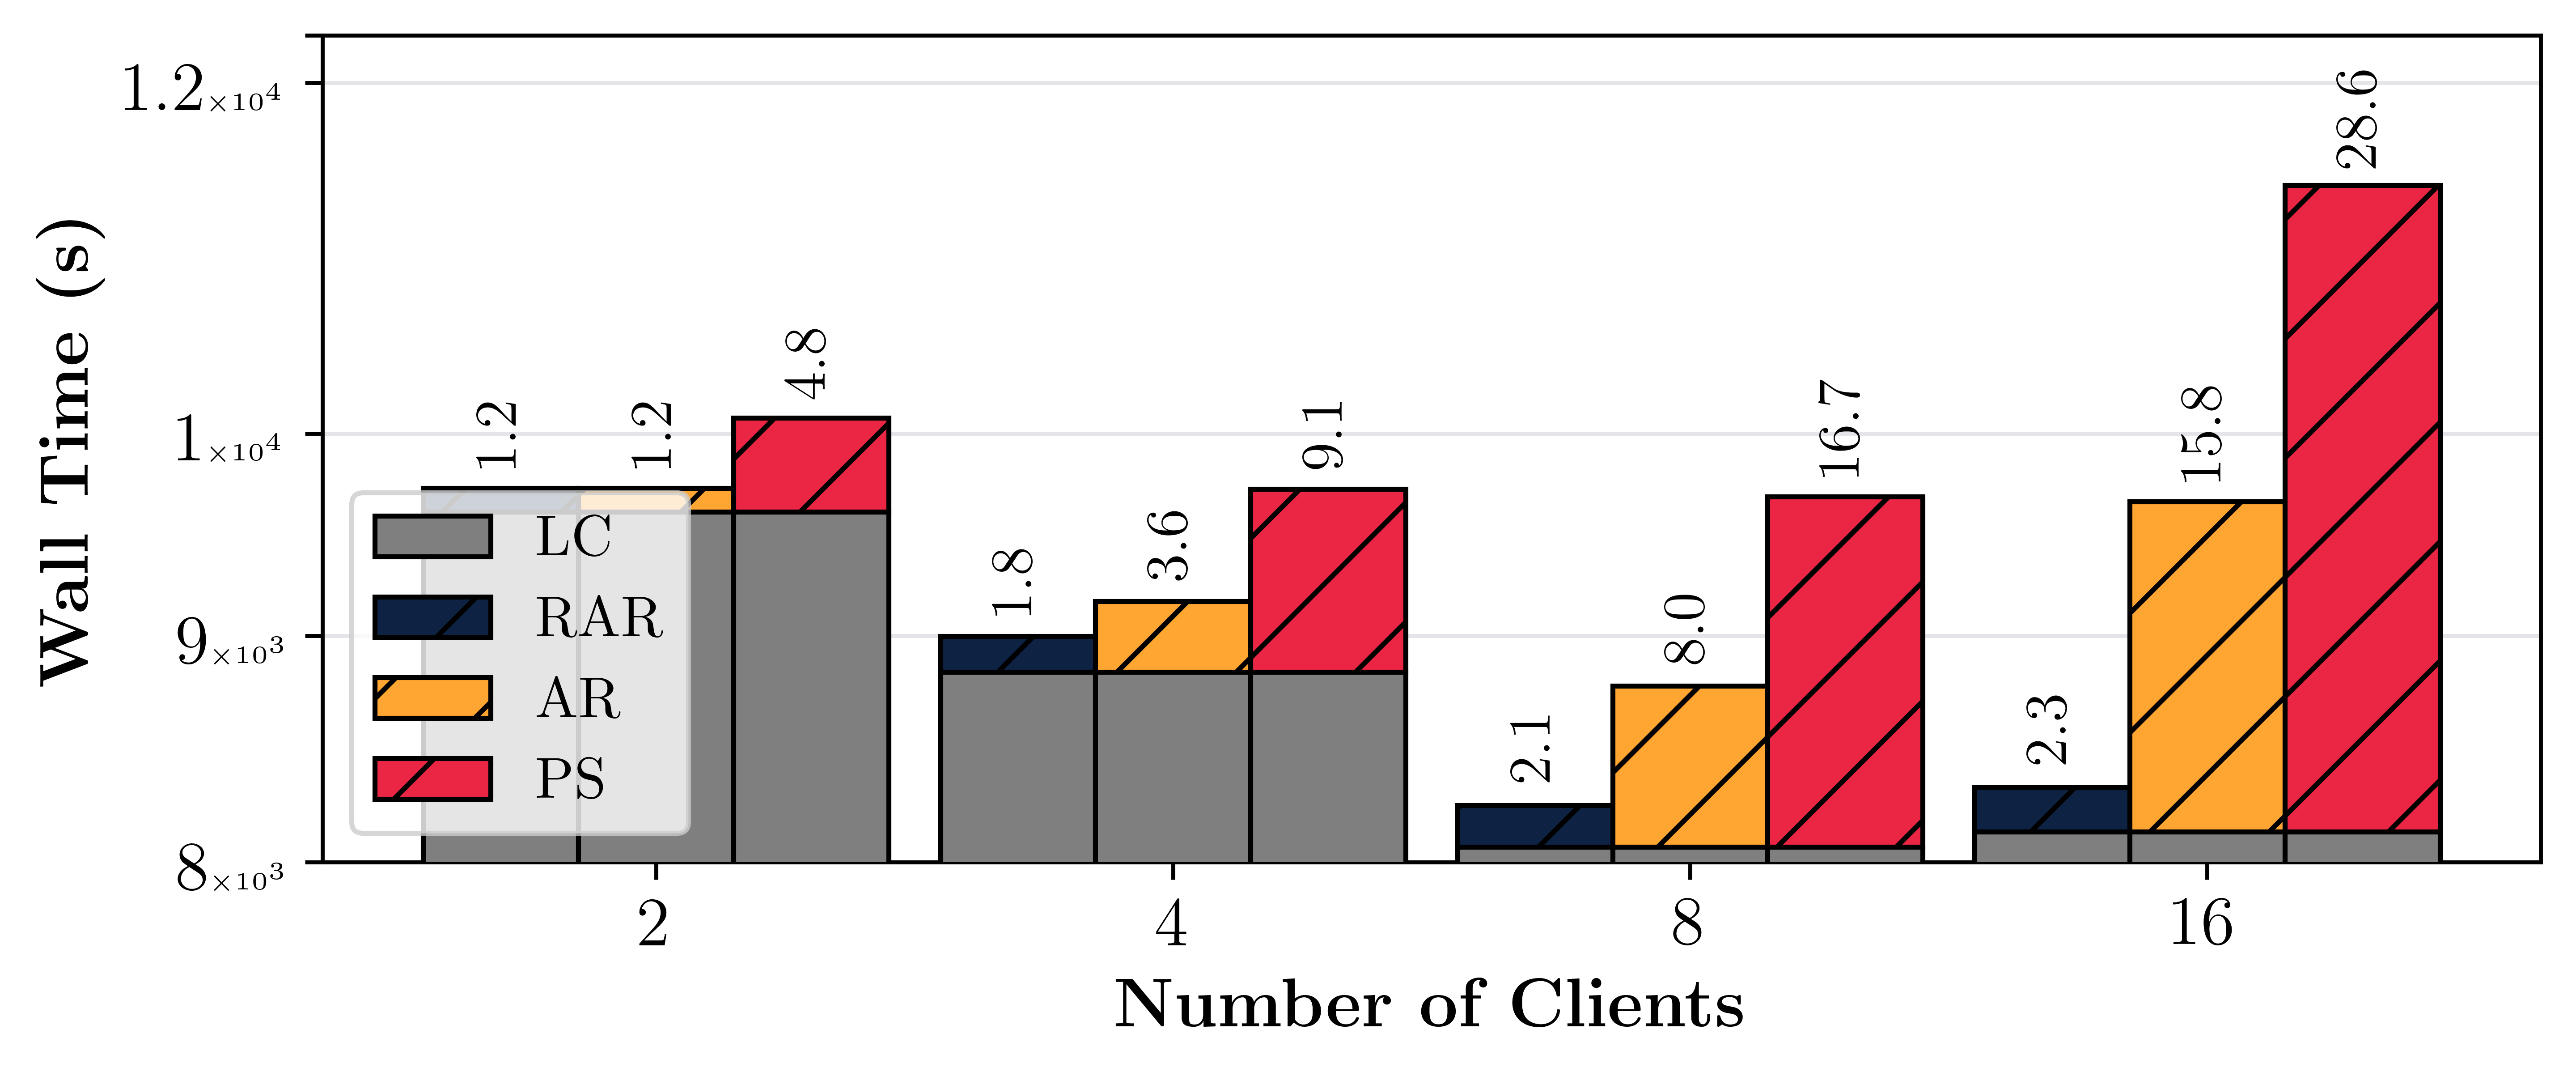

In [22]:
# Load the WandB data
experiment_type = "full_participation"
experiment_hp = "128_steps"
min_ppl = 35  # Cherry-picked value
bar_width = 0.3  # Width of each bar
fig = plt.figure(figsize=fig_size)

# Set grid lines with lower zorder to ensure they are in the background
plt.grid(axis="y", which="minor", lw=0.5, zorder=0)
plt.grid(axis="y", which="major", zorder=0)
plt.grid(visible=False, axis="x", which="major")
y_coordinates: list[int] = []
x_coordinates: list[float] = []
conf_values = sorted([int(x) for x in run_id_dict[experiment_type][experiment_hp]])
j = 0
for i, conf in enumerate(conf_values):
    if conf == 1:
        continue
    run_uuid = run_id_dict[experiment_type][experiment_hp][str(conf)][0]
    try:
        server_metrics_df = pd.read_pickle(f"server_{run_uuid}.pkl")
        client_metrics_df = pd.read_pickle(f"clients_{run_uuid}.pkl")
    except FileNotFoundError:
        server_metrics_df, client_metrics_df = download_metrics(
            *run_id_dict[experiment_type][experiment_hp][str(conf)]
        )
        # Dump the dataframes to pickle files
        server_metrics_df.to_pickle(f"server_{run_uuid}.pkl")
        client_metrics_df.to_pickle(f"clients_{run_uuid}.pkl")
    steps_to_min, new_min_ppl = find_federated_round_for_perplexity(
        client_metrics_df=client_metrics_df,
        perplexity_value=min_ppl,
        rolling_window=100,
    )
    # Initialize the model
    n_local_steps = int(experiment_hp.replace("_steps", ""))
    n_rounds = steps_to_min // n_local_steps
    model = WallTimeModel(
        num_rounds=n_rounds,
        num_clients_per_round=int(conf),
        num_parameters=125_000_000,
        local_steps=n_local_steps,
        local_throughput=2,  # 2 batches per second
    )

    # Calculate total wall time for different approaches
    round_compute_time = model.num_rounds * model.client_training_time()
    rar_rounds_comms_time = model.num_rounds * model.ring_allreduce_communication_time()
    ar_rounds_comms_time = model.num_rounds * model.allreduce_communication_time()
    ps_rounds_comms_time = (
        model.num_rounds * model.parameter_server_communication_time()
    )

    # Construct adjacent bars for each configuration
    plt.bar(
        (i + 1) - bar_width,
        round_compute_time,
        width=bar_width,
        color=color_palette[2],
        edgecolor="black",
        label="LC" if j == 0 else "",
        zorder=3,
    )
    j += 1
    plt.bar(
        (i + 1) - bar_width,
        rar_rounds_comms_time,
        bottom=round_compute_time,
        width=bar_width,
        label="RAR" if i == 1 else "",
        color=color_palette[0],
        edgecolor="black",
        zorder=3,
        hatch="/",
    )
    plt.bar(
        (i + 1),
        round_compute_time,
        width=bar_width,
        color=color_palette[2],
        edgecolor="black",
        zorder=3,
    )
    plt.bar(
        (i + 1),
        ar_rounds_comms_time,
        bottom=round_compute_time,
        width=bar_width,
        label="AR" if i == 1 else "",
        color=color_palette[1],
        edgecolor="black",
        zorder=3,
        hatch="/",
    )
    plt.bar(
        (i + 1) + bar_width,
        round_compute_time,
        width=bar_width,
        color=color_palette[2],
        edgecolor="black",
        zorder=3,
    )
    plt.bar(
        (i + 1) + bar_width,
        ps_rounds_comms_time,
        bottom=round_compute_time,
        width=bar_width,
        label="PS" if i == 1 else "",
        color=color_palette[3],
        edgecolor="black",
        zorder=3,
        hatch="/",
    )

    # Add percentage text on top of the bars
    plt.text(
        (i + 1) - bar_width,
        round_compute_time + rar_rounds_comms_time + 100,
        f"{(rar_rounds_comms_time / (round_compute_time + rar_rounds_comms_time)) * 100:.1f}%",
        ha="center",
        va="bottom",
        fontsize=12,
        zorder=4,
        rotation=90,  # Rotate text vertically
    )
    plt.text(
        (i + 1),
        round_compute_time + ar_rounds_comms_time + 100,
        f"{(ar_rounds_comms_time / (round_compute_time + ar_rounds_comms_time)) * 100:.1f}%",
        ha="center",
        va="bottom",
        fontsize=12,
        zorder=4,
        rotation=90,  # Rotate text vertically
    )
    plt.text(
        (i + 1) + bar_width,
        round_compute_time + ps_rounds_comms_time + 100,
        f"{(ps_rounds_comms_time / (round_compute_time + ps_rounds_comms_time)) * 100:.1f}%",
        ha="center",
        va="bottom",
        fontsize=12,
        zorder=4,
        rotation=90,  # Rotate text vertically
    )

# Customize the legend to assign the color to the number of steps and the line styles to the perplexity value
plt.legend(
    loc="lower left",
    # bbox_to_anchor=(0.05, 0.46),  # Adjust this tuple to move the legend
    fontsize="small",
    title_fontsize="medium",
    fancybox=True,
    framealpha=0.8,
    ncol=1,
)
plt.yscale("log")
plt.xticks(
    [2, 3, 4, 5],
    labels=["2", "4", "8", "16"],
)
plt.xlabel(r"\textbf{Number of Clients}")
plt.ylabel(r"\textbf{Wall Time (s)}")
plt.ylim(8_000, 10_200)
plt.yticks(
    [8_000, 9_000, 10_000, 12_000, 12_300],
    labels=[
        r"8{\tiny ×10\textsuperscript{3}}",
        r"9{\tiny ×10\textsuperscript{3}}",
        r"1{\tiny ×10\textsuperscript{4}}",
        r"1.2{\tiny ×10\textsuperscript{4}}",
        "",
    ],
)
plt.savefig("wall_time_split_bar_plot_128steps.pdf")
plt.show()

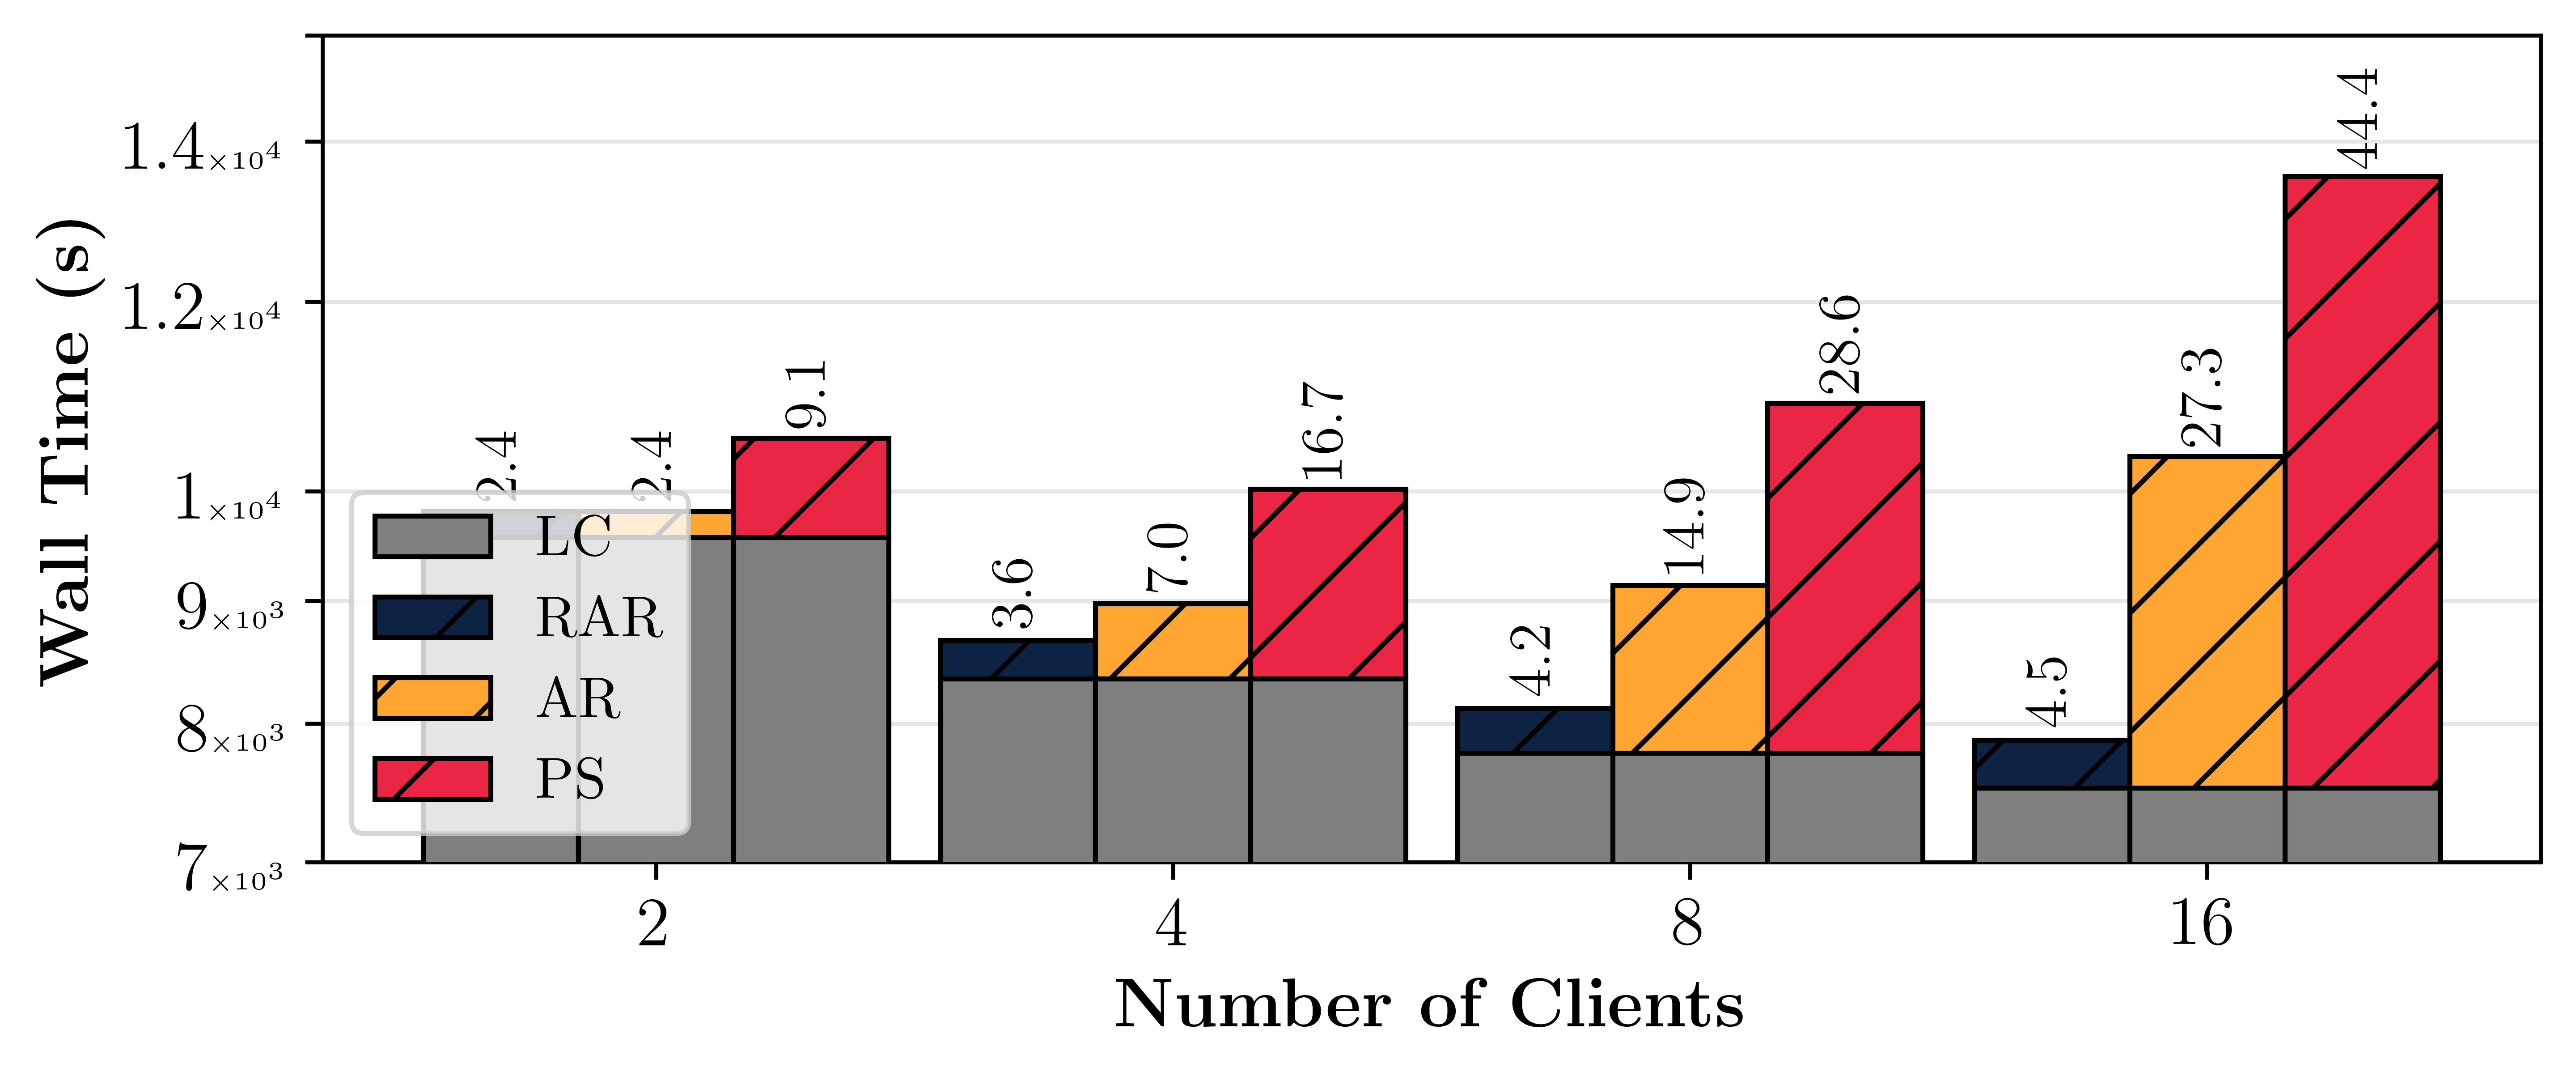

In [23]:
# Load the WandB data
experiment_type = "full_participation"
experiment_hp = "64_steps"
min_ppl = 35  # Cherry-picked value
bar_width = 0.3  # Width of each bar
fig = plt.figure(figsize=fig_size)

# Set grid lines with lower zorder to ensure they are in the background
plt.grid(axis="y", which="minor", lw=0.5, zorder=0)
plt.grid(axis="y", which="major", zorder=0)
plt.grid(visible=False, axis="x", which="major")
y_coordinates: list[int] = []
x_coordinates: list[float] = []
conf_values = sorted([int(x) for x in run_id_dict[experiment_type][experiment_hp]])
j = 0
for i, conf in enumerate(conf_values):
    if conf == 1:
        continue
    run_uuid = run_id_dict[experiment_type][experiment_hp][str(conf)][0]
    try:
        server_metrics_df = pd.read_pickle(f"server_{run_uuid}.pkl")
        client_metrics_df = pd.read_pickle(f"clients_{run_uuid}.pkl")
    except FileNotFoundError:
        server_metrics_df, client_metrics_df = download_metrics(
            *run_id_dict[experiment_type][experiment_hp][str(conf)]
        )
        # Dump the dataframes to pickle files
        server_metrics_df.to_pickle(f"server_{run_uuid}.pkl")
        client_metrics_df.to_pickle(f"clients_{run_uuid}.pkl")
    steps_to_min, new_min_ppl = find_federated_round_for_perplexity(
        client_metrics_df=client_metrics_df,
        perplexity_value=min_ppl,
        rolling_window=100,
    )
    # Initialize the model
    n_local_steps = int(experiment_hp.replace("_steps", ""))
    n_rounds = steps_to_min // n_local_steps
    model = WallTimeModel(
        num_rounds=n_rounds,
        num_clients_per_round=int(conf),
        num_parameters=125_000_000,
        local_steps=n_local_steps,
        local_throughput=2,  # 2 batches per second
    )

    # Calculate total wall time for different approaches
    round_compute_time = model.num_rounds * model.client_training_time()
    rar_rounds_comms_time = model.num_rounds * model.ring_allreduce_communication_time()
    ar_rounds_comms_time = model.num_rounds * model.allreduce_communication_time()
    ps_rounds_comms_time = (
        model.num_rounds * model.parameter_server_communication_time()
    )

    # Construct adjacent bars for each configuration
    plt.bar(
        (i + 1) - bar_width,
        round_compute_time,
        width=bar_width,
        color=color_palette[2],
        edgecolor="black",
        label="LC" if j == 0 else "",
        zorder=3,
    )
    j += 1
    plt.bar(
        (i + 1) - bar_width,
        rar_rounds_comms_time,
        bottom=round_compute_time,
        width=bar_width,
        label="RAR" if i == 1 else "",
        color=color_palette[0],
        edgecolor="black",
        zorder=3,
        hatch="/",
    )
    plt.bar(
        (i + 1),
        round_compute_time,
        width=bar_width,
        color=color_palette[2],
        edgecolor="black",
        zorder=3,
    )
    plt.bar(
        (i + 1),
        ar_rounds_comms_time,
        bottom=round_compute_time,
        width=bar_width,
        label="AR" if i == 1 else "",
        color=color_palette[1],
        edgecolor="black",
        zorder=3,
        hatch="/",
    )
    plt.bar(
        (i + 1) + bar_width,
        round_compute_time,
        width=bar_width,
        color=color_palette[2],
        edgecolor="black",
        zorder=3,
    )
    plt.bar(
        (i + 1) + bar_width,
        ps_rounds_comms_time,
        bottom=round_compute_time,
        width=bar_width,
        label="PS" if i == 1 else "",
        color=color_palette[3],
        edgecolor="black",
        zorder=3,
        hatch="/",
    )

    # Add percentage text on top of the bars
    plt.text(
        (i + 1) - bar_width,
        round_compute_time + rar_rounds_comms_time + 100,
        f"{(rar_rounds_comms_time / (round_compute_time + rar_rounds_comms_time)) * 100:.1f}%",
        ha="center",
        va="bottom",
        fontsize=12,
        zorder=4,
        rotation=90,  # Rotate text vertically
    )
    plt.text(
        (i + 1),
        round_compute_time + ar_rounds_comms_time + 100,
        f"{(ar_rounds_comms_time / (round_compute_time + ar_rounds_comms_time)) * 100:.1f}%",
        ha="center",
        va="bottom",
        fontsize=12,
        zorder=4,
        rotation=90,  # Rotate text vertically
    )
    plt.text(
        (i + 1) + bar_width,
        round_compute_time + ps_rounds_comms_time + 100,
        f"{(ps_rounds_comms_time / (round_compute_time + ps_rounds_comms_time)) * 100:.1f}%",
        ha="center",
        va="bottom",
        fontsize=12,
        zorder=4,
        rotation=90,  # Rotate text vertically
    )

# Customize the legend to assign the color to the number of steps and the line styles to the perplexity value
plt.legend(
    loc="lower left",
    # bbox_to_anchor=(0.01, 1.0),  # Adjust this tuple to move the legend
    fontsize="small",
    title_fontsize="medium",
    fancybox=True,
    framealpha=0.8,
    ncol=1,
)
plt.yscale("log")
plt.xticks(
    [2, 3, 4, 5],
    labels=["2", "4", "8", "16"],
)
plt.xlabel(r"\textbf{Number of Clients}")
plt.ylabel(r"\textbf{Wall Time (s)}")
plt.ylim(7_000, 10_200)
plt.yticks(
    [7_000, 8_000, 9_000, 10_000, 12_000, 14_000, 15_500],
    labels=[
        r"7{\tiny ×10\textsuperscript{3}}",
        r"8{\tiny ×10\textsuperscript{3}}",
        r"9{\tiny ×10\textsuperscript{3}}",
        r"1{\tiny ×10\textsuperscript{4}}",
        r"1.2{\tiny ×10\textsuperscript{4}}",
        r"1.4{\tiny ×10\textsuperscript{4}}",
        "",
    ],
)
plt.savefig("wall_time_split_bar_plot_64steps.pdf")
plt.show()

In [24]:
SERVER_BANDWIDTH = 125  # 125 MBps == 1Gbps
SERVER_BANDWIDTH = 1_250  # 10 Gbps
SERVER_BANDWIDTH = 50_000  # 400 Gbps -- one link fast RoCE/IB
SERVER_BANDWIDTH = 200_000  # 1600 Gbps -- four link fast RoCE/IB
SERVER_BANDWIDTH = 250  # 250 MBps == 2Gbps
SERVER_BANDWIDTH = 312.5  # 312.5 MBps == 2.5Gbps
SERVER_BANDWIDTH = 625  # 625 MBps == 5Gbps
SERVER_BANDWIDTH = 1_250  # 10 Gbps
SERVER_BANDWIDTH = 12_500  # 100 Gbps -- one link slow RoCE/IB
SERVER_BANDWIDTH1 = SERVER_BANDWIDTH

In [25]:
# Going forward in the convergence curve

# fed 1B min PPL: 18.26742 @ 9700 total steps
# cen 1B PPL: 18.26171 @ 19759 total steps

# fed 3B min PPL: 16.13603 @ 13000 total steps
# cen 3B PPL: 16.13357 @ 22900 total steps

# fed 7B min PPL: 14.04218 @ 11000 total steps
# cen 7B PPL: 14.03865 @ 21908 total steps

# Going backward in the convergence curve

# fed 1B min PPL: 21.30412 @ 6000 total steps
# cen 1B PPL: 21.31308 @ 10000 total steps

# fed 3B min PPL: 18.56525 @ 7500 total steps
# cen 3B PPL: 18.319 @ 13000 total steps

# fed 7B min PPL: 16.62725 @ 6000 total steps
# cen 7B PPL: 16.35467 @ 11000 total steps

# Fixing to PPL at around 21

# fed 7B min PPL: 20.95154 @ 4000 total steps
# cen 7B PPL: 21.24964 @ 4900 total steps

# fed 3B min PPL: 21.05414 @ 5500 total steps
# cen 3B PPL: 21.30629 @ 7162 total steps

In [26]:
# DDP 4xH100, cen-bench-1B-bs64-20241030_091814_centralised,
# FED: local MFU (pre device) 1.1245, avg 83% GPU utilization locally
# CEN: local MFU (pre device) 0.8027, avg 74% GPU utilization locally
global_batch_size = 512
local_batch_size = 8
gradient_accumulation_steps = 8
single_worker_client_throughput = 0.8396  # batches per second
n_workers_clients = global_batch_size // (
    local_batch_size * gradient_accumulation_steps
)
# single_worker_client_throughput = 0.8396  # batches per second
fed_single_worker_client_throughput = 0.147  # batches per second
cen_single_worker_client_throughput = 0.8396  # batches per second
n_rounds = 19
n_local_steps = 500
fed_1b = WallTimeModel(
    num_rounds=n_rounds,
    num_clients_per_round=n_workers_clients,
    num_parameters=1_315_950_592,
    local_steps=n_local_steps,
    local_throughput=fed_single_worker_client_throughput,
    server_bandwidth=SERVER_BANDWIDTH,
)
round_compute_time = fed_1b.num_rounds * fed_1b.client_training_time() / 3600
rar_rounds_comms_time = (
    fed_1b.num_rounds * fed_1b.ring_allreduce_communication_time() / 3600
)
ar_rounds_comms_time = fed_1b.num_rounds * fed_1b.allreduce_communication_time() / 3600
ps_rounds_comms_time = (
    fed_1b.num_rounds * fed_1b.parameter_server_communication_time() / 3600
)
log(INFO, f"Fed-1B::Round compute time: {round_compute_time}")
log(INFO, f"Fed-1B::RAR rounds comms time: {rar_rounds_comms_time}")
log(INFO, f"Fed-1B::AR rounds comms time: {ar_rounds_comms_time}")
log(INFO, f"Fed-1B::PS rounds comms time: {ps_rounds_comms_time}")
cen_1b = WallTimeModel(
    num_rounds=n_rounds * n_local_steps + 10_259,
    num_clients_per_round=n_workers_clients,
    num_parameters=1_315_950_592,
    local_steps=1,
    local_throughput=cen_single_worker_client_throughput,
    server_bandwidth=SERVER_BANDWIDTH1,
)
round_compute_time = cen_1b.num_rounds * cen_1b.client_training_time() / 3600
rar_rounds_comms_time = (
    cen_1b.num_rounds * cen_1b.ring_allreduce_communication_time() / 3600
)
ar_rounds_comms_time = cen_1b.num_rounds * cen_1b.allreduce_communication_time() / 3600
ps_rounds_comms_time = (
    cen_1b.num_rounds * cen_1b.parameter_server_communication_time() / 3600
)
log(INFO, f"Cen-1B::Round compute time: {round_compute_time}")
log(INFO, f"Cen-1B::RAR rounds comms time: {rar_rounds_comms_time}")
log(INFO, f"Cen-1B::AR rounds comms time: {ar_rounds_comms_time}")
log(INFO, f"Cen-1B::PS rounds comms time: {ps_rounds_comms_time}")

INFO :      Fed-1B::Round compute time: 17.95162509448224
INFO :      Fed-1B::RAR rounds comms time: 0.0019446825415111112
INFO :      Fed-1B::AR rounds comms time: 0.007778730166044445
INFO :      Fed-1B::PS rounds comms time: 0.017779976890187774
INFO :      Cen-1B::Round compute time: 6.537173786459159
INFO :      Cen-1B::RAR rounds comms time: 2.0223674914588448
INFO :      Cen-1B::AR rounds comms time: 8.089469965835379
INFO :      Cen-1B::PS rounds comms time: 18.49024017753791


In [27]:
# FSDP-FS-AC 8xH100, cen-bench-3B-fsdp-fs-bs128-20241029_224025_centralised,
# FED: local MFU (per device) 0.240, avg 78% GPU utilization locally
# CEN: local MFU (per device) 0.165, avg 81% GPU utilization locally
global_batch_size = 512
local_batch_size = 16
gradient_accumulation_steps = 8
n_workers_clients = global_batch_size // (
    local_batch_size * gradient_accumulation_steps
)
# single_worker_client_throughput = 0.395  # batches per second
fed_single_worker_client_throughput = 0.144  # batches per second
cen_single_worker_client_throughput = 0.395  # batches per second
n_rounds = 26
n_local_steps = 500
fed_3b = WallTimeModel(
    num_rounds=n_rounds,
    num_clients_per_round=n_workers_clients,
    num_parameters=2_651_837_440,
    local_steps=n_local_steps,
    local_throughput=fed_single_worker_client_throughput,
    server_bandwidth=SERVER_BANDWIDTH,
)
round_compute_time = fed_3b.num_rounds * fed_3b.client_training_time() / 3600
rar_rounds_comms_time = (
    fed_3b.num_rounds * fed_3b.ring_allreduce_communication_time() / 3600
)
ar_rounds_comms_time = fed_3b.num_rounds * fed_3b.allreduce_communication_time() / 3600
ps_rounds_comms_time = (
    fed_3b.num_rounds * fed_3b.parameter_server_communication_time() / 3600
)
log(INFO, f"Fed-3B::Round compute time: {round_compute_time}")
log(INFO, f"Fed-3B::RAR rounds comms time: {rar_rounds_comms_time}")
log(INFO, f"Fed-3B::AR rounds comms time: {ar_rounds_comms_time}")
log(INFO, f"Fed-3B::PS rounds comms time: {ps_rounds_comms_time}")
cen_3b = WallTimeModel(
    num_rounds=n_rounds * n_local_steps + 9_900,
    num_clients_per_round=n_workers_clients,
    num_parameters=2_651_837_440,
    local_steps=1,
    local_throughput=cen_single_worker_client_throughput,
    server_bandwidth=SERVER_BANDWIDTH1,
)
round_compute_time = cen_3b.num_rounds * cen_3b.client_training_time() / 3600
rar_rounds_comms_time = (
    cen_3b.num_rounds * cen_3b.ring_allreduce_communication_time() / 3600
)
ar_rounds_comms_time = cen_3b.num_rounds * cen_3b.allreduce_communication_time() / 3600
ps_rounds_comms_time = (
    cen_3b.num_rounds * cen_3b.parameter_server_communication_time() / 3600
)
log(INFO, f"Cen-3B::Round compute time: {round_compute_time}")
log(INFO, f"Cen-3B::RAR rounds comms time: {rar_rounds_comms_time}")
log(INFO, f"Cen-3B::AR rounds comms time: {ar_rounds_comms_time}")
log(INFO, f"Cen-3B::PS rounds comms time: {ps_rounds_comms_time}")

INFO :      Fed-3B::Round compute time: 25.07716049382716
INFO :      Fed-3B::RAR rounds comms time: 0.004596518229333333
INFO :      Fed-3B::AR rounds comms time: 0.009193036458666665
INFO :      Fed-3B::PS rounds comms time: 0.024514794533232635
INFO :      Cen-3B::Round compute time: 16.10407876230661
INFO :      Cen-3B::RAR rounds comms time: 4.048471825066667
INFO :      Cen-3B::AR rounds comms time: 8.096943650133333
INFO :      Cen-3B::PS rounds comms time: 21.591876723501052


In [28]:
# FSDP-FS-AC 8xH100, cen-bench-7B-fsdp-fs-4-2-bs256-20241029_222936_centralised,
# FED: local MFU (per device) 0.224, avg 90% GPU utilization locally
# CEN: local MFU (per device) 0.335, avg 88% GPU utilization locally
global_batch_size = 1024
local_batch_size = 16
gradient_accumulation_steps = 16
n_workers_clients = global_batch_size // (
    local_batch_size * gradient_accumulation_steps
)
fed_single_worker_client_throughput = 0.032  # batches per second
cen_single_worker_client_throughput = 0.12  # batches per second
n_rounds = 22
n_local_steps = 500
fed_7b = WallTimeModel(
    num_rounds=n_rounds,
    num_clients_per_round=n_workers_clients,
    num_parameters=6_658_859_008,
    local_steps=n_local_steps,
    local_throughput=fed_single_worker_client_throughput,
    server_bandwidth=SERVER_BANDWIDTH,
)
round_compute_time = (
    fed_7b.num_rounds * fed_7b.client_training_time() / 3600
)  # Convert to hours
rar_rounds_comms_time = (
    fed_7b.num_rounds * fed_7b.ring_allreduce_communication_time() / 3600
)  # Convert to hours
ar_rounds_comms_time = (
    fed_7b.num_rounds * fed_7b.allreduce_communication_time() / 3600
)  # Convert to hours
ps_rounds_comms_time = (
    fed_7b.num_rounds * fed_7b.parameter_server_communication_time() / 3600
)  # Convert to hours
log(INFO, f"Fed-7B::Round compute time: {round_compute_time} hours")
log(INFO, f"Fed-7B::RAR rounds comms time: {rar_rounds_comms_time} hours")
log(INFO, f"Fed-7B::AR rounds comms time: {ar_rounds_comms_time} hours")
log(INFO, f"Fed-7B::PS rounds comms time: {ps_rounds_comms_time} hours")
cen_7b = WallTimeModel(
    num_rounds=n_rounds * n_local_steps + 10_908,
    num_clients_per_round=n_workers_clients,
    num_parameters=6_658_859_008,
    local_steps=1,
    local_throughput=cen_single_worker_client_throughput,
    server_bandwidth=SERVER_BANDWIDTH1,
)
round_compute_time = (
    cen_7b.num_rounds * cen_7b.client_training_time() / 3600
)  # Convert to hours
rar_rounds_comms_time = (
    cen_7b.num_rounds * cen_7b.ring_allreduce_communication_time() / 3600
)  # Convert to hours
ar_rounds_comms_time = (
    cen_7b.num_rounds * cen_7b.allreduce_communication_time() / 3600
)  # Convert to hours
ps_rounds_comms_time = (
    cen_7b.num_rounds * cen_7b.parameter_server_communication_time() / 3600
)  # Convert to hours
log(INFO, f"Cen-7B::Round compute time: {round_compute_time} hours")
log(INFO, f"Cen-7B::RAR rounds comms time: {rar_rounds_comms_time} hours")
log(INFO, f"Cen-7B::AR rounds comms time: {ar_rounds_comms_time} hours")
log(INFO, f"Cen-7B::PS rounds comms time: {ps_rounds_comms_time} hours")

INFO :      Fed-7B::Round compute time: 95.48611111111111 hours
INFO :      Fed-7B::RAR rounds comms time: 0.009766326545066668 hours
INFO :      Fed-7B::AR rounds comms time: 0.019532653090133335 hours
INFO :      Fed-7B::PS rounds comms time: 0.052087140015865854 hours
INFO :      Cen-7B::Round compute time: 50.71296296296297 hours
INFO :      Cen-7B::RAR rounds comms time: 9.725485543150935 hours
INFO :      Cen-7B::AR rounds comms time: 19.45097108630187 hours
INFO :      Cen-7B::PS rounds comms time: 51.86932106670861 hours


In [44]:
from collections import defaultdict

api = wandb.Api(timeout=10000)
runs_dict = defaultdict(list)
for project_name in ["photon", "pollen-llm"]:
    runs = api.runs(
        path=f"camlsys/{project_name}",
        filters={"display_name": {"$regex": "^fed-mlsysrbst-*"}},
    )
    for run in runs:
        runs_dict[
            run.config["fl"]["n_total_clients"],
            run.config["fl"]["dropout_ratio"],
            run.config["llm_config"]["global_train_batch_size"],
            "noniid" in run.config["run_uuid"],
        ].append((run.config["run_uuid"], project_name))
runs_dict

defaultdict(list,
            {(8,
              0.5,
              32,
              True): [('fed-mlsysrbst-0.5-noniid-20250401_083646',
               'photon'), ('fed-mlsysrbst-0.5-noniid-20250401_083646', 'photon'), ('fed-mlsysrbst-0.5-noniid-20250401_083646',
               'photon'), ('fed-mlsysrbst-0.5-noniid-20250401_083646',
               'photon'), ('fed-mlsysrbst-0.5-noniid-20250401_083646',
               'photon'), ('fed-mlsysrbst-0.5-noniid-20250401_083646',
               'photon'), ('fed-mlsysrbst-0.5-noniid-20250401_083646',
               'photon'), ('fed-mlsysrbst-0.5-noniid-20250401_083646',
               'photon'), ('fed-mlsysrbst-0.5-noniid-20250401_083646',
               'photon'), ('fed-mlsysrbst-0.5-noniid-20250401_083646',
               'pollen-llm'), ('fed-mlsysrbst-0.5-noniid-20250401_083646',
               'pollen-llm'), ('fed-mlsysrbst-0.5-noniid-20250401_083646',
               'pollen-llm'), ('fed-mlsysrbst-0.5-noniid-20250401_083646',
            

INFO :      Plotting (n_clients, dropout_ratio, local_batch_size): (16, 0.875, 16)
ERROR :     Client 2 not found for run fed-mlsysrbst-0.0-c4-20250331_101919
Traceback (most recent call last):
  File "/var/folders/z6/4xjxh_6547b23c1cn00kfg8c0000gn/T/ipykernel_43387/3780743311.py", line 20, in <module>
    single_server_metrics_df = pd.read_pickle(f"server_{run_uuid}_{project_name}.pkl")
                               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/lorenzosani/Library/Caches/pypoetry/virtualenvs/flower-llm-OvKrXi-2-py3.11/lib/python3.11/site-packages/pandas/io/pickle.py", line 185, in read_pickle
    with get_handle(
         ^^^^^^^^^^^
  File "/Users/lorenzosani/Library/Caches/pypoetry/virtualenvs/flower-llm-OvKrXi-2-py3.11/lib/python3.11/site-packages/pandas/io/common.py", line 882, in get_handle
    handle = open(handle, ioargs.mode)
             ^^^^^^^^^^^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: 'server_fed-mls

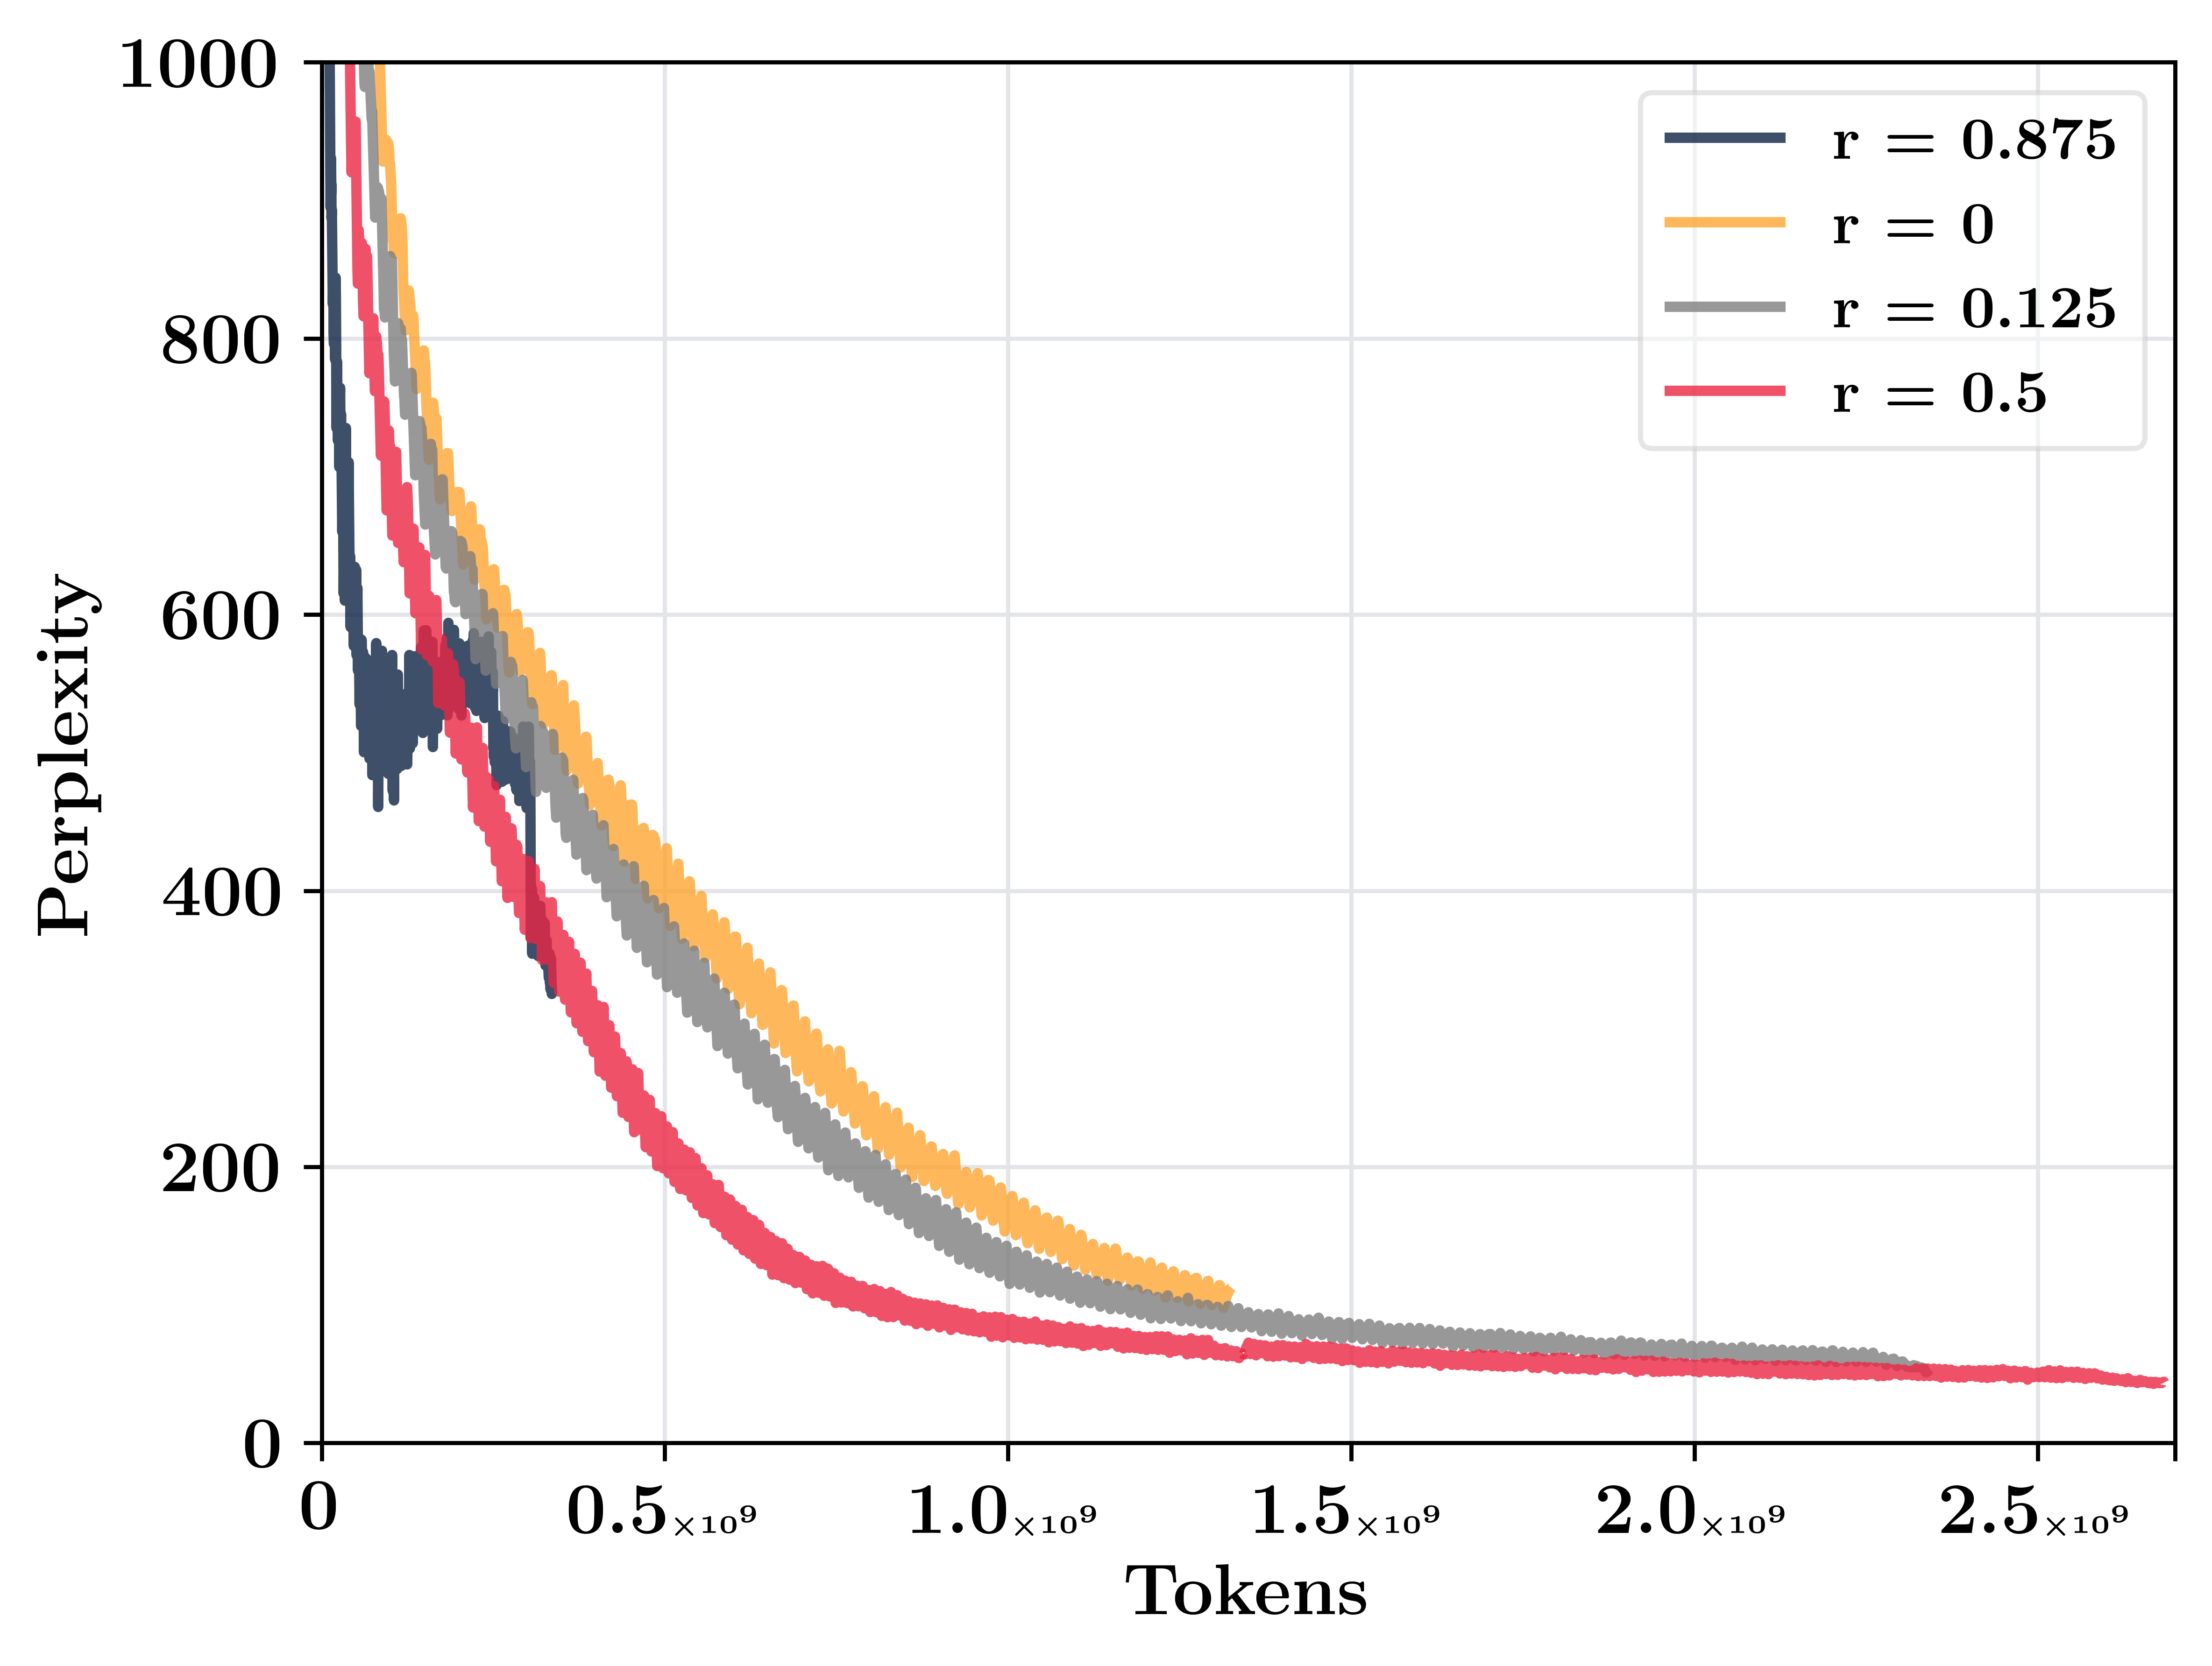

In [45]:
runs_dict_16_clients_16_bs = {
    (n_clients, dropout_ratio, local_batch_size, is_noniid): list_of_run_uuids
    for (
        n_clients,
        dropout_ratio,
        local_batch_size,
        is_noniid,
    ), list_of_run_uuids in runs_dict.items()
    if n_clients == 16 and local_batch_size == 16 and not is_noniid
}
for i, (
    (n_clients, dropout_ratio, local_batch_size, _is_noniid),
    list_of_run_uuids,
) in enumerate(runs_dict_16_clients_16_bs.items()):
    # Download metrics
    list_of_client_metrics_df = []
    client_metrics_df = pd.DataFrame()
    for run_uuid, project_name in list_of_run_uuids:
        try:
            single_server_metrics_df = pd.read_pickle(
                f"server_{run_uuid}_{project_name}.pkl"
            )
            single_client_metrics_df = pd.read_pickle(
                f"clients_{run_uuid}_{project_name}.pkl"
            )
        except FileNotFoundError:
            single_server_metrics_df, single_client_metrics_df = download_metrics(
                run_uuid, n_clients, True, False, project_name
            )
            # Dump the dataframes to pickle files
            single_server_metrics_df.to_pickle(f"server_{run_uuid}_{project_name}.pkl")
            single_client_metrics_df.to_pickle(f"clients_{run_uuid}_{project_name}.pkl")
        # Append the client metrics dataframe to the list
        list_of_client_metrics_df.append(single_client_metrics_df)
    # Concatenate all client metrics dataframes into a single dataframe
    if len(list_of_client_metrics_df) > 0:
        client_metrics_df = pd.concat(list_of_client_metrics_df, ignore_index=True)
    if len(client_metrics_df) > 0:
        log(
            INFO,
            "Plotting (n_clients, dropout_ratio, local_batch_size): %s",
            (n_clients, dropout_ratio, local_batch_size),
        )
        steps_series, ppl_series = get_perplexity_series(
            client_metrics_df, moving_window=10
        )
        # rounds_series = steps_series // 512
        token_scaling_factor = n_clients * local_batch_size * (1 - dropout_ratio) * 2048
        fed_tokens_series = steps_series * token_scaling_factor
        # Plot the y_coordinates against the x_coordinates
        plt.plot(
            fed_tokens_series,
            ppl_series,
            label=r"\textbf{r = }" rf"\textbf{{{dropout_ratio}}}",
            color=color_palette[i % len(color_palette)],
            linestyle=line_styles[0],
            alpha=0.8,
        )
        # plt.xlabel(r"\textbf{Local Steps}")
        plt.xlabel(r"\textbf{Tokens}")
        plt.ylabel(r"\textbf{Perplexity}")
        # Change the minor grid to have a smaller linewidth
        plt.grid(axis="both", which="minor", lw=0.5)
        # Set y-axis limits
        plt.ylim(0, 1000)
        # Set x-axis limits
        plt.xlim(0, 2_700_000_000)
        # Set ticks
        # Set ticks
        plt.xticks(
            [
                0,
                500_000_000,
                1_000_000_000,
                1_500_000_000,
                2_000_000_000,
                2_500_000_000,
                2_700_000_000,
            ],
            labels=[
                rf"\textbf{{{0}}}",
                r"\textbf{0.5}" r"\textbf{\tiny ×10\textsuperscript{9}}",
                r"\textbf{1.0}" r"\textbf{\tiny ×10\textsuperscript{9}}",
                r"\textbf{1.5}" r"\textbf{\tiny ×10\textsuperscript{9}}",
                r"\textbf{2.0}" r"\textbf{\tiny ×10\textsuperscript{9}}",
                r"\textbf{2.5}" r"\textbf{\tiny ×10\textsuperscript{9}}",
                "",
            ],
        )
        plt.yticks(
            [0, 200, 400, 600, 800, 1_000],
            labels=[
                rf"\textbf{{{0}}}",
                rf"\textbf{{{200}}}",
                rf"\textbf{{{400}}}",
                rf"\textbf{{{600}}}",
                rf"\textbf{{{800}}}",
                rf"\textbf{{{1_000}}}",
            ],
        )
plt.legend()
# plt.savefig("hetero_pp_ppl.pdf")
plt.show()

ERROR :     Client 2 not found for run fed-mlsysrbst-0.125-c4-20250328_081611
Traceback (most recent call last):
  File "/var/folders/z6/4xjxh_6547b23c1cn00kfg8c0000gn/T/ipykernel_43387/4037655465.py", line 20, in <module>
    single_server_metrics_df = pd.read_pickle(f"server_{run_uuid}_{project_name}.pkl")
                               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/lorenzosani/Library/Caches/pypoetry/virtualenvs/flower-llm-OvKrXi-2-py3.11/lib/python3.11/site-packages/pandas/io/pickle.py", line 185, in read_pickle
    with get_handle(
         ^^^^^^^^^^^
  File "/Users/lorenzosani/Library/Caches/pypoetry/virtualenvs/flower-llm-OvKrXi-2-py3.11/lib/python3.11/site-packages/pandas/io/common.py", line 882, in get_handle
    handle = open(handle, ioargs.mode)
             ^^^^^^^^^^^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: 'server_fed-mlsysrbst-0.125-c4-20250328_081611_pollen-llm.pkl'

During handling of the above exc

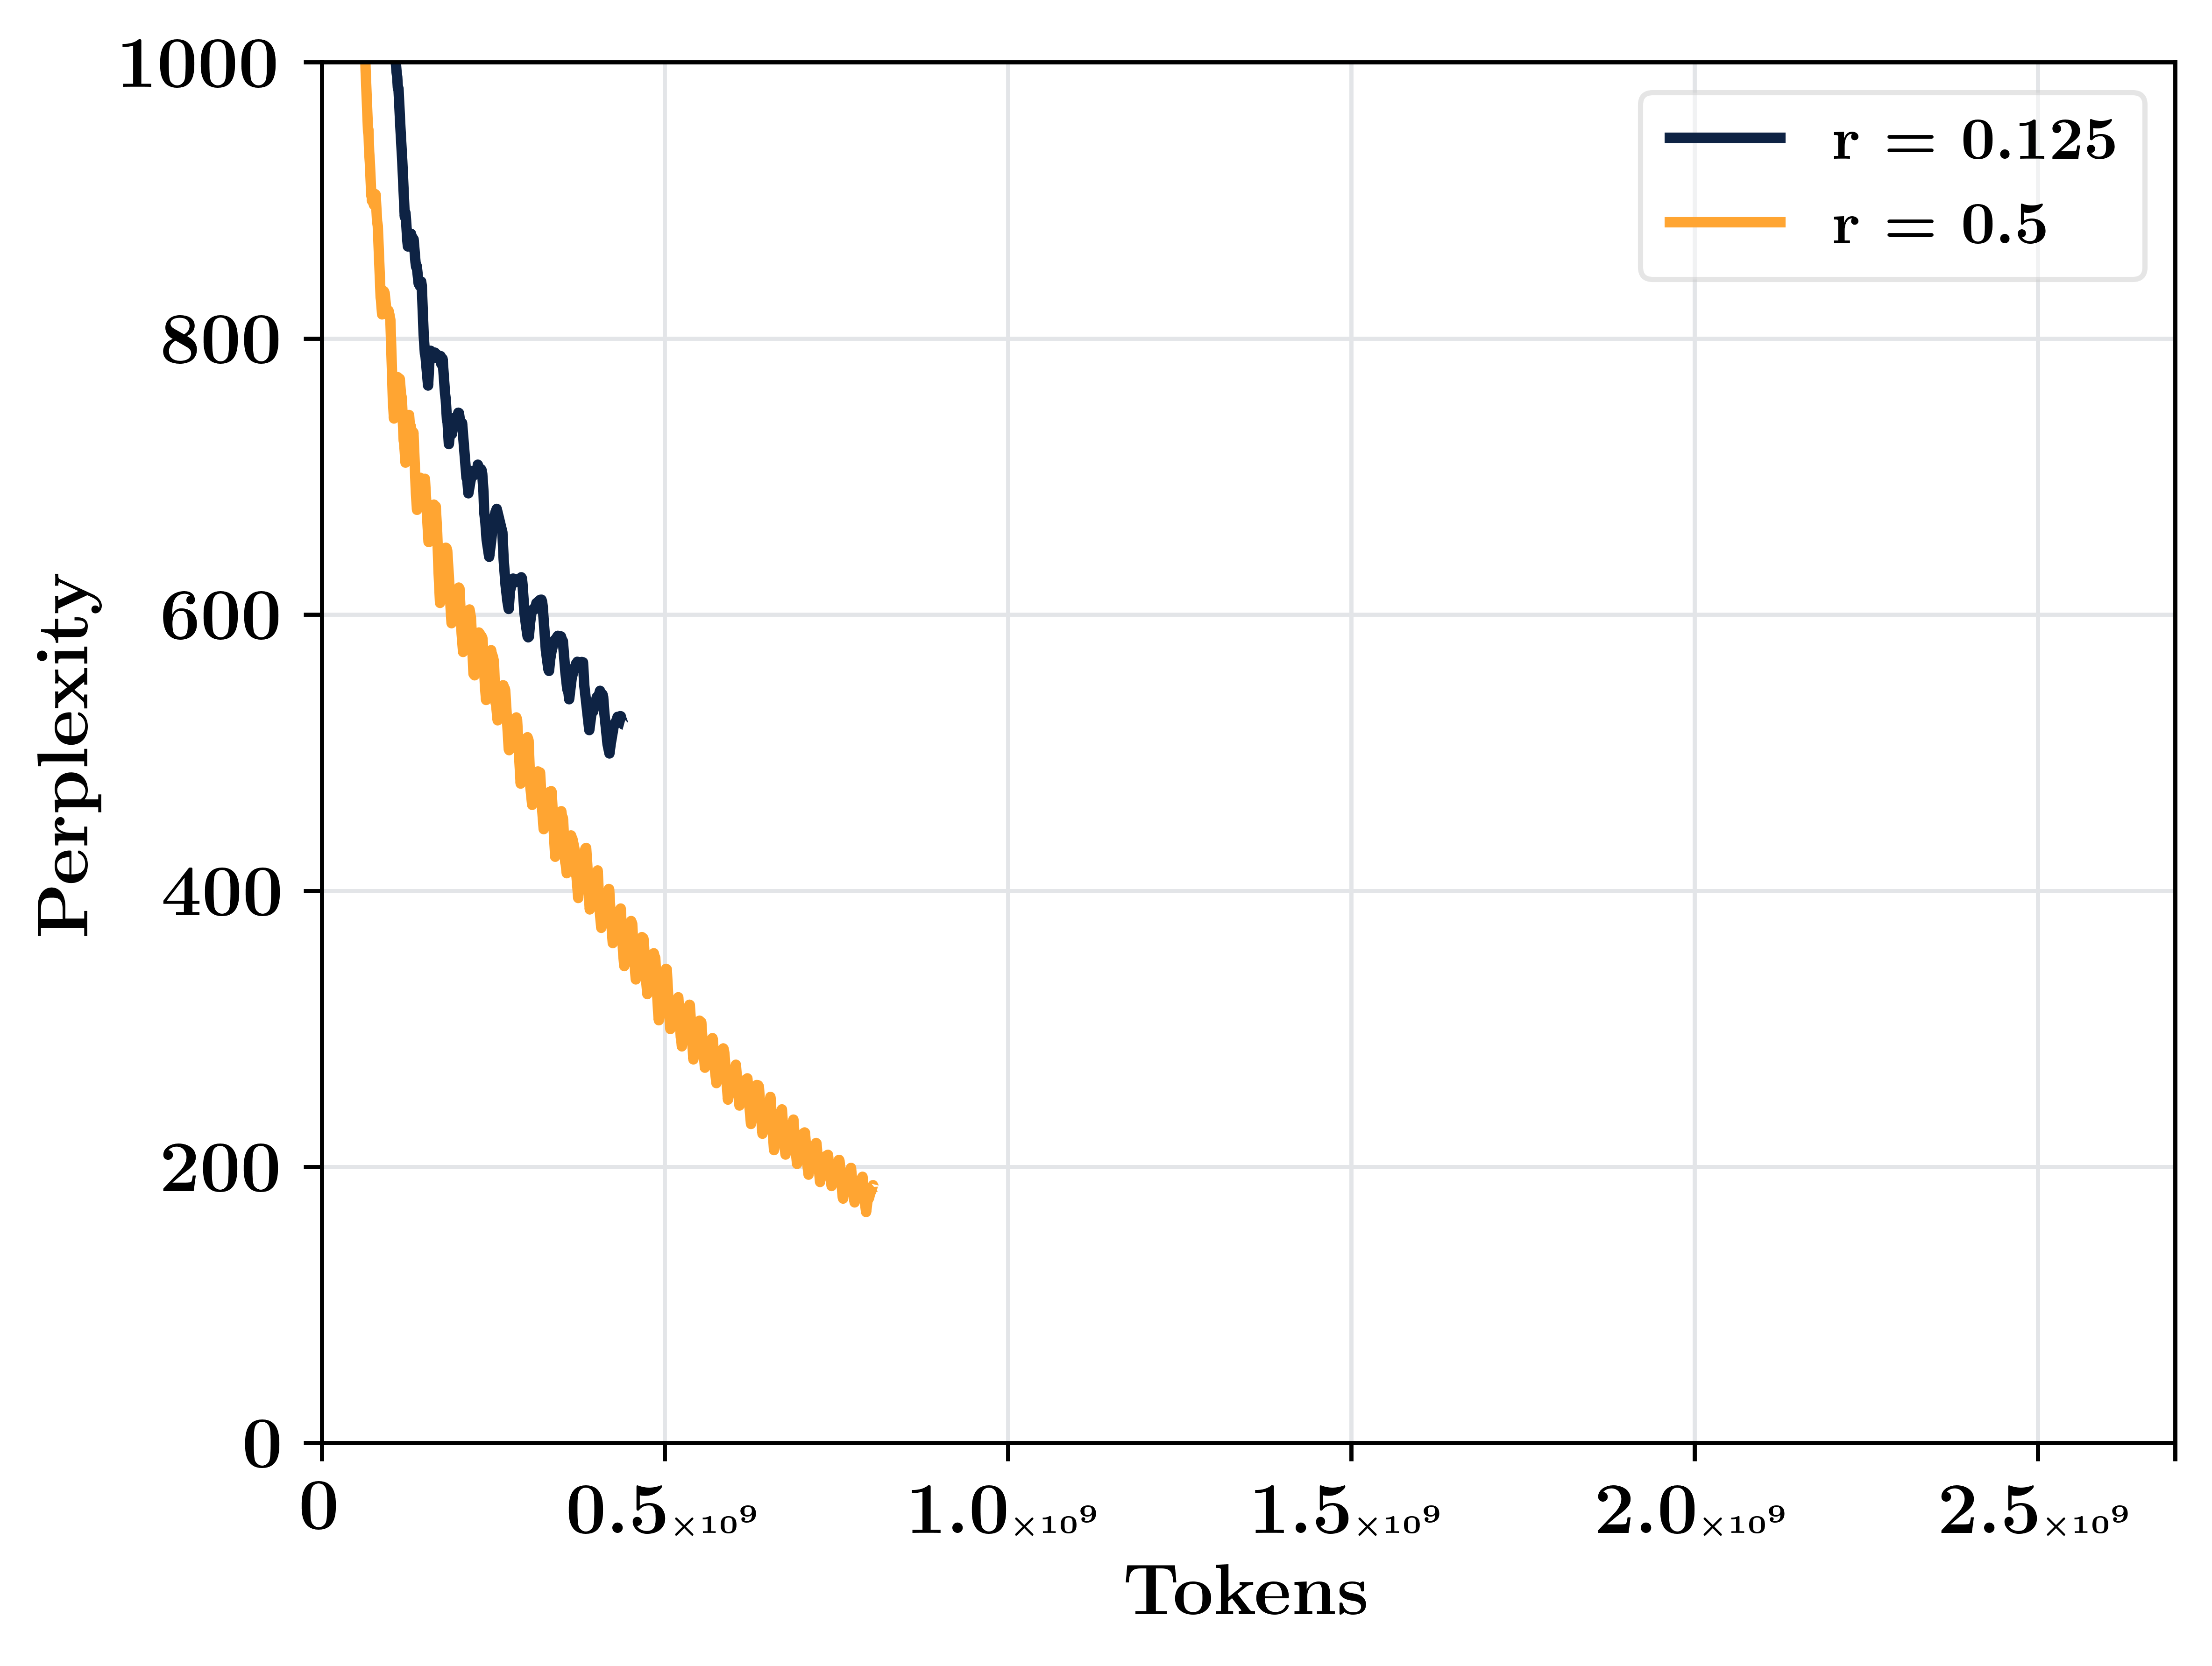

In [46]:
runs_dict_16_clients_32_bs = {
    (n_clients, dropout_ratio, local_batch_size, is_noniid): list_of_run_uuids
    for (
        n_clients,
        dropout_ratio,
        local_batch_size,
        is_noniid,
    ), list_of_run_uuids in runs_dict.items()
    if n_clients == 16 and local_batch_size == 32 and not is_noniid
}
for i, (
    (n_clients, dropout_ratio, local_batch_size, _is_noniid),
    list_of_run_uuids,
) in enumerate(runs_dict_16_clients_32_bs.items()):
    # Download metrics
    list_of_client_metrics_df = []
    client_metrics_df = pd.DataFrame()
    for run_uuid, project_name in list_of_run_uuids:
        try:
            single_server_metrics_df = pd.read_pickle(
                f"server_{run_uuid}_{project_name}.pkl"
            )
            single_client_metrics_df = pd.read_pickle(
                f"clients_{run_uuid}_{project_name}.pkl"
            )
        except FileNotFoundError:
            single_server_metrics_df, single_client_metrics_df = download_metrics(
                run_uuid, n_clients, True, False, project_name
            )
            # Dump the dataframes to pickle files
            single_server_metrics_df.to_pickle(f"server_{run_uuid}_{project_name}.pkl")
            single_client_metrics_df.to_pickle(f"clients_{run_uuid}_{project_name}.pkl")
        # Append the client metrics dataframe to the list
        list_of_client_metrics_df.append(single_client_metrics_df)
    # Concatenate all client metrics dataframes into a single dataframe
    if len(list_of_client_metrics_df) > 0:
        client_metrics_df = pd.concat(list_of_client_metrics_df, ignore_index=True)
    if len(client_metrics_df) > 0:
        log(
            INFO,
            "Plotting (n_clients, dropout_ratio, local_batch_size): %s",
            (n_clients, dropout_ratio, local_batch_size),
        )
        steps_series, ppl_series = get_perplexity_series(
            client_metrics_df, moving_window=10
        )
        # rounds_series = steps_series // 512
        token_scaling_factor = n_clients * local_batch_size * (1 - dropout_ratio) * 2048
        fed_tokens_series = steps_series * token_scaling_factor
        # Plot the y_coordinates against the x_coordinates
        plt.plot(
            fed_tokens_series,
            ppl_series,
            label=r"\textbf{r = }" rf"\textbf{{{dropout_ratio}}}",
            color=color_palette[i % len(color_palette)],
            linestyle=line_styles[0],
        )
        # plt.xlabel(r"\textbf{Local Steps}")
        plt.xlabel(r"\textbf{Tokens}")
        plt.ylabel(r"\textbf{Perplexity}")
        # Change the minor grid to have a smaller linewidth
        plt.grid(axis="both", which="minor", lw=0.5)
        # Set y-axis limits
        plt.ylim(0, 1000)
        # Set x-axis limits
        plt.xlim(0, 2_700_000_000)
        # Set ticks
        plt.xticks(
            [
                0,
                500_000_000,
                1_000_000_000,
                1_500_000_000,
                2_000_000_000,
                2_500_000_000,
                2_700_000_000,
            ],
            labels=[
                rf"\textbf{{{0}}}",
                r"\textbf{0.5}" r"\textbf{\tiny ×10\textsuperscript{9}}",
                r"\textbf{1.0}" r"\textbf{\tiny ×10\textsuperscript{9}}",
                r"\textbf{1.5}" r"\textbf{\tiny ×10\textsuperscript{9}}",
                r"\textbf{2.0}" r"\textbf{\tiny ×10\textsuperscript{9}}",
                r"\textbf{2.5}" r"\textbf{\tiny ×10\textsuperscript{9}}",
                "",
            ],
        )
        plt.yticks(
            [0, 200, 400, 600, 800, 1_000],
            labels=[
                rf"\textbf{{{0}}}",
                rf"\textbf{{{200}}}",
                rf"\textbf{{{400}}}",
                rf"\textbf{{{600}}}",
                rf"\textbf{{{800}}}",
                rf"\textbf{{{1_000}}}",
            ],
        )
plt.legend()
# plt.savefig("hetero_pp_ppl.pdf")
plt.show()

ERROR :     Client 0 not found for run fed-mlsysrbst-0.125-c4-20250329_175811
Traceback (most recent call last):
  File "/var/folders/z6/4xjxh_6547b23c1cn00kfg8c0000gn/T/ipykernel_43387/2630858700.py", line 20, in <module>
    single_server_metrics_df = pd.read_pickle(f"server_{run_uuid}_{project_name}.pkl")
                               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/lorenzosani/Library/Caches/pypoetry/virtualenvs/flower-llm-OvKrXi-2-py3.11/lib/python3.11/site-packages/pandas/io/pickle.py", line 185, in read_pickle
    with get_handle(
         ^^^^^^^^^^^
  File "/Users/lorenzosani/Library/Caches/pypoetry/virtualenvs/flower-llm-OvKrXi-2-py3.11/lib/python3.11/site-packages/pandas/io/common.py", line 882, in get_handle
    handle = open(handle, ioargs.mode)
             ^^^^^^^^^^^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: 'server_fed-mlsysrbst-0.125-c4-20250329_175811_photon.pkl'

During handling of the above excepti

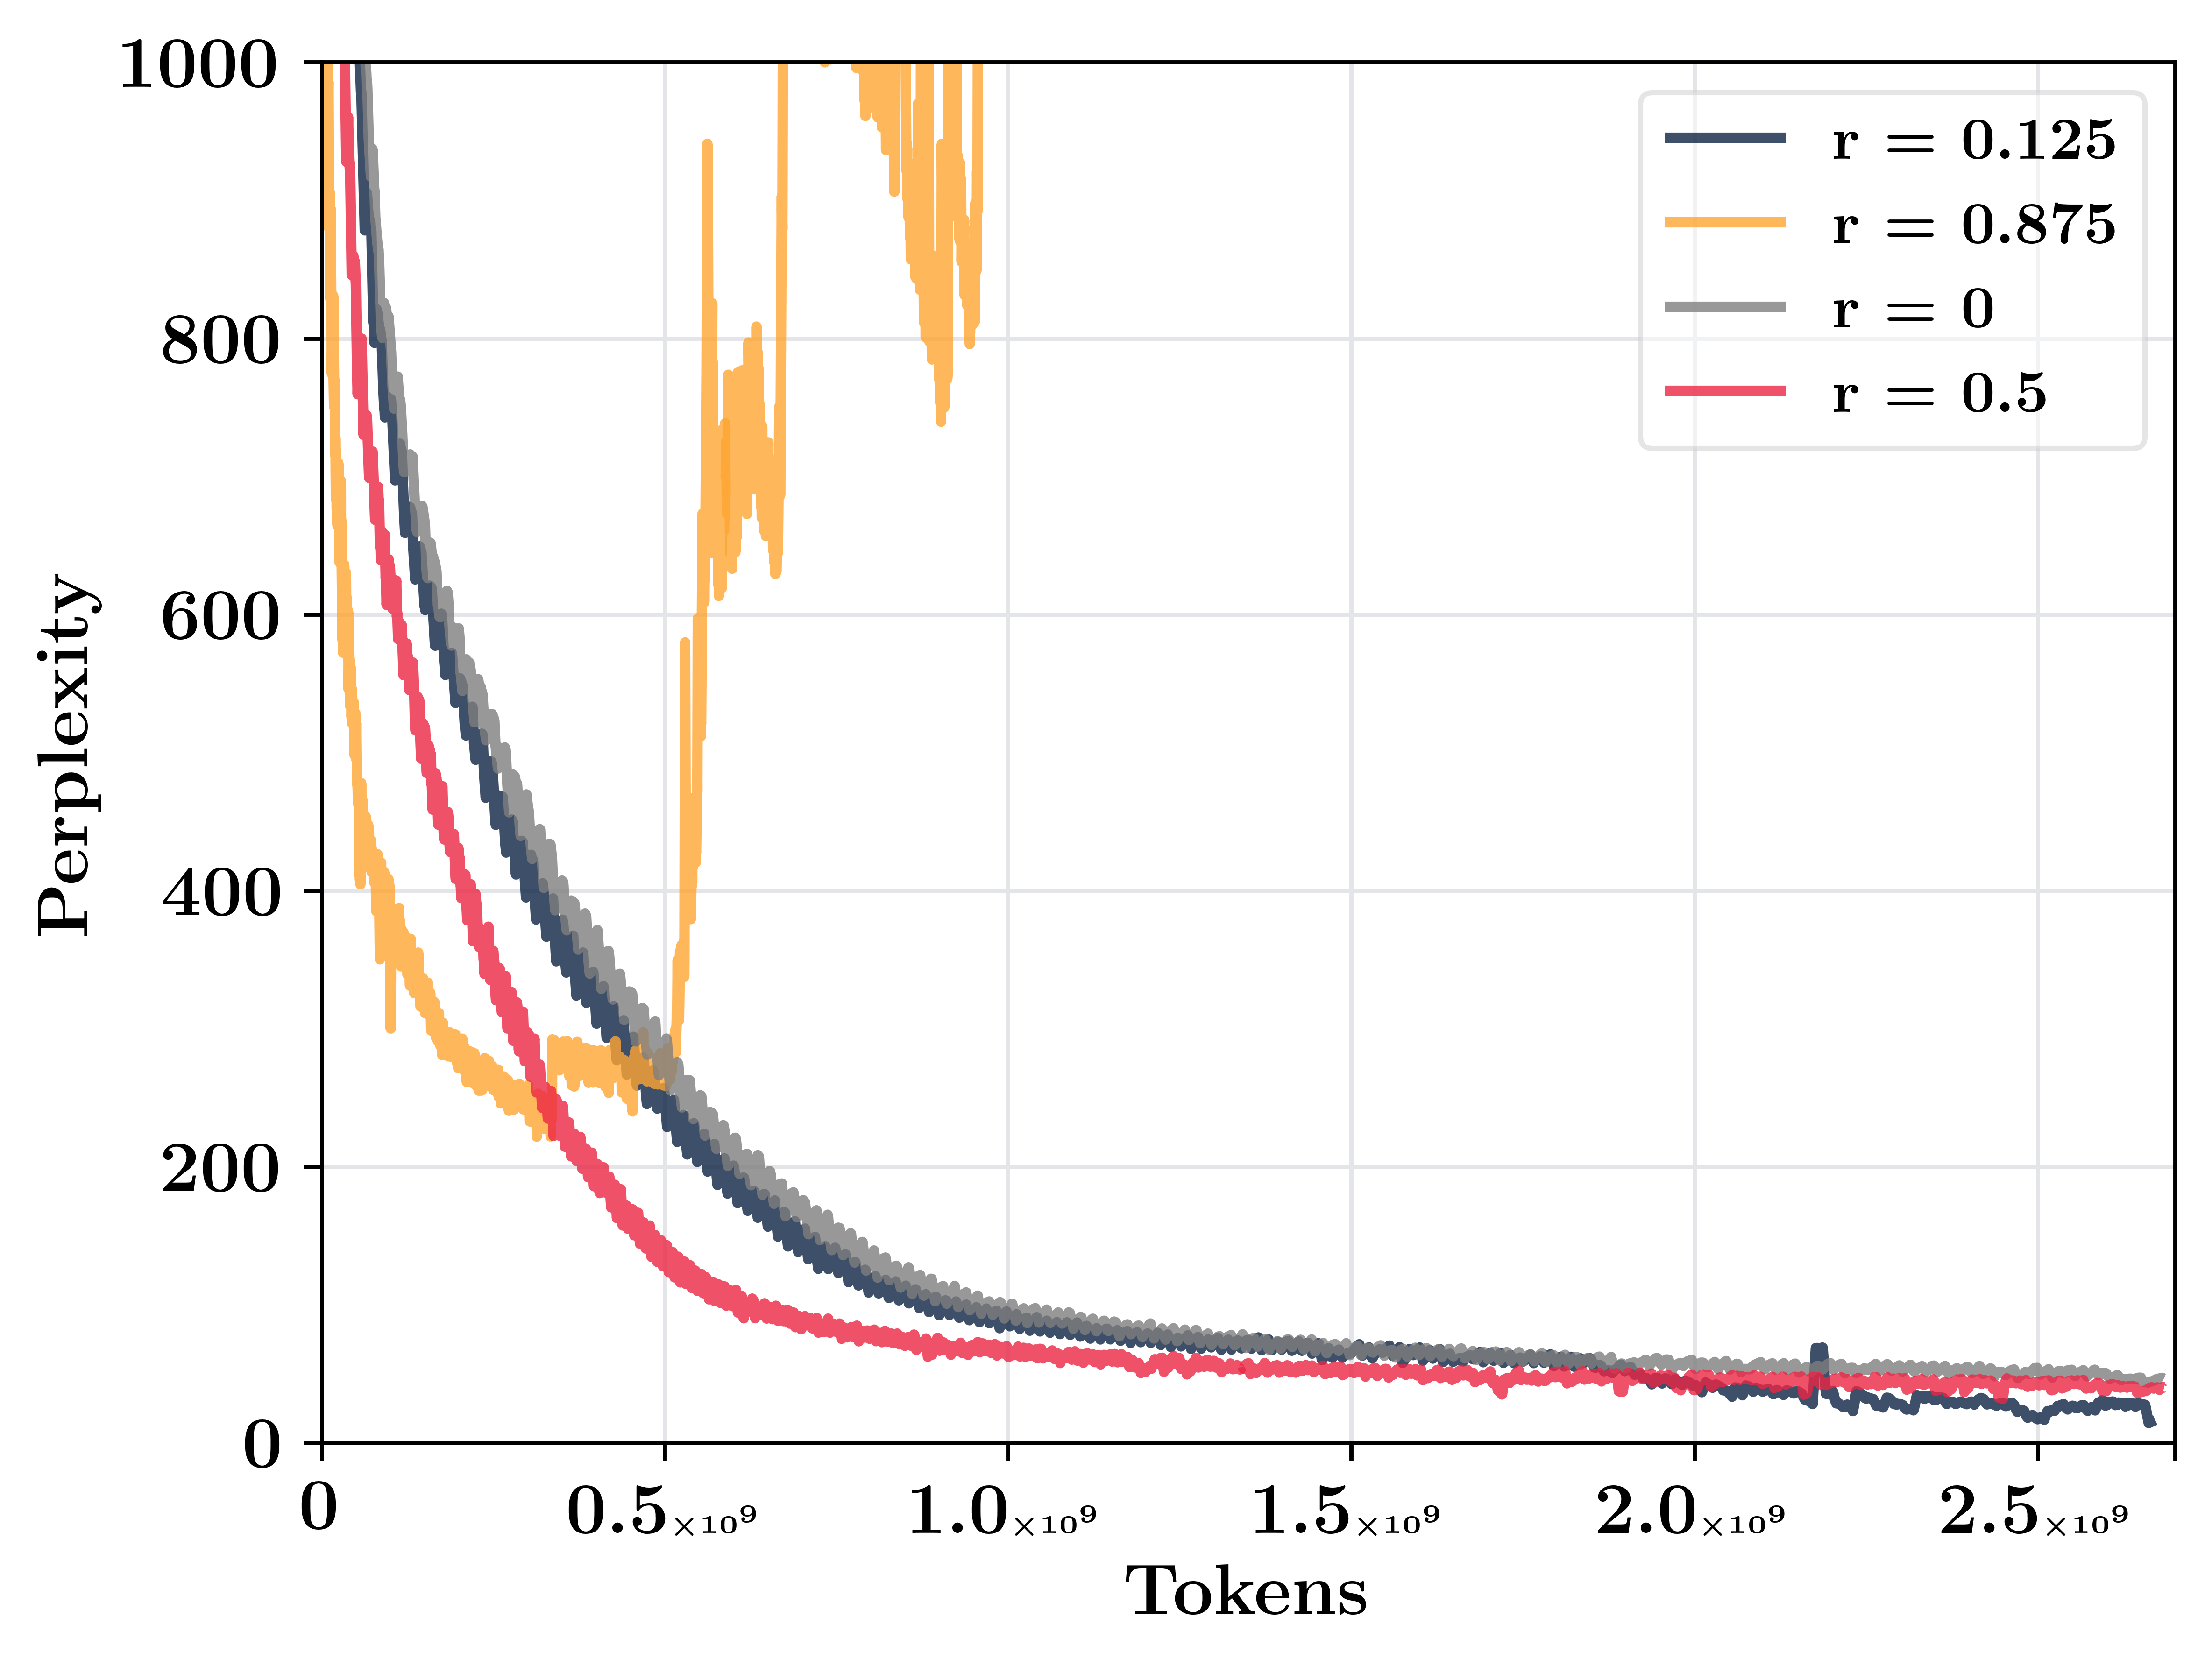

In [47]:
runs_dict_8 = {
    (n_clients, dropout_ratio, local_batch_size, is_noniid): list_of_run_uuids
    for (
        n_clients,
        dropout_ratio,
        local_batch_size,
        is_noniid,
    ), list_of_run_uuids in runs_dict.items()
    if n_clients == 8 and not is_noniid
}
for i, (
    (n_clients, dropout_ratio, local_batch_size, _is_noniid),
    list_of_run_uuids,
) in enumerate(runs_dict_8.items()):
    # Download metrics
    list_of_client_metrics_df = []
    client_metrics_df = pd.DataFrame()
    for run_uuid, project_name in list_of_run_uuids:
        try:
            single_server_metrics_df = pd.read_pickle(
                f"server_{run_uuid}_{project_name}.pkl"
            )
            single_client_metrics_df = pd.read_pickle(
                f"clients_{run_uuid}_{project_name}.pkl"
            )
        except FileNotFoundError:
            single_server_metrics_df, single_client_metrics_df = download_metrics(
                run_uuid, n_clients, True, False, project_name
            )
            # Dump the dataframes to pickle files
            single_server_metrics_df.to_pickle(f"server_{run_uuid}_{project_name}.pkl")
            single_client_metrics_df.to_pickle(f"clients_{run_uuid}_{project_name}.pkl")
        # Append the client metrics dataframe to the list
        list_of_client_metrics_df.append(single_client_metrics_df)
    # Concatenate all client metrics dataframes into a single dataframe
    if len(list_of_client_metrics_df) > 0:
        client_metrics_df = pd.concat(list_of_client_metrics_df, ignore_index=True)
    if len(client_metrics_df) > 0:
        log(
            INFO,
            "Plotting (n_clients, dropout_ratio, local_batch_size): %s",
            (n_clients, dropout_ratio, local_batch_size),
        )
        steps_series, ppl_series = get_perplexity_series(
            client_metrics_df,
            moving_window=10,
        )
        # rounds_series = steps_series // 512
        token_scaling_factor = n_clients * local_batch_size * (1 - dropout_ratio) * 2048
        fed_tokens_series = steps_series * token_scaling_factor
        federated_rounds = steps_series // 32
        # Plot the y_coordinates against the x_coordinates
        plt.plot(
            fed_tokens_series,
            # federated_rounds,
            ppl_series,
            label=r"\textbf{r = }" rf"\textbf{{{dropout_ratio}}}",
            color=color_palette[i % len(color_palette)],
            linestyle=line_styles[0],
            alpha=0.8,
        )
        # plt.xlabel(r"\textbf{Federated Rounds}")
        plt.xlabel(r"\textbf{Tokens}")
        plt.ylabel(r"\textbf{Perplexity}")
        # Change the minor grid to have a smaller linewidth
        plt.grid(axis="both", which="minor", lw=0.5)
        # Set y-axis limits
        plt.ylim(0, 1000)
        # Set x-axis limits
        plt.xlim(0, 2_700_000_000)
        # Set ticks
        plt.xticks(
            [
                0,
                500_000_000,
                1_000_000_000,
                1_500_000_000,
                2_000_000_000,
                2_500_000_000,
                2_700_000_000,
            ],
            labels=[
                rf"\textbf{{{0}}}",
                r"\textbf{0.5}" r"\textbf{\tiny ×10\textsuperscript{9}}",
                r"\textbf{1.0}" r"\textbf{\tiny ×10\textsuperscript{9}}",
                r"\textbf{1.5}" r"\textbf{\tiny ×10\textsuperscript{9}}",
                r"\textbf{2.0}" r"\textbf{\tiny ×10\textsuperscript{9}}",
                r"\textbf{2.5}" r"\textbf{\tiny ×10\textsuperscript{9}}",
                "",
            ],
        )
        plt.yticks(
            [0, 200, 400, 600, 800, 1_000],
            labels=[
                rf"\textbf{{{0}}}",
                rf"\textbf{{{200}}}",
                rf"\textbf{{{400}}}",
                rf"\textbf{{{600}}}",
                rf"\textbf{{{800}}}",
                rf"\textbf{{{1_000}}}",
            ],
        )
plt.legend()
# plt.savefig("hetero_pp_ppl.pdf")
plt.show()

INFO :      Plotting (n_clients, dropout_ratio, local_batch_size): (8, 0.5, 32)
INFO :      Plotting (n_clients, dropout_ratio, local_batch_size): (8, 0.125, 32)
INFO :      Plotting (n_clients, dropout_ratio, local_batch_size): (8, 0.875, 32)
INFO :      Plotting (n_clients, dropout_ratio, local_batch_size): (8, 0, 32)


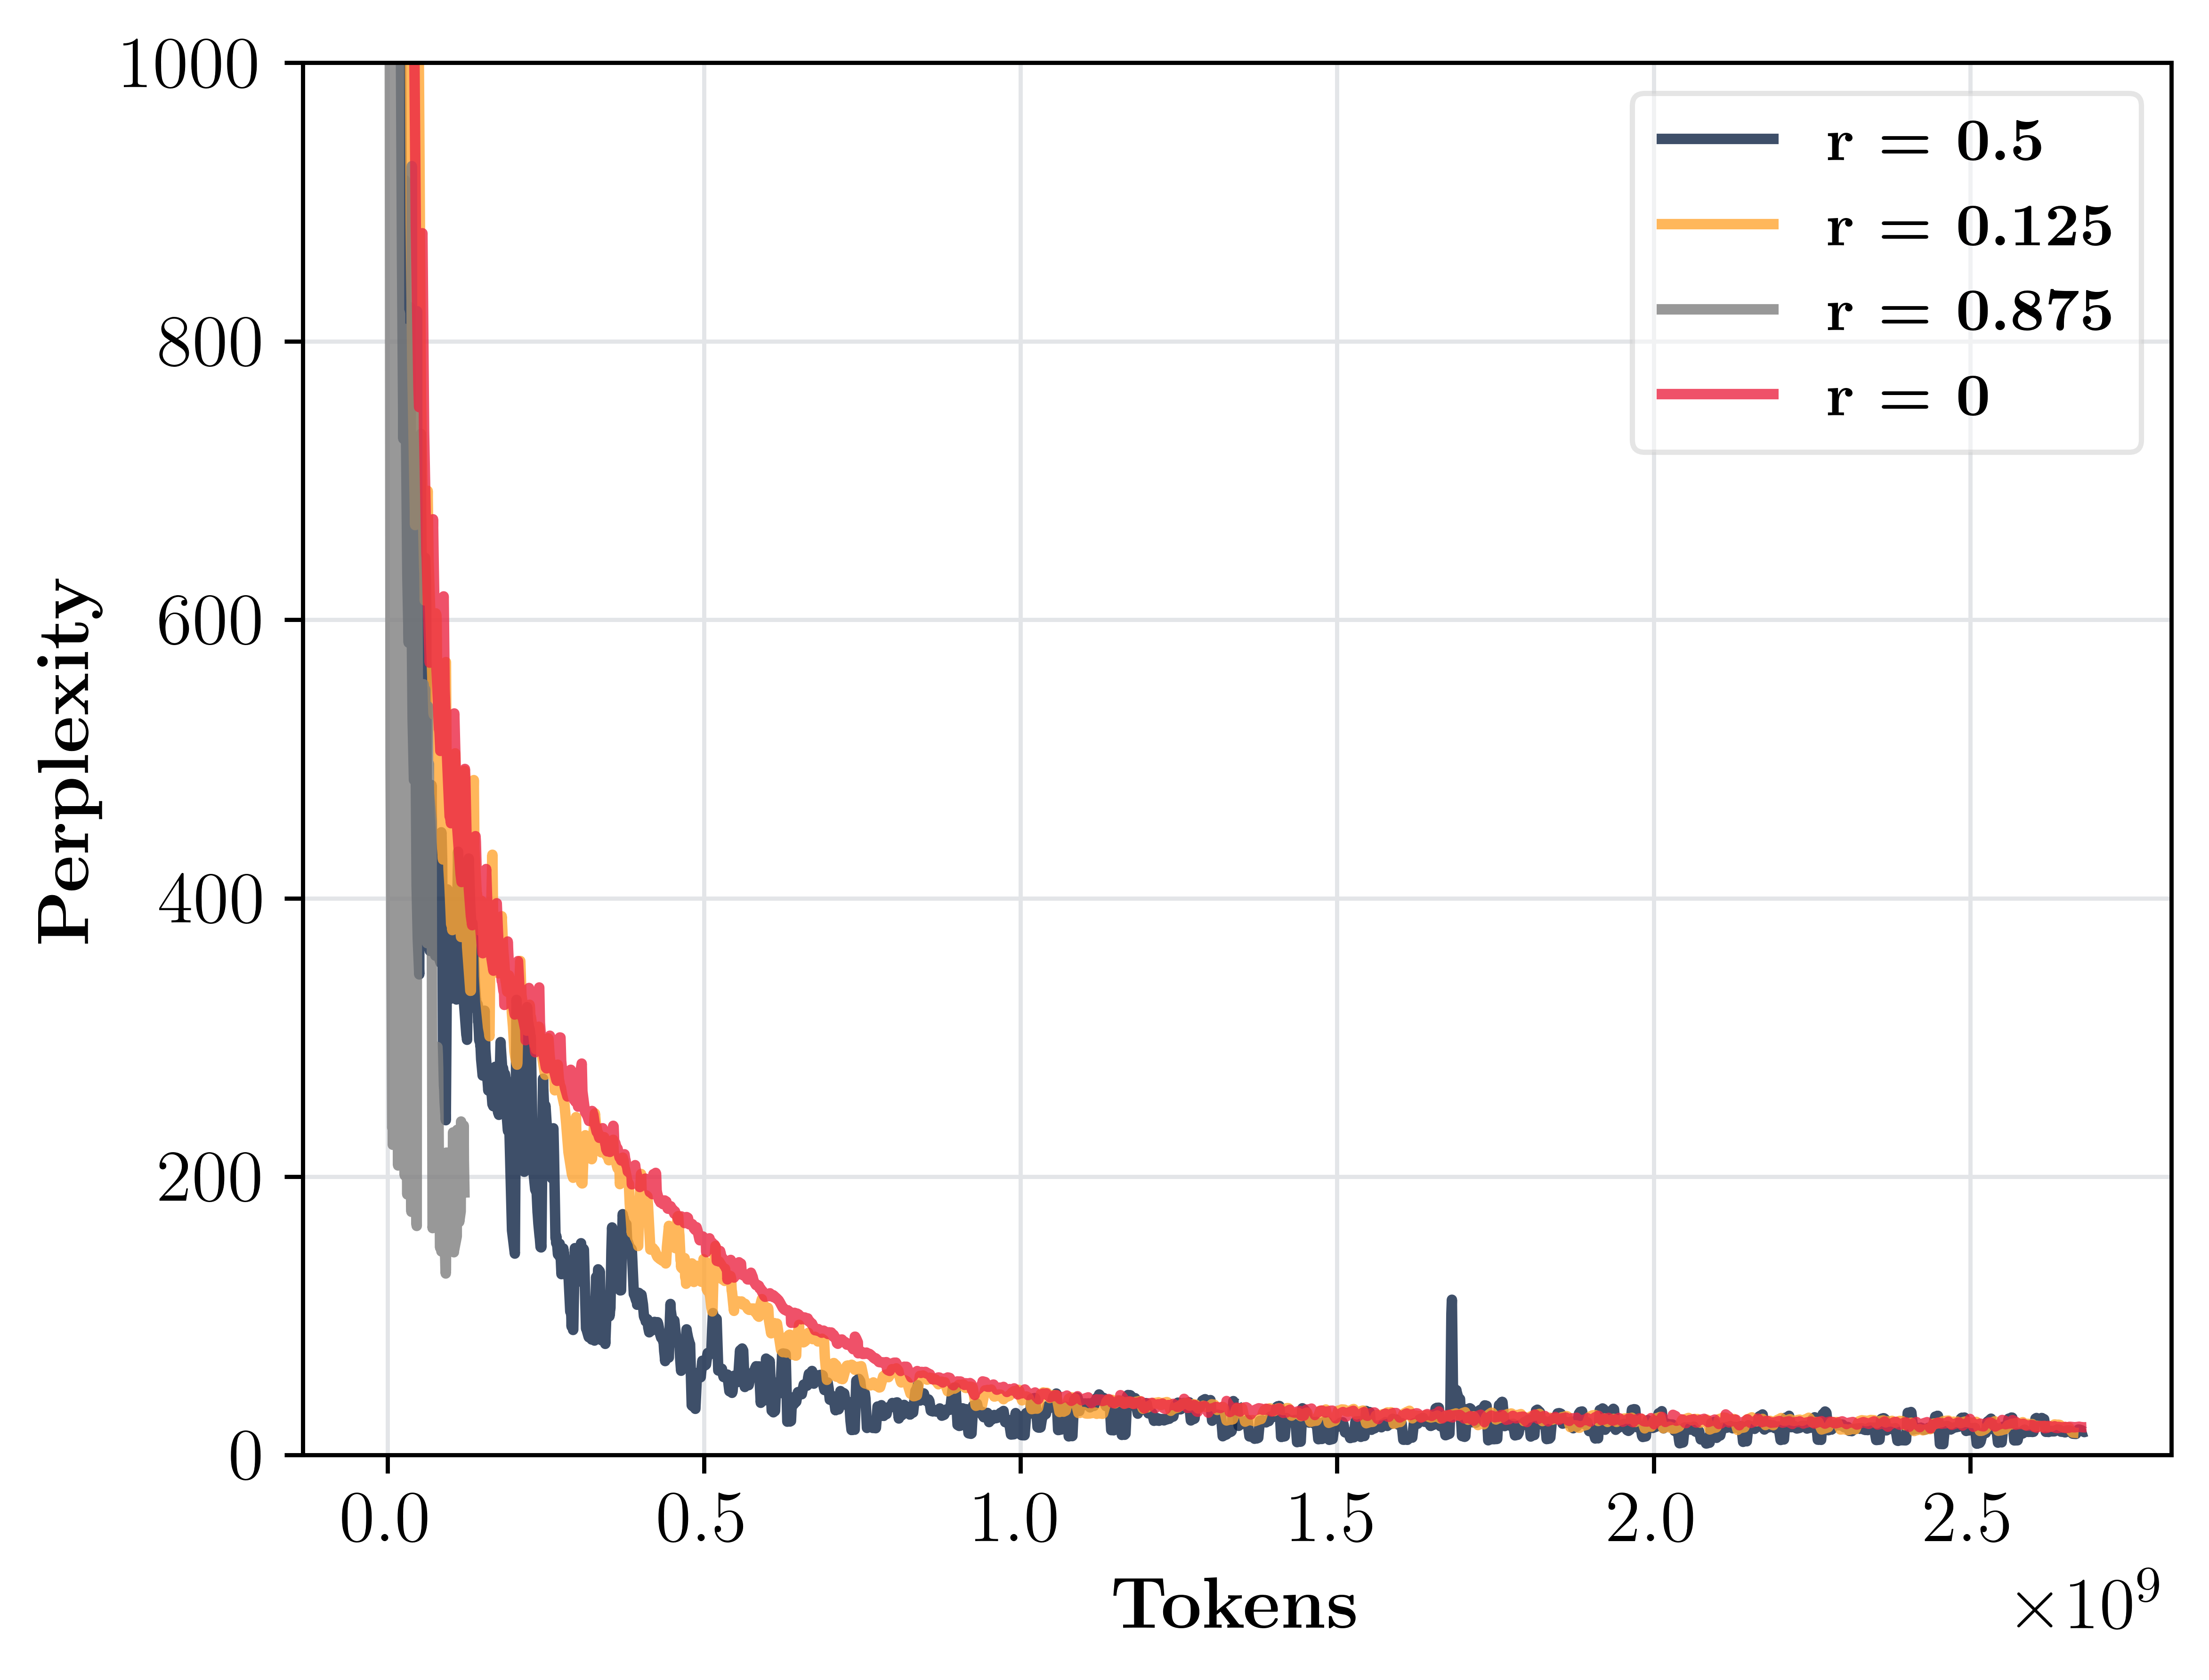

In [53]:
runs_dict_8 = {
    (n_clients, dropout_ratio, local_batch_size, is_noniid): list_of_run_uuids
    for (
        n_clients,
        dropout_ratio,
        local_batch_size,
        is_noniid,
    ), list_of_run_uuids in runs_dict.items()
    if n_clients == 8 and is_noniid
}
for i, (
    (n_clients, dropout_ratio, local_batch_size, _is_noniid),
    list_of_run_uuids,
) in enumerate(runs_dict_8.items()):
    # Download metrics
    list_of_client_metrics_df = []
    client_metrics_df = pd.DataFrame()
    for run_uuid, project_name in list_of_run_uuids:
        try:
            single_server_metrics_df = pd.read_pickle(
                f"server_{run_uuid}_{project_name}.pkl"
            )
            single_client_metrics_df = pd.read_pickle(
                f"clients_{run_uuid}_{project_name}.pkl"
            )
        except FileNotFoundError:
            single_server_metrics_df, single_client_metrics_df = download_metrics(
                run_uuid, n_clients, True, False, project_name
            )
            # Dump the dataframes to pickle files
            single_server_metrics_df.to_pickle(f"server_{run_uuid}_{project_name}.pkl")
            single_client_metrics_df.to_pickle(f"clients_{run_uuid}_{project_name}.pkl")
        # Append the client metrics dataframe to the list
        list_of_client_metrics_df.append(single_client_metrics_df)
    # Concatenate all client metrics dataframes into a single dataframe
    if len(list_of_client_metrics_df) > 0:
        client_metrics_df = pd.concat(list_of_client_metrics_df, ignore_index=True)
    if len(client_metrics_df) > 0:
        log(
            INFO,
            "Plotting (n_clients, dropout_ratio, local_batch_size): %s",
            (n_clients, dropout_ratio, local_batch_size),
        )
        steps_series, ppl_series = get_perplexity_series(
            client_metrics_df,
            moving_window=10,
        )
        # rounds_series = steps_series // 512
        token_scaling_factor = n_clients * local_batch_size * (1 - dropout_ratio) * 2048
        fed_tokens_series = steps_series * token_scaling_factor
        federated_rounds = steps_series // 32
        # Plot the y_coordinates against the x_coordinates
        plt.plot(
            fed_tokens_series,
            # federated_rounds,
            ppl_series,
            label=r"\textbf{r = }" rf"\textbf{{{dropout_ratio}}}",
            color=color_palette[i % len(color_palette)],
            linestyle=line_styles[0],
            alpha=0.8,
        )
        # plt.xlabel(r"\textbf{Federated Rounds}")
        plt.xlabel(r"\textbf{Tokens}")
        plt.ylabel(r"\textbf{Perplexity}")
        # Change the minor grid to have a smaller linewidth
        plt.grid(axis="both", which="minor", lw=0.5)
        # Set y-axis limits
        plt.ylim(0, 1000)
        # # Set x-axis limits
        # plt.xlim(0, 2_700_000_000)
        # # Set ticks
        # plt.xticks(
        #     [
        #         0,
        #         500_000_000,
        #         1_000_000_000,
        #         1_500_000_000,
        #         2_000_000_000,
        #         2_500_000_000,
        #         2_700_000_000,
        #     ],
        #     labels=[
        #         rf"\textbf{{{0}}}",
        #         r"\textbf{0.5}" r"\textbf{\tiny ×10\textsuperscript{9}}",
        #         r"\textbf{1.0}" r"\textbf{\tiny ×10\textsuperscript{9}}",
        #         r"\textbf{1.5}" r"\textbf{\tiny ×10\textsuperscript{9}}",
        #         r"\textbf{2.0}" r"\textbf{\tiny ×10\textsuperscript{9}}",
        #         r"\textbf{2.5}" r"\textbf{\tiny ×10\textsuperscript{9}}",
        #         "",
        #     ],
        # )
        # plt.yticks(
        #     [0, 200, 400, 600, 800, 1_000],
        #     labels=[
        #         rf"\textbf{{{0}}}",
        #         rf"\textbf{{{200}}}",
        #         rf"\textbf{{{400}}}",
        #         rf"\textbf{{{600}}}",
        #         rf"\textbf{{{800}}}",
        #         rf"\textbf{{{1_000}}}",
        #     ],
        # )
plt.legend()
# plt.savefig("hetero_pp_ppl.pdf")
plt.show()